In [30]:
import pickle
import os
import copy
import matplotlib.pyplot as plt
import numpy as np
import paper_style  # apply the style automatically
import gc
import psutil
import yaml
import sys
import torch
import io
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




# Input Config

In [ ]:
# disk_analysis = '/home/evrond/analysis_data/final_analysis/disk'
disk_analysis_8a_colfree_finished = '/home/evrond/mr_mpc_logs/BATCH_2025-09-11_01:40:09_jobTMP_DISK_INTERACTIVE_8_1k'
disk_16c ='/home/evrond/mr_mpc_logs/BATCH_2025-09-11_16:50:05_job6572995' # collision free


####################
disk_12a = '/home/evrond/mr_mpc_logs/BATCH_2025-09-11_01:07:51_job6568857' # 1 collision
disk_16a_colfree_unfinished = '/home/evrond/mr_mpc_logs/BATCH_2025-09-11_01:30:53_job6568858' # collision free but not done
disk_16b_colfree_unfinished = '/home/evrond/mr_mpc_logs/BATCH_2025-09-11_12:00:34_job6570400' # 
disk_analysis_32a_stuck = '/home/evrond/mr_mpc_logs/BATCH_2025-09-11_01:44:54_job6568876' # stuck, max vel (robot cfg file) was too small. Must be at least 0.5
disk_32b = '/home/evrond/mr_mpc_logs/BATCH_2025-09-11_12:02:24_job6570401' # 1 col
disk_32c = '/home/evrond/mr_mpc_logs/BATCH_2025-09-11_12:07:25_job6570406' # some cols
disk_32d = '/home/evrond/mr_mpc_logs/BATCH_2025-09-11_12:09:36_job6570409' # some cols
disk_32e = '/home/evrond/mr_mpc_logs/BATCH_2025-09-11_12:11:24_job6570439' # 1 col only
disk_32f = '/home/evrond/mr_mpc_logs/BATCH_2025-09-11_12:12:25_job6570442' # some cols
disk_32g = '/home/evrond/mr_mpc_logs/BATCH_2025-09-11_12:24:25_job6570703' # some cols
disk_32h = '/home/evrond/mr_mpc_logs/BATCH_2025-09-11_15:33:36_job6571930'
disk_16d ='/home/evrond/mr_mpc_logs/BATCH_2025-09-11_16:59:52_job6573018'
disk_16e = '/home/evrond/mr_mpc_logs/BATCH_2025-09-11_20:45:51_job6575843'

########################################
################ INPUT #################
########################################
disk_analysis = disk_16c

########################################
########################################
########################################




# root_path = all_analysis # '/home/evrond/mr_mpc_logs/BATCH_2025-09-08_17:33:55_job6527715'
# root_path = task_and_cols_only_root   # '/home/evrond/analysis_data/final_analysis/task_and_collision_anslysis'
# root_path = '/home/evrond/mr_mpc_logs/BATCH_2025-09-08_16:39:28_job6525238/2025-09-08_16:39:28_R_ur5e_N4_AO_Tfollow_s3_l1'
time_analysis = False #True
task_analysis = True
# disk_analysis = True
# # Inputs:

# root_paths_time_analysis = [] #[tmp_O_w5000_cov05_trust3, verified_01_09] # batch_01_09_follow_reach_new_bugfix_in_logging_cols # change this to the root path of the simulations you want to check
# root_paths_task_analysis = []
# if task_analysis:
#     root_paths_task_analysis.append(task_and_cols_root, both_analysis_root)
# if time_analysis:
#     root_paths_time_analysis.append(time_analysis_root,both_analysis_root)
# root_paths_time_analysis = both_analysis_root
root_paths_task_analysis = [disk_analysis]
root_paths_time_analysis = [disk_analysis]
verbose = True
n_max = 1000 # max number of simulations to load (to prevent ram errors load at most 1000)
BATCH_SIZE = 50 # Batch size  for sim files loading. Adjust this based on your RAM - smaller = less memory usage 
exclude_substrings = [
    "SC/N800_H40_cov005"
 # 'O-/N400_H40_cov005_w100000_DEPRECATED_BEFORE_NEW_IMPLEMENTATION'
 ] # 'Tfollow','Tbin'] # Exclude old version reach and follow simulations
# load_only = {
#     'task_type': ['bin','reach','follow'], # ['reach', 'follow', 'bin']
#     'alg': ['O','O-','SC','SD','CC'] # ['SC'] # ['SC'], # ['O','O-','SC','SD','CC']
#     }
load_only = {}
tuning_load_only = {} # empty means load all










# Utils

In [32]:
# Helper and classes to manage sims
def get_memory_usage():
    """Get current memory usage in MB"""
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024
    
def save_plot_to_pdf(file_path):
    plt.savefig(f'{file_path}.pdf')

def find_task_statman_name(stats):
    for statman_name in stats.keys():
        if 'agent' not in statman_name:
            return statman_name
    return None

def find_agent_statman_names(stats):
    agent_statman_names = []
    for statman_name in stats.keys():
        if 'agent' in statman_name:
            agent_statman_names.append(statman_name)
    return agent_statman_names

def get_stat_from_statman(statman, stat_name, keys='all'):
    stat = statman[stat_name]
    if keys == 'all':
        return stat
    
    stat_filtered = []
    for stat_keys,stat_vals in stat.items():
        filtered_entry_keys = {}
        for key in keys:
            if key in stat_keys:
                filtered_entry_keys[key] = stat_vals[key]
                filtered_entry_vals = stat_vals
                stat_filtered.append((filtered_entry_keys,filtered_entry_vals))
    return stat_filtered
    
    
def split_task_to_k_v(stat):
    k = []
    v = []
    for item in stat:
        k.append(item[0])
        v.append(item[1])
    return k, v

def parse_task_by_dirname(root_path, simulation_dir):
    if 'name_format_1' in root_path:
        task_string = simulation_dir.split('_')[-1]
        task_type = task_string[:-1]
        task_seed = 0
        task_level = task_string[-1]
    
    # elif 'name_format_2' in root_path:
    else:
        task_string = simulation_dir.split('T')[-1]
        task_string_splitted = task_string.split('_')
        task_type = task_string_splitted[0]
        assert len(task_string_splitted) == 3, f'task string {task_string} is not in the correct format'
        assert task_string_splitted[1][0] == 's' and task_string_splitted[2][0] == 'l', f'task string {task_string} is not in the correct format'
        task_seed = int(task_string_splitted[1][1:])
        task_level = int(task_string_splitted[2][1:])
    # else:
    #     raise ValueError(f'root path {root_path} not supported')
    assert task_type in ['bin', 'reach','manual','follow','CBSMP1'], f'task type {task_type} not supported'
    return task_type, task_seed, task_level

    

def parse_sim_info_by_dirname(root_path, simulation_dir):
    

    splitted_string = simulation_dir.split('_')
    timestamp = splitted_string[0] + '_' + splitted_string[1]
    robot_name = splitted_string[3]
    n_arms = int(splitted_string[4][1:])
    alg = splitted_string[5][1:]
    task_parsed = parse_task_by_dirname(root_path, simulation_dir)
    task_type, task_seed, task_level = task_parsed


    
    return {'timestamp':timestamp, 
    'robot_name':robot_name, 
    'n_arms':n_arms, 
    'alg':alg, 
    'task_type':task_type, 
    'task_seed':task_seed, 
    'task_level':task_level
    }


class SimStats:
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        self.task_stats_parsed = []
        self.meta_data = meta_data
        self.sim_stats = sim_stats
        self.task_stats = sim_stats['task_stats']
        agents_statman_names = [x for x in sim_stats.keys() if 'agent' in x]
        agents_statman_names.sort(key=lambda x: int(x.split('_')[-1])) # sort by agent index
        self.agent_stats = []
        for statman_name in agents_statman_names:
            self.agent_stats.append(sim_stats[statman_name])
        
        
        self.parsed = self.parse()
        if len(sort_by) > 0:
            self.parsed = sorted(self.parsed, key=lambda x: x[sort_by[0]])

        self._make_agents_dfs()
        


    def _make_agents_dfs(self):
        agents_tmp_lists = []
        for agent_idx in range(self.get_n_agents()):
            columns = []
            

            # find all columns
            for stat_name in self.agent_stats[agent_idx].keys():
                if stat_name not in columns:
                    columns.append(stat_name)    
                stat = self.agent_stats[agent_idx][stat_name]
                for kv in stat:
                    for k in kv[0]:
                        if k not in columns:
                            columns.append(k)

            # fill in the data  
            rows = []
            colname_to_index = {col:i for i, col in enumerate(columns)}
            for stat_name in self.agent_stats[agent_idx].keys():
                stat = self.agent_stats[agent_idx][stat_name]
                stat_col_idx = colname_to_index[stat_name]
                for kv in stat: # for each row in the stat
                    new_data_row = [None for _ in range(len(columns))]
                    val = kv[1]
                    if stat_name == 'env_cols':
                        try:
                            val = val.cpu().item()
                        except:
                            try:
                                val = val.item()
                            except:
                                val = val
                    new_data_row[stat_col_idx] = val
                    for k in kv[0]:
                        new_data_row[colname_to_index[k]] = kv[0][k]
                    rows.append(new_data_row)
            
            # save the agents raw data for df
            agents_tmp_lists.append((columns, rows))
        
        # make dfs
        self._agents_dfs = []
        for agent_idx in range(self.get_n_agents()):
            agent_df =  pd.DataFrame(columns=agents_tmp_lists[agent_idx][0], data=agents_tmp_lists[agent_idx][1])
            self._agents_dfs.append(agent_df)
            
                    

    def get_agents_dfs(self):
        return self._agents_dfs
        
    def parse(self):
        parsed = []
        # print(f'parsing sim')
        for statman_name in self.sim_stats.keys():
            # print(f'\nparsing stat-manager: {statman_name}...')
            for stat_name in self.sim_stats[statman_name].keys():
                # print(f'    parsing stat: {stat_name}...')
                stat_vals = self.sim_stats[statman_name][stat_name]
                # stat_entries = []
                for stat_kv in stat_vals:        
                    # stat entry (unique key)
                    s_entry = {}
                    s_entry[f'{statman_name}_{stat_name}'] = stat_kv[1]
                    for k_key, v_key in stat_kv[0].items():
                        s_entry[k_key] = v_key
                    # stat_entries.append(s_entry)
                    parsed.append(s_entry)
                # stat_entries.append(s_entry)
        # print(f'parsing finished, parsed {len(parsed)} entries')
        return parsed
        
    def __repr__(self):
        out = '\n'
        for k,v in self.meta_data.items():
            out += f'{k}: {v}\n'
        return out
        
    def check_necessary_key(self, entry:dict,key:str):
        for k_entry in entry.keys():
            if key in k_entry:
                return True # found the key substring

        return False
    
    def set_planning_times(self, agents_planning_times, agents_clocktimes, agents_physics_times, agents_n_steps):
        # print(f'agents_planning_times: {agents_planning_times}')
        # print(f'agents_clocktimes: {agents_clocktimes}')
        # print(f'agents_physics_times: {agents_physics_times}')
        # print(f'agents_n_steps: {agents_n_steps}')
        
        self.agents_planning_times = agents_planning_times # total time spent in planning
        self.agents_clocktimes = agents_clocktimes # total wall time (system time) simualation + planning (should be ~same for all agents in the same simulation)
        self.agents_physics_times = agents_physics_times # total physics time simulation (should be same for all agents in the same simulation)
        self.agents_n_steps = agents_n_steps # total number of steps (should be same for all agents in the same simulation)
        self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        # self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        n_agents = len(agents_planning_times)
        self.mean_agent_planning_time = sum(agents_planning_times) / n_agents 
        self.mean_planning_time_per_step = sum(self.planning_time_per_step) / n_agents # normalized mean planning time per step, so we can compare between simulations in different number of steps
        self.total_clocktime = max(agents_clocktimes) # (should be similar)
        self.total_physics_time = max(agents_physics_times) #  should be the same for all agents in the same simulation
    
    def get_n_agents(self):
        centralized = self.is_centralized()
        n_agents = 1 if centralized else self.meta_data['n_arms']
        return n_agents
    
    def is_centralized(self):
        alg = self.meta_data['alg']
        centralized = alg not in ['O', 'O-', 'SD']
        return centralized
    
    
    
    def get_n_arms(self):
        return self.meta_data['n_arms']

    def make_task_df(self):
        
        columns = []
        rows = []
        reverse_col_name_to_index = {}

        # find all columns
        for entry in self.task_stats_parsed:
            for k,v in entry.items():
                if k not in columns:
                    columns.append(k)
                    reverse_col_name_to_index[k] = len(columns) - 1

        # fill in the data
        for entry in self.task_stats_parsed:
            new_data_row = [None for _ in range(len(columns))]
            for k,v in entry.items():
                new_data_row[reverse_col_name_to_index[k]] = v
            rows.append(new_data_row)

        # rows.append(entry)
        task_df = pd.DataFrame(rows, columns=columns)
        
        # remove duplicates
        task_df = task_df.drop_duplicates()
        
        return task_df
    
    
    
class ReachSimStats(SimStats):
    
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        tmp_reached_by_t = [0 for _ in range(self.n_arms)]
        tmp_changed_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        # print(f'len(sorted_parsed): {len(sorted_parsed)}')
        for entry in sorted_parsed:
            
            if not (self.check_necessary_key(entry,'task_stats_arm_reached') or self.check_necessary_key(entry,'task_stats_arm_changed')):
                continue # not a task related entry
            
            arm_stats_entry = {}
            # entry_keys = entry.keys()

            

            for k in entry.keys():
                if k == 'task_stats_arm_reached':
                    for arm_idx in entry[k]:
                        tmp_reached_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_changed':
                    for arm_idx in entry[k]:
                        tmp_changed_by_t[arm_idx] += 1
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_reached'] = tmp_reached_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_changed'] = tmp_changed_by_t[arm_idx]
        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class BinSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()

    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        
        tmp_picks_by_t = [0 for _ in range(self.n_arms)]
        tmp_drops_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not (self.check_necessary_key(entry,'task_stats_arm_picks') or self.check_necessary_key(entry,'task_stats_arm_drops') or self.check_necessary_key(entry,'task_stats_arm_err')):
                continue # not a task related entry
                
            for k in entry.keys():

                if k == 'task_stats_arm_picks':
                    for arm_idx in entry[k]:
                        tmp_picks_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_drops':
                    for arm_idx in entry[k]:
                        tmp_drops_by_t[arm_idx] += 1


            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_picks'] = tmp_picks_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_drops'] = tmp_drops_by_t[arm_idx]
                        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class FollowSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        self.task_stats_parsed = []
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not self.check_necessary_key(entry,'task_stats_arm_err'):
                continue # not a task related entry
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_err'] = entry[f'task_stats_arm_err'][arm_idx]
                
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed


    
def should_load_sim(sim_dir_path,load_settings={},tuning_settings={}):
    root, sim_dir_name = os.path.split(sim_dir_path)
    sim_info = parse_sim_info_by_dirname(root, sim_dir_name)
    for set_name in load_settings:
        if sim_info[set_name] not in load_settings[set_name]:
            return False
    print('loading sim:', sim_dir_path)
    return True

        
 
    

def find_sims_in_tree(root_path,exclude_substrings=[]):
    sim_paths = []
    for root, dirs, files in os.walk(root_path):
        for file in files:
            if file.endswith('.pkl'):
                full_path = os.path.join(root, file)
                exclude = False
                for exclude_substring in exclude_substrings:
                    print(f'Checking if {exclude_substring} is in {full_path}')
                    if exclude_substring in full_path:
                        print(f'Found {exclude_substring} in {full_path}')
                        exclude = True
                        break
                if not exclude:
                    sim_paths.append(full_path)
    return sim_paths
    
 

def remap_alg_name_mppi(meta_data: dict):
    
    return meta_data['alg'] + f'({meta_data["particle_cfg"]["mppi"]["num_particles"]}, {meta_data["particle_cfg"]["mppi"]["n_iters"]})'    


def find_valid_sims_for_loading(root_paths, verbose=True):
    # Find all simulation directories
    simulation_dirs = []
    for root_tree in root_paths:
        simulation_dirs += find_sims_in_tree(root_tree, exclude_substrings)

    n_sims = len(simulation_dirs)
    n_load = min(n_sims, n_max)

    # Filter and collect valid simulations (but don't load the data yet!)
    valid_sim_pkl_paths = []
    valid_sim_dir_paths = []
    valid_sim_names = []

    if verbose:
        print(f'Filtering {n_load} simulations...')
    loaded = 0

    for i, sim_pkl_path in enumerate(simulation_dirs):
        if loaded >= n_max:
            break
        if verbose:
            print(f'    Checking Simulation {i+1} out of {n_load} (loaded = {loaded})')
        
        try:    
            sim_dir_path, pkl_name = os.path.split(sim_pkl_path)
            sim_name = os.path.splitext(sim_dir_path)[1]
            
            if not should_load_sim(sim_dir_path, load_only, tuning_load_only):
                if verbose:
                    print(f'Not loading sim: {sim_dir_path}')
                continue
                
            if os.path.exists(sim_pkl_path):
                valid_sim_pkl_paths.append(sim_pkl_path)
                valid_sim_dir_paths.append(sim_dir_path)
                valid_sim_names.append(sim_name)
                loaded += 1
                if verbose:
                    print(f'    Valid Simulation dir: {sim_dir_path}')
        except Exception as e:
            
            if verbose:
                print(f'Error checking simulation {i}: {sim_pkl_path}')
            continue

    if verbose:
        print(f'\nFound {len(valid_sim_pkl_paths)} valid simulations to process')


    return valid_sim_dir_paths, valid_sim_names, valid_sim_pkl_paths


class BinSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()

    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        
        tmp_picks_by_t = [0 for _ in range(self.n_arms)]
        tmp_drops_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not (self.check_necessary_key(entry,'task_stats_arm_picks') or self.check_necessary_key(entry,'task_stats_arm_drops') or self.check_necessary_key(entry,'task_stats_arm_err')):
                continue # not a task related entry
                
            for k in entry.keys():

                if k == 'task_stats_arm_picks':
                    for arm_idx in entry[k]:
                        tmp_picks_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_drops':
                    for arm_idx in entry[k]:
                        tmp_drops_by_t[arm_idx] += 1


            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_picks'] = tmp_picks_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_drops'] = tmp_drops_by_t[arm_idx]
                        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
def safe_load_pickle(pkl_path):
    """Safely load pickle file with CUDA->CPU mapping"""
    # Store original torch.load
    original_torch_load = torch.load
    
    # Create a patched version that always maps to CPU
    def patched_torch_load(f, map_location=None, weights_only=False, **kwargs):
        # Remove weights_only from kwargs if it exists to avoid duplicate argument
        if 'weights_only' in kwargs:
            del kwargs['weights_only']
        return original_torch_load(f, map_location=torch.device('cpu'), weights_only=False, **kwargs)
    
    try:
        # Patch torch.load globally
        torch.load = patched_torch_load
        
        # Try loading with regular pickle first
        with open(pkl_path, 'rb') as f:
            stats = pickle.load(f)
        return stats
        
    except Exception as e:
        # If pickle fails, try torch.load directly
        try:
            with open(pkl_path, 'rb') as f:
                stats = original_torch_load(f, map_location=torch.device('cpu'), weights_only=False)
            return stats
        except Exception as torch_e:
            print(f'Failed to load {pkl_path}: {e} -> {torch_e}')
            return None
    finally:
        # Always restore original torch.load
        torch.load = original_torch_load

def load_and_process_sim_files(sim_pkl_paths, sim_dir_paths, batch_size=50):
    """Process simulations in batches to manage memory efficiently"""
    reach_sims = []
    bin_sims = []
    follow_sims = []
    disk_sims = []

    for i in range(0, len(sim_pkl_paths), batch_size):
        batch_paths = sim_pkl_paths[i:i+batch_size]
        batch_dirs = sim_dir_paths[i:i+batch_size]
        
        print(f'Processing batch {i//batch_size + 1}: simulations {i+1}-{min(i+batch_size, len(sim_pkl_paths))}')
        print(f'Memory usage before batch: {get_memory_usage():.1f} MB')
        
        # Load batch of raw data
        batch_stats = []
        for j, pkl_path in enumerate(batch_paths):
            if os.path.exists(pkl_path):
                stats = safe_load_pickle(pkl_path)
                batch_stats.append(stats)
            else:
                batch_stats.append(None)
        
        # Process batch into analyzer objects
        for j, (stats, dir_path) in enumerate(zip(batch_stats, batch_dirs)):
            if stats is None:
                continue
                
            sim_parent_dir, sim_name_parsed = os.path.split(dir_path)
            meta_data = parse_sim_info_by_dirname(sim_parent_dir, sim_name_parsed)
            mppi = meta_data['alg'] in ['O','O-','SC','SD']
            
            try:

                if mppi:
                    with open(os.path.join(dir_path,'particle_cfg.yml'), 'r') as f:
                        
                        particle_cfg = yaml.load(f, Loader=yaml.FullLoader)
                        meta_data['particle_cfg'] = particle_cfg
                        meta_data['alg'] = remap_alg_name_mppi(meta_data)
                    
                else:
                    if '/IK' in dir_path:
                        if '/IK500' in dir_path:
                            meta_data['alg'] += '(500)'
                        elif '/IK1000' in dir_path:
                            meta_data['alg'] += '(1000)'
            except Exception as e:
                print(f'Error processing simulation {dir_path}: {e}')
                print(f'Meta data: {meta_data}')
                print('-'*100)
                continue
            
            try:
                if meta_data['task_type'] == 'reach':
                    reach_sims.append(ReachSimStats(meta_data, stats))
                elif meta_data['task_type'] == 'bin':
                    bin_sims.append(BinSimStats(meta_data, stats))
                elif meta_data['task_type'] == 'follow':
                    follow_sims.append(FollowSimStats(meta_data, stats))
                elif meta_data['task_type'] == 'CBSMP1':
                    disk_sims.append(FollowSimStats(meta_data, stats)) # same parsing
            except Exception as e:
                print(f'Error processing simulation {dir_path}: {e}')
                print(f'Meta data: {meta_data}')
                print('-'*100)
                continue
        
        # CRITICAL: Free batch memory immediately after processing
        del batch_stats
        gc.collect()
        
        print(f'Memory usage after batch: {get_memory_usage():.1f} MB')
        print(f'Processed so far: {len(reach_sims)} reach, {len(bin_sims)} bin, {len(follow_sims)} follow')
        print('-' * 50)
    
    return reach_sims, bin_sims, follow_sims, disk_sims

def print_parsing_summary(successfull_parsing, unsuccessfull_parsing):
    print(f'parsing summary:')
    print(f'successfull_parsing: {len(successfull_parsing)}')
    print(f'unsuccessfull_parsing: {len(unsuccessfull_parsing)}')
    print(f'to view errors, see unsuccessfull_parsing[i][1] for error message')


def make_df_times(all_sims):
    successfull_parsing = []
    unsuccessfull_parsing = []

    for sim_idx, sim in enumerate(all_sims):
        try:    
            # print(f'\n\n\nsim_idx: {sim_idx}, alg: {sim.meta_data["alg"]}\n\n\n')
            n_arms = sim.meta_data['n_arms']
            n_agents = sim.get_n_agents()
            agent_to_final_planning_time = [0] * n_agents
            # agent_entries = [[] for _ in range(n_agents)]
            min_wstep_entry, min_wstep = [{} for _ in range(n_agents)], [100000] * n_agents
            max_wstep_entry, max_wstep  = [{} for _ in range(n_agents)], [-1] * n_agents
            for i in range(len(sim.parsed)):
                data_entry = sim.parsed[i]
                for a_idx in range(n_agents):
                    if 'tsys' in data_entry:
                        pass
                        # print(f'debug:entry {i} a{a_idx} {data_entry["tsys"]}')
                    a_key_total_planning_time = f'agent_{a_idx}_total_planning_time'
                    if a_key_total_planning_time in data_entry:
                        if data_entry['w_step'] < min_wstep[a_idx]:
                            min_wstep_entry[a_idx] = copy.deepcopy(data_entry)
                            min_wstep[a_idx] = data_entry['w_step']
                        if data_entry['w_step'] > max_wstep[a_idx]:
                            max_wstep_entry[a_idx] = copy.deepcopy(data_entry)
                            max_wstep[a_idx] = data_entry['w_step']

            agents_planning_times = [0] * n_agents
            agents_clocktimes = [0] * n_agents
            agents_physics_times = [0] * n_agents
            agents_n_steps = [0] * n_agents
            
            for a_idx in range(n_agents): 
                if max_wstep[a_idx] <= 0:
                    raise Exception(f'agent {a_idx} has no planning time')
            
            
            #print(f'all_agents_have_planning_time: {all_agents_have_planning_time}')
            for a_idx in range(n_agents):
                a_key_total_planning_time = f'agent_{a_idx}_total_planning_time'   
                agents_planning_times[a_idx] = max_wstep_entry[a_idx][a_key_total_planning_time]
                agents_n_steps[a_idx] = max_wstep[a_idx] # if not working try w_step
                agents_clocktimes[a_idx] = max_wstep_entry[a_idx]['tsys'] - min_wstep_entry[a_idx]['tsys']
                agents_physics_times[a_idx] = max_wstep_entry[a_idx]['tphysics'] - min_wstep_entry[a_idx]['tphysics']
            all_sims[sim_idx].set_planning_times(agents_planning_times, agents_clocktimes, agents_physics_times, agents_n_steps)
        
            successfull_parsing.append(sim)
        except Exception as e:
            unsuccessfull_parsing.append((sim,e))
            # print('agent', a_idx, data_entry[a_key_total_planning_time])

    df_cols = ['alg', 'task_type', 'task_level', 'n_arms', 'wsteps', 'tplanning_moaw', 'ctrl_freq_moaw', 'sim_clocktime', 'sim_physics_time']
    rows = []


    for sim in successfull_parsing:
    # for sim_idx, sim in enumerate(all_sims):
        sim_df = sim.task_df
        alg = sim.meta_data['alg']
        task_type = sim.meta_data['task_type']
        task_level = sim.meta_data['task_level']
        # task_seed = sim.meta_data['task_seed']
        n_arms = sim.meta_data['n_arms']
        # print(f'sim_df.columns: {sim_df.columns}')
        w_steps = sim_df['w_step'].max() if 'w_step' in sim_df.columns else None
        # tsys = sim_df['tsys'].max() - sim_df['tsys'].min() 
        # tphysics = sim_df['tphysics'].max() - sim_df['tphysics'].min()
        tplanning_moaw = sim.mean_planning_time_per_step
        ctrl_freq_moaw = 1/tplanning_moaw
        sim_clocktime = sim.total_clocktime
        sim_physics_time = sim.total_physics_time
        rows.append([alg, task_type, task_level, n_arms, w_steps, tplanning_moaw, ctrl_freq_moaw, sim_clocktime, sim_physics_time])


    df_planning_time = pd.DataFrame(rows, columns=df_cols)
    return df_planning_time




# Also add a function to show data counts for debugging
def show_algorithm_counts(df_planning_time):
    print("Algorithm counts by task type:")
    count_df = df_planning_time.groupby(['task_type', 'alg']).size().reset_index(name='count')
    print(count_df)
    
    print("\nTotal counts per algorithm:")
    print(df_planning_time['alg'].value_counts())


def plot_rrc_by_alg(overall_df):
    """Robot-Robot Collision Risk by Algorithm"""
    # Safety Analysis: Box plots by algorithm for each task
    try:
        fig, axs = plt.subplots(1, 3, figsize=(18, 5))

        # Get unique algorithms and assign colors (same as performance plots)
        algorithms = overall_df['alg'].unique()
        colors = plt.cm.tab10(np.linspace(0, 1, len(algorithms)))

        # Box plot for reach task safety by algorithm
        reach_data = overall_df[overall_df.task_type == 'reach']
        reach_alg_data = [reach_data[reach_data['alg'] == alg]['rrc_chance'] for alg in algorithms]
        bp1 = axs[0].boxplot(reach_alg_data, labels=algorithms, patch_artist=True)
        for patch, color in zip(bp1['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axs[0].set_title('Reach Task - Robot-Robot Collision Risk by Algorithm')
        axs[0].set_xlabel('Algorithm')
        axs[0].set_ylabel('Robot-Robot Collision Chance (RRC)')
        axs[0].grid(True, alpha=0.3)
        axs[0].set_ylim(bottom=0)  # Start from 0 for better comparison

        # Box plot for bin task safety by algorithm
        bin_data = overall_df[overall_df.task_type == 'bin']
        bin_alg_data = [bin_data[bin_data['alg'] == alg]['rrc_chance'] for alg in algorithms]
        bp2 = axs[1].boxplot(bin_alg_data, labels=algorithms, patch_artist=True)
        for patch, color in zip(bp2['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axs[1].set_title('Bin Task - Robot-Robot Collision Risk by Algorithm')
        axs[1].set_xlabel('Algorithm')
        axs[1].set_ylabel('Robot-Robot Collision Chance (RRC)')
        axs[1].grid(True, alpha=0.3)
        axs[1].set_ylim(bottom=0)

        # Box plot for follow task safety by algorithm
        follow_data = overall_df[overall_df.task_type == 'follow']
        follow_alg_data = [follow_data[follow_data['alg'] == alg]['rrc_chance'] for alg in algorithms]
        bp3 = axs[2].boxplot(follow_alg_data, labels=algorithms, patch_artist=True)
        for patch, color in zip(bp3['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axs[2].set_title('Follow Task - Robot-Robot Collision Risk by Algorithm')
        axs[2].set_xlabel('Algorithm')
        axs[2].set_ylabel('Robot-Robot Collision Chance (RRC)')
        axs[2].grid(True, alpha=0.3)
        axs[2].set_ylim(bottom=0)

        plt.tight_layout()
        plt.show()
        
        print("Note: Lower values indicate better safety (fewer collisions)")
    except Exception as e:
        print(f'Error creating RRC safety plot: {e}')
        pass

def bin_task_sanity_check(df_bin):
    # sanity check for bin - verifying corellation beteen n picked and n placed (picked should be <= placed)
    df_bin_sanity = df_bin.copy()
    # df_bin.plot()
    # df_bin = # df_bin[['picked_total','placed_total','alg','task_level']]
    y = df_bin_sanity['picked_total'].values
    x = df_bin_sanity['placed_total'].values
    plt.scatter(x,y)
    plt.xlabel('placed_total')
    plt.ylabel('picked_total')
    plt.title('bin task')
    plt.show()


def print_col_chance_by_alg_summary(overall_df):
    gb_alg = overall_df.groupby(['alg'])
    alg_col_sims = {} 
    for alg, df_alg in gb_alg:
        alg_col_sims[alg] = [0,len(df_alg)]
        for sim_id in df_alg['sim_id']:
            row = overall_df.loc[overall_df['sim_id'] == sim_id]
            if (row['safety_score_rrc'].values[0] < 1) or (row['safety_score_rec'].values[0] < 1):
                alg_col_sims[alg][0] += 1
    for alg, col_sims in alg_col_sims.items():
        col_chance = col_sims[0] / col_sims[1]
        print(f"{alg}: n_sims: {col_sims[1]}, n_col_sims: {col_sims[0]}, col_chance: {col_chance}")

# Robot-Environment Collision Analysis: Box plots by algorithm for each task
def plot_rec_by_alg(overall_df):
    try:
        fig, axs = plt.subplots(1, 3, figsize=(18, 5))

        # Get unique algorithms and assign colors (same as performance plots)
        algorithms = overall_df['alg'].unique()
        colors = plt.cm.tab10(np.linspace(0, 1, len(algorithms)))

        # Box plot for reach task environment collision by algorithm
        reach_data = overall_df[overall_df.task_type == 'reach']
        reach_alg_data = [reach_data[reach_data['alg'] == alg]['rre_chance'] for alg in algorithms]
        bp1 = axs[0].boxplot(reach_alg_data, labels=algorithms, patch_artist=True)
        for patch, color in zip(bp1['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axs[0].set_title('Reach Task - Robot-Environment Collision Risk by Algorithm')
        axs[0].set_xlabel('Algorithm')
        axs[0].set_ylabel('Robot-Environment Collision Chance (RRE)')
        axs[0].grid(True, alpha=0.3)
        axs[0].set_ylim(bottom=0)

        # Box plot for bin task environment collision by algorithm
        bin_data = overall_df[overall_df.task_type == 'bin']
        bin_alg_data = [bin_data[bin_data['alg'] == alg]['rre_chance'] for alg in algorithms]
        bp2 = axs[1].boxplot(bin_alg_data, labels=algorithms, patch_artist=True)
        for patch, color in zip(bp2['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axs[1].set_title('Bin Task - Robot-Environment Collision Risk by Algorithm')
        axs[1].set_xlabel('Algorithm')
        axs[1].set_ylabel('Robot-Environment Collision Chance (RRE)')
        axs[1].grid(True, alpha=0.3)
        axs[1].set_ylim(bottom=0)

        # Box plot for follow task environment collision by algorithm
        follow_data = overall_df[overall_df.task_type == 'follow']
        follow_alg_data = [follow_data[follow_data['alg'] == alg]['rre_chance'] for alg in algorithms]
        bp3 = axs[2].boxplot(follow_alg_data, labels=algorithms, patch_artist=True)
        for patch, color in zip(bp3['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axs[2].set_title('Follow Task - Robot-Environment Collision Risk by Algorithm')
        axs[2].set_xlabel('Algorithm')
        axs[2].set_ylabel('Robot-Environment Collision Chance (RRE)')
        axs[2].grid(True, alpha=0.3)
        axs[2].set_ylim(bottom=0)

        plt.tight_layout()
        plt.show()
        
        print("Note: Lower values indicate better safety (fewer environment collisions)")
    except Exception as e:
        print(f'Error creating RRE safety plot: {e}')
        pass

def alg_summary(alg_df):

    try:
        placed_mean_bin_sims = alg_df[alg_df['task_type'] == 'bin']['placed_total'].mean()
        print(f"N PLACED ITEMS MEAN - Bin simulations: (all arms & sims): {placed_mean_bin_sims:.2f} (n={len(alg_df[alg_df['task_type'] == 'bin'])})")  
    except Exception as e:
        placed_mean_bin_sims = None
    try:
        reached_mean_reach_sims = alg_df[alg_df['task_type'] == 'reach']['reached_total'].mean()
        print(f"N REACHED GOALS MEAN- Reach simulations: (all arms & sims): {reached_mean_reach_sims:.2f} (n={len(alg_df[alg_df['task_type'] == 'reach'])})")
    except Exception as e:
        # reached_mean_reach_sims = None
        pass
    try:
        p_err_mean_follow_sims = alg_df[alg_df['task_type'] == 'follow']['p_err_mean_arms_wsteps'].mean()
        print(f"EE POSITION ERROR MEAN - Follow simulations: (all arms, sims & steps): {p_err_mean_follow_sims:.3f} (n={len(alg_df[alg_df['task_type'] == 'follow'])})")
    except Exception as e:
        # p_err_mean_follow_sims = None
        pass
        # p_err_mean_follow_sims = None
    try:
        col_free_sim_rate = 1 - len(alg_df[(alg_df['rrc_chance'] > 0) | (alg_df['rre_chance'] > 0)]) / len(alg_df)
        print(f"COLLISION FREE SIMULATIONS RATE - All simulations - (Ncol free sims/All simulations): {col_free_sim_rate:.2f} (n={len(alg_df)})")
    except Exception as e:
        # col_free_sim_rate = None
        pass
    # col_free_sim_rate = 1 - len(alg_df[(alg_df['rrc_chance'] > 0) | (alg_df['rre_chance'] > 0)]) / len(alg_df)
    
    # print(f"N PLACED ITEMS MEAN - Bin simulations: (all arms & sims): {placed_mean_bin_sims:.2f} (n={len(alg_df[alg_df['task_type'] == 'bin'])})")
    # print(f"N REACHED GOALS MEAN- Reach simulations: (all arms & sims): {reached_mean_reach_sims:.2f} (n={len(alg_df[alg_df['task_type'] == 'reach'])})")
    # print(f"EE POSITION ERROR MEAN - Follow simulations: (all arms, sims & steps): {p_err_mean_follow_sims:.3f} (n={len(alg_df[alg_df['task_type'] == 'follow'])})")
    # print(f"COLLISION FREE SIMULATIONS RATE - All simulations - (Ncol free sims/All simulations): {col_free_sim_rate:.2f} (n={len(alg_df)})")



# Load simulations (will take a while)

Sim info

## Examples (optional)

### Example- reach simulations dfs

## 1. Planning times and control frequencies

### a. planning time per step, by alg

### definitions:
1. V_moa - the variable V, mean of all agents
2. V_moaw - the variable V, V_moa and also over all wsteps (avg per agent per step)
2. wsteps[unitless] - total number of "world" (the name of simulation environment in isaac sim) steps (total simulation steps)
3. tplanning_moan[sec] - mean of all agents planning time (avg per agent per step) - 
4. ctrl_freq_moan[hz] - mean of all agents control frequency (avg per agent per step, ctrl freq in hz. 1/tplanning_moan)
5. tphysics[sec] - total simulated physics time (wsteps x physics dt)
6. tsys[sec] - total real tiem (simualtion took), computer's system ('wall') time


In [33]:
if time_analysis:
    mem_usage_before_loading = get_memory_usage()
    valid_sim_dir_paths, valid_sim_names, valid_sim_pkl_paths = find_valid_sims_for_loading(root_paths_time_analysis, verbose=verbose) # checking input dirs
    if verbose:
        print(f'Valid sim dir paths: {valid_sim_dir_paths}')
        print(f'Valid sim names: {valid_sim_names}')
        print(f'Valid sim pkl paths: {valid_sim_pkl_paths}')
    reach_sims, bin_sims, follow_sims, disk_sims = load_and_process_sim_files(valid_sim_pkl_paths, valid_sim_dir_paths, batch_size=BATCH_SIZE)
    all_sims = bin_sims + reach_sims + follow_sims + disk_sims
    if verbose:
        print(f'Loading finished:')
        print(f'  Reach simulations: {len(reach_sims)}')
        print(f'  Bin simulations: {len(bin_sims)}')
        print(f'  Follow simulations: {len(follow_sims)}')
        print(f'  Disk simulations: {len(disk_sims)}')  
        print(f'  Total: {len(all_sims)}')
        print(f'Mem Usage Before Loading:{mem_usage_before_loading:.1f} MB. Mem Usage After Loading: {get_memory_usage():.1f} MB')
    df_times = make_df_times(all_sims)
    
df_times if time_analysis else ''

''

In [34]:
def make_time_plots(df_planning_time, hz=True, by_task_type=False, save=False):
    # Set plot style
    plt.rcParams.update({
        "font.size": 12,
        "figure.figsize": (14, 8),  # Wider figure for legends
    })

    # Create plot
    if by_task_type:
        plt.figure()
        if not hz:
            ax = sns.boxplot(data=df_planning_time, x='task_type', y='tplanning_moaw', hue='alg', showfliers=True)
            title = 'Action Planning Time by Task Type'
        else:
            ax = sns.boxplot(data=df_planning_time, x='task_type', y='ctrl_freq_moaw', hue='alg', showfliers=True)
            title = 'Control Frequency by Task Type'
        
        # ===== 1. ADD N VALUES TO LEGEND =====
        handles, labels = ax.get_legend_handles_labels()
        new_labels = []
        for label in labels:
            count = len(df_planning_time[df_planning_time['alg'] == label])
            new_labels.append(f"{label} (N={count})")
        
        # ===== 2. CREATE VISUAL STATS LEGEND =====
        legend_elements = [
            Line2D([0], [0], color='black', lw=2, label='Median (Q2)'),
            Line2D([0], [0], color='black', lw=1, ls='--', label='Mean (dashed)'),
            Line2D([0], [0], marker='o', color='w', label='Outliers',
                  markerfacecolor='black', markersize=8),
            Line2D([0], [0], color='black', lw=0, label=''),  # Spacer
            Line2D([0], [0], color='black', lw=0, 
                  label='Box y:\n\
    y-max=Q3\n\
    y-min=Q1\n\
    (data middle 50%)'),
            Line2D([0], [0], color='black', lw=0, 
                label='Box whiskers:\n\
    y-max=Q3+1.5×IQR\n\
    y-min=Q1-1.5×IQR\n\
    (IQR := Q3(box max)-Q1(box min)).\n\
    Whiskers clamped to data min/max.'),
        ]
        
        # ===== 3. DUAL LEGEND SYSTEM =====
        # Main algorithm legend (top-right)
        alg_legend = plt.legend(handles, new_labels, 
                              title="Algorithms (N)", 
                              bbox_to_anchor=(1.05, 1),
                              loc='upper left')
        
        # Add stats legend (bottom-right)
        plt.gca().add_artist(alg_legend)
        plt.legend(handles=legend_elements, 
                 bbox_to_anchor=(1.05, 0.7), 
                 loc='upper left',
                 title="Boxplot Guide")
        
        plt.title(title)
        plt.xticks(rotation=45)
        plt.tight_layout()

    else:
        # Non-grouped version
        plt.figure(figsize=(10, 6))
        if not hz:
            ax = sns.boxplot(data=df_planning_time, x='alg', y='tplanning_moaw', showfliers=True)
            title = 'Action Planning Time Across Tasks'
        else:
            ax = sns.boxplot(data=df_planning_time, x='alg', y='ctrl_freq_moaw', showfliers=True)
            title = 'Control Frequency Across Tasks'
        
        # Add N to x-tick labels
        new_xticks = []
        for label in ax.get_xticklabels():
            alg = label.get_text()
            count = len(df_planning_time[df_planning_time['alg'] == alg])
            new_xticks.append(f"{alg}\n(N={count})")
        ax.set_xticklabels(new_xticks)
        
        # Add stats legend
        plt.legend(handles=legend_elements, 
                 bbox_to_anchor=(1.05, 1), 
                 title="")
        
        plt.title(title)
        plt.xticks(rotation=45)
        plt.tight_layout()

    if save:
        pass
        # save_plot_to_pdf(fname)
    plt.show()

if time_analysis:
    make_time_plots(df_times, hz=True, by_task_type=True,save=False)
    # make_time_plots(df_planning_time, hz=True, by_task_type=True,save=False)
    # make_time_plots(df_planning_time, hz=True, by_task_type=False,save=False)

# 2. Analyze tasks and Safety

In [35]:
if task_analysis:
    mem_usage_before_loading = get_memory_usage()
    valid_sim_dir_paths, valid_sim_names, valid_sim_pkl_paths = find_valid_sims_for_loading(root_paths_task_analysis, verbose=verbose) # checking input dirs
    reach_sims, bin_sims, follow_sims, disk_sims = load_and_process_sim_files(valid_sim_pkl_paths, valid_sim_dir_paths, batch_size=BATCH_SIZE)
    all_sims = bin_sims + reach_sims + follow_sims + disk_sims
    print(f'Loading finished:')
    print(f'  Reach simulations: {len(reach_sims)}')
    print(f'  Bin simulations: {len(bin_sims)}')
    print(f'  Follow simulations: {len(follow_sims)}')
    print(f'  Disk simulations: {len(disk_sims)}')  
    print(f'  Total: {len(all_sims)}')
    print(f'Mem Usage Before Loading:{mem_usage_before_loading:.1f} MB. Mem Usage After Loading: {get_memory_usage():.1f} MB')

Checking if SC/N800_H40_cov005 is in /home/evrond/mr_mpc_logs/BATCH_2025-09-11_16:50:05_job6572995/2025-09-11_16:50:05_R_tinyDisk_N16_AO_TCBSMP1_s0_l16/stats.pkl
Filtering 1 simulations...
    Checking Simulation 1 out of 1 (loaded = 0)
loading sim: /home/evrond/mr_mpc_logs/BATCH_2025-09-11_16:50:05_job6572995/2025-09-11_16:50:05_R_tinyDisk_N16_AO_TCBSMP1_s0_l16
    Valid Simulation dir: /home/evrond/mr_mpc_logs/BATCH_2025-09-11_16:50:05_job6572995/2025-09-11_16:50:05_R_tinyDisk_N16_AO_TCBSMP1_s0_l16

Found 1 valid simulations to process
Processing batch 1: simulations 1-1
Memory usage before batch: 1602.7 MB
Memory usage after batch: 2048.1 MB
Processed so far: 0 reach, 0 bin, 0 follow
--------------------------------------------------
Loading finished:
  Reach simulations: 0
  Bin simulations: 0
  Follow simulations: 0
  Disk simulations: 1
  Total: 1
Mem Usage Before Loading:1602.7 MB. Mem Usage After Loading: 2048.1 MB


### Start the parsing (df making)

In [36]:
def analyze_tasks(all_sims,n_arm_max_for_follow=8):
    
    df_cols_shared = ['alg', 'task_level','task_seed', 'n_arms','wsteps_total','sim_id']

    
    task_specific_cols_bin = ['picked_total','placed_total']
    task_specific_cols_reach = ['reached_total','changed_total']
    
    task_specific_cols_follow = ['w_step'] + [f'arm_{k}_p_err' for k in range(n_arm_max_for_follow)] + [f'arm_{k}_q_err' for k in range(n_arm_max_for_follow)]
    bin_cols = df_cols_shared + task_specific_cols_bin
    bin_rows = []
    reach_cols = df_cols_shared + task_specific_cols_reach
    reach_rows = []
    follow_cols = df_cols_shared + task_specific_cols_follow
    df_follow = pd.DataFrame(columns=follow_cols)
    df_disk = pd.DataFrame(columns=follow_cols)

    successfull_parsing_bin = []
    successfull_parsing_reach = []
    successfull_parsing_follow = []
    successfull_parsing_disk = []


    for i,sim in enumerate(all_sims):
        #if True:
        try:
            # for sim_idx, sim in enumerate(all_sims):
            task_df = sim.task_df
            alg = sim.meta_data['alg']
            task_level = sim.meta_data['task_level']
            n_arms = sim.meta_data['n_arms']
            seed = sim.meta_data['task_seed']
            sim_id = sim.meta_data['timestamp']
            w_steps_total = task_df['w_step'].max()

            arm_col_names = [c for c in task_df.columns if c.startswith('arm_')]
            df_tmp = sim.task_df.copy()[['w_step',*arm_col_names]]
            
            row = [alg, task_level, seed, n_arms, w_steps_total, sim_id]
            if sim.meta_data['task_type'] == 'bin':            
                df_tmp_last_step = df_tmp[df_tmp['w_step'] == w_steps_total]
                if df_tmp_last_step.shape[0] > 1:
                    print(f'warning for sim:')
                    print(sim)
                    print(f'more than one row in df_tmp_last_step')
                    print(df_tmp_last_step)
                
                df_last_step = df_tmp_last_step.iloc[0] # take the first row from last step
                # for c in df_last_step:
                #     print(f'ssssd')
                #     print(type(c))
                #     tp_in = 'total_picks' in c
                #     print(f'{c} in total_picks: {tp_in}')
                total_picked_cols = []
                total_placed_cols = []
                for c in df_tmp_last_step.columns:
                    if 'total_picks' in str(c):
                        total_picked_cols.append(c)
                    if 'total_drops' in str(c):
                        total_placed_cols.append(c)
                # total_picked_cols = [c for c in df_tmp_last_step.columns if 'total_picks' in c] # for each arm
                # total_placed_cols = [c for c in df_tmp_last_step.columns if 'total_drops' in c] # for each arm
                # print(df_last_step)
                if len(total_picked_cols) > 0:
                    total_picked_alg = df_last_step[total_picked_cols].sum()
                else:
                    continue
                if len(total_placed_cols) > 0:
                    total_placed_alg = df_last_step[total_placed_cols].sum()
                else:
                    continue

                row.extend([total_picked_alg, total_placed_alg])
                
                row_list = bin_rows
                success_list = successfull_parsing_bin
                
            elif sim.meta_data['task_type'] == 'reach':
                df_tmp_last_step = df_tmp[df_tmp['w_step'] == w_steps_total]                
                pd_series_last_step = df_tmp_last_step.iloc[0]
                sum_reached = 0
                sum_changed = 0
                for k in pd_series_last_step.keys():
                    if 'total_reached' in k:
                        sum_reached += pd_series_last_step[k]
                    elif 'total_changed' in k:
                        sum_changed += pd_series_last_step[k]
                row.extend([sum_reached, sum_changed])
                
                row_list = reach_rows
                success_list = successfull_parsing_reach
            
            elif sim.meta_data['task_type'] in ['follow','CBSMP1']:
                # task_specific_cols_follow = [f'arm_{k}_p_err' for k in range(n_arms)] + [f'arm_{k}_q_err' for k in range(n_arms)]                
                cur_follow_df = task_df[['w_step', *[c for c in task_df.columns if 'err' in c]]] # p,q err for each arm
                
                this_sim_follow_df = pd.DataFrame(columns=follow_cols)

                for k in range(n_arms):
                    p_err_col = f'arm_{k}_p_err'
                    q_err_col = f'arm_{k}_q_err'
                    cur_col_name = f'arm_{k}_err'
                    this_sim_follow_df[p_err_col] = cur_follow_df[cur_col_name].apply(lambda x: x[0])
                    this_sim_follow_df[q_err_col] = cur_follow_df[cur_col_name].apply(lambda x: x[1])
                    this_sim_follow_df['w_step'] = cur_follow_df['w_step']
                
                this_sim_follow_df['alg'] = alg
                this_sim_follow_df['task_level'] = task_level
                this_sim_follow_df['task_seed'] = seed
                this_sim_follow_df['n_arms'] = n_arms
                this_sim_follow_df['wsteps_total'] = w_steps_total
                this_sim_follow_df['sim_id'] = sim_id
                
                if sim.meta_data['task_type'] == 'CBSMP1':
                    df_disk = pd.concat([df_disk, this_sim_follow_df])
                    success_list = successfull_parsing_disk
                else:
                    df_follow = pd.concat([df_follow, this_sim_follow_df])
                    success_list = successfull_parsing_follow

                row_list = None
                
       
            else:
                raise ValueError(f'task type not supported: {sim.meta_data["task_type"]}')

            if row_list is not None:
                row_list.append(row)
            success_list.append(i)
        
        except Exception as e:
            print(f'error on sim:')
            print(sim)
            print(f'error: {e}')
            print('-'*100)
            continue

    df_bin = pd.DataFrame(bin_rows, columns=bin_cols)
    df_reach = pd.DataFrame(reach_rows, columns=reach_cols)
    # df follow post processing
    p_err_cols = [c for c in df_follow.columns if 'p_err' in c]
    df_follow['p_err_mean'] = df_follow[p_err_cols].mean(axis=1)
    p_err_var = df_follow[p_err_cols].var(axis=1)
    df_follow['p_err_var'] = p_err_var
    q_err_cols = [c for c in df_follow.columns if 'q_err' in c]
    df_follow['q_err_mean'] = df_follow[q_err_cols].mean(axis=1)
    q_err_var = df_follow[q_err_cols].var(axis=1)
    df_follow['q_err_var'] = q_err_var
    return (df_bin,successfull_parsing_bin), (df_reach,successfull_parsing_reach), (df_follow,successfull_parsing_follow), (df_disk,successfull_parsing_disk)




In [37]:
if task_analysis:
    bin, reach, follow, disk = analyze_tasks(all_sims)

error on sim:

timestamp: 2025-09-11_16:50:05
robot_name: tinyDisk
n_arms: 16
alg: O(1200, 1)
task_type: CBSMP1
task_seed: 0
task_level: 16
particle_cfg: {'cost': {'bound_cfg': {'activation_distance': [0.1, 0.25, 0.2, 0.1], 'null_space_weight': [10.0], 'run_weight_acceleration': 1.0, 'run_weight_jerk': 1.0, 'run_weight_velocity': 1.0, 'smooth_weight': [0.0, 10.0, 0.0, 0.0], 'weight': [5000.0, 5000.0, 5000.0, 0.0]}, 'cspace_cfg': {'run_weight': 1.0, 'terminal': True, 'weight': 1000.0}, 'custom': {'arm_base': {'dynamic_obs_cost': {'a_select_mode': 'normal', 'class_name': 'DynamicObsCost', 'config_class_name': 'DynamicObsCostConfig', 'module_path': 'curobo.rollout.cost.custom.arm_base.dynamic_obs_cost', 'prior_keep_lower_bound': 0.0, 'prior_p_err_impact_rad': 0.1, 'prior_pos_to_rot_ratio': 1.0, 'prior_rot_err_impact_angle': 180, 'prior_rule': 'pose_wta', 'prior_weight_mode': 'exponential', 'safety_margin': 0.15, 'sparse_spheres': {'use': True}, 'sparse_steps': {'ratio': 0.2, 'use': False}

### Final reasults of task-dfs making

In [38]:
if task_analysis:
    df_bin, df_reach, df_follow, df_disk = bin[0], reach[0], follow[0], disk[0]
    successfull_parsing_bin, successfull_parsing_reach, successfull_parsing_follow, successfull_parsing_disk = bin[1], reach[1], follow[1], disk[1]
    print(f'In total: {len(successfull_parsing_bin)} bin tasks parsed successfully')
    print(f'In total: {len(successfull_parsing_reach)} reach tasks parsed successfully')
    print(f'In total: {len(successfull_parsing_follow)} follow tasks pardsed successfully')
    print(f'In total: {len(successfull_parsing_disk)} disk tasks parsed successfully')



In total: 0 bin tasks parsed successfully
In total: 0 reach tasks parsed successfully
In total: 0 follow tasks pardsed successfully
In total: 0 disk tasks parsed successfully


### Show snippets of tasks datasets

# Analyze Safety

In [39]:
def analyze_collisions(all_sims):
    """
    Analyze collision data from simulations and return two dataframes:
    1. df_collisions: Summary statistics per simulation
    2. df_collision_extended: Detailed step-by-step collision data
    """
    
    def check_rrc_rre_for_agent(df):
        w_steps_in_rrc = set()
        w_steps_in_rre = set()
        agent_world_col_world_steps = df[df.env_cols == True]['w_step']
        agent_arm_col_world_steps = df[df.arm_cols == True]['w_step']

        for w_step in agent_world_col_world_steps:
            w_steps_in_rrc.add(w_step)
        for w_step in agent_arm_col_world_steps:
            w_steps_in_rre.add(w_step)

        return w_steps_in_rrc, w_steps_in_rre

    # Define columns for df_collisions
    columns = ['alg', 'n_arms', 
    'wstep_total', 'task_type', 
    'task_level', 
    'rre_n', # sum over all robots and all steps of I(i,j) where I(i,t) is 1 if robot i is in collision with environment at step t  
    'rrc_n', #  sum over all robots and all steps of I(i,j) where I(i,t) is 1 if robot i is in collision with another robot at time t 
    'rrc_chance', 
    'rre_chance', 
    'task_seed',
    'sim_id']
    
    rows = []
    extended_rows = []
    successfull_parsing = []
    unsuccessfull_parsing = []
    
    for sim in all_sims:
        try:
            centralized = sim.is_centralized()
            agents_dfs = sim.get_agents_dfs()
            sim_id = sim.meta_data['timestamp']
            
            if centralized:
                df = sim.get_agents_dfs()[0]
                n_steps = df.w_step.max()
                rre_cols, rrc_cols = check_rrc_rre_for_agent(df)
                rre_n = len(rre_cols)
                rrc_n = len(rrc_cols)
                # print('rrc_n:', rrc_n)
                # print('rre_n:', rre_n)
                
                # Create extended rows for centralized case
                for _, row in df.iterrows():
                    extended_rows.append([
                        sim_id,
                        row['w_step'],
                        row['env_cols'] == True if pd.notna(row['env_cols']) else False,
                        row['arm_cols'] == True if pd.notna(row['arm_cols']) else False
                    ])
                    
            else:
                # list of dfs one for each agent (arm)
                w_steps_in_rrc = set()
                w_steps_in_rre = set()
                n_steps = 0    
                for df in agents_dfs:
                    rre_n, rrc_n = check_rrc_rre_for_agent(df)
                    w_steps_in_rrc = set.union(w_steps_in_rrc, rrc_n)
                    w_steps_in_rre = set.union(w_steps_in_rre, rre_n)
                    n_steps = max(n_steps, df.w_step.max())
                    
                    # Create extended rows for decentralized case
                    for _, row in df.iterrows():
                        extended_rows.append([
                            sim_id,
                            row['w_step'],
                            row['env_cols'] == True if pd.notna(row['env_cols']) else False,
                            row['arm_cols'] == True if pd.notna(row['arm_cols']) else False
                        ])
                        
                rre_n = len(w_steps_in_rre)
                rrc_n = len(w_steps_in_rrc)

            rre_chance = rre_n / n_steps
            rrc_chance = rrc_n / n_steps
            rows.append([sim.meta_data['alg'], sim.meta_data['n_arms'], n_steps, sim.meta_data['task_type'],sim.meta_data['task_level'], rre_n, rrc_n, rrc_chance, rre_chance,sim.meta_data['task_seed'], sim.meta_data['timestamp']])
            successfull_parsing.append(sim)

        except Exception as e:
            unsuccessfull_parsing.append((sim,e))

    print_parsing_summary(successfull_parsing, unsuccessfull_parsing)

    # Create dataframes
    df_collisions = pd.DataFrame(rows, columns=columns)
    df_collision_extended = pd.DataFrame(extended_rows, columns=['sim_id', 'w_step', 'in_rec', 'in_rrc'])
    
    return df_collisions, df_collision_extended, successfull_parsing, unsuccessfull_parsing
def create_collision_intervals(df_collision_extended):
    """
    Create collision intervals from the extended collision dataframe.
    
    Args:
        df_collision_extended: DataFrame with columns ['sim_id', 'w_step', 'in_rec', 'in_rrc']
    
    Returns:
        DataFrame with columns ['sim_id', 'col_interval_start_time', 'col_interval_end_time']
    """
    intervals = []
    
    # Group by simulation ID
    for sim_id, group in df_collision_extended.groupby('sim_id'):
        # Sort by w_step to ensure proper ordering
        group = group.sort_values('w_step').reset_index(drop=True)
        
        # Create a combined collision column (True if either in_rec or in_rrc is True)
        group['in_collision'] = group['in_rec'] | group['in_rrc']
        
        # Find collision intervals
        in_interval = False
        interval_start = None
        
        for i, row in group.iterrows():
            if row['in_collision'] and not in_interval:
                # Start of new collision interval
                interval_start = row['w_step']
                in_interval = True
            elif not row['in_collision'] and in_interval:
                # End of collision interval - find the previous step
                if i > 0:
                    prev_step = group.iloc[i-1]['w_step']
                    intervals.append({
                        'sim_id': sim_id,
                        'col_interval_start_time': interval_start,
                        'col_interval_end_time': prev_step
                    })
                in_interval = False
                interval_start = None
        
        # Handle case where collision interval extends to the end of simulation
        if in_interval and interval_start is not None:
            intervals.append({
                'sim_id': sim_id,
                'col_interval_start_time': interval_start,
                'col_interval_end_time': group['w_step'].max()
            })
    
    return pd.DataFrame(intervals)

def analyze_and_plot_collision_chances(df_collisions, by_task=False):
    """
    Complete analysis and plotting of collision chances by algorithm.
    
    Args:
        df_collisions: DataFrame with collision summary statistics
        by_task: If True, show results broken down by task type
    
    Returns:
        DataFrame with sim_id, alg, and col_chance columns (and task_type if by_task=True)
    """

    
    # Create a copy to avoid modifying original
    df_analysis = df_collisions.copy()
    
    # Calculate collision chance as min(1, rrc_chance + rre_chance)
    df_analysis['col_chance'] = df_analysis.apply(
        lambda row: min(1.0, row['rrc_chance'] + row['rre_chance']), axis=1
    )
    
    # Define a consistent color palette for algorithms
    alg_palette = sns.color_palette("husl", n_colors=len(df_analysis['alg'].unique()))
    alg_colors = {alg: color for alg, color in zip(sorted(df_analysis['alg'].unique()), alg_palette)}
    
    if by_task:
        # Create the result dataframe with task type included
        result_df = df_analysis[['sim_id', 'alg', 'task_type', 'col_chance']].copy()
        
        # Create subplots for each task type
        task_types = result_df['task_type'].unique()
        n_tasks = len(task_types)
        
        fig, axes = plt.subplots(1, n_tasks, figsize=(6*n_tasks, 8))
        if n_tasks == 1:
            axes = [axes]
        
        for i, task_type in enumerate(task_types):
            task_data = result_df[result_df['task_type'] == task_type]
            
            # Calculate median collision chance for each algorithm and sort
            medians = task_data.groupby('alg')['col_chance'].median().sort_values(ascending=False)
            sorted_algs = medians.index.tolist()
            
            # Create box plot for this task with sorted algorithms
            sns.boxplot(
                data=task_data, 
                x='alg', 
                y='col_chance', 
                ax=axes[i],
                order=sorted_algs,
                palette=alg_colors
            )
            
            # Customize the plot
            axes[i].set_title(f'{task_type.title()} Task - Collision Chances by Algorithm', 
                            fontsize=16, fontweight='bold', pad=15)
            axes[i].set_xlabel('Algorithm', fontsize=14, fontweight='bold')
            axes[i].set_ylabel('Collision Chance', fontsize=14, fontweight='bold')
            axes[i].set_ylim(0, 1)
            
            # Increase tick label sizes and make x-axis labels bold
            axes[i].tick_params(axis='x', labelsize=12)
            axes[i].tick_params(axis='y', labelsize=12)
            
            # Make x-axis tick labels bold
            for label in axes[i].get_xticklabels():
                label.set_fontweight('bold')
            
            # Add grid
            axes[i].grid(True, alpha=0.3, linestyle='--')
            
            # Add sample size annotation
            n_sims = len(task_data)
            axes[i].text(0.02, 0.98, f'n = {n_sims} simulations', 
                        transform=axes[i].transAxes, fontsize=10, 
                        verticalalignment='top',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
        
        # Add overall statistics text
        stats_text = "Box plots show IQR (25th-75th percentile)\\nWhiskers extend to 1.5×IQR\\nDots show outliers"
        fig.text(0.02, 0.02, stats_text, fontsize=12, alpha=0.8, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.5))
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.15, left=0.05, right=0.98, top=0.9)
        plt.show()
        
        # Print summary statistics tables for each task
        print("="*80)
        print("SUMMARY STATISTICS BY TASK TYPE")
        print("="*80)
        
        for task_type in task_types:
            task_data = result_df[result_df['task_type'] == task_type]
            
            # Calculate summary statistics
            summary_stats = task_data.groupby('alg')['col_chance'].agg([
                'count', 'min', 'max', 'mean', 'std'
            ]).round(4)
            
            # Rename columns for better display
            summary_stats.columns = ['Count', 'Min', 'Max', 'Mean', 'Std Dev']
            
            print(f"\n{task_type.upper()} TASK:")
            print("-" * 50)
            print(summary_stats.to_string())
            print()
        
    else:
        # Original behavior - overall collision chances by algorithm
        result_df = df_analysis[['sim_id', 'alg', 'col_chance']].copy()
        
        # Calculate median collision chance for each algorithm and sort
        medians = result_df.groupby('alg')['col_chance'].median().sort_values(ascending=False)
        sorted_algs = medians.index.tolist()
        
        # Create the plot with better proportions
        plt.figure(figsize=(14, 10))
        
        # Create box plot with sorted algorithms and consistent colors
        sns.boxplot(
            data=result_df, 
            x='alg', 
            y='col_chance', 
            order=sorted_algs,
            palette=alg_colors
        )
        
        # Customize the plot with larger fonts and better spacing
        plt.title('Collision Chances by Algorithm (All Tasks)', fontsize=20, fontweight='bold', pad=20)
        plt.xlabel('Algorithm', fontsize=16, fontweight='bold')
        plt.ylabel('Collision Chance', fontsize=16, fontweight='bold')
        plt.ylim(0, 1)
        
        # Increase tick label sizes
        plt.xticks(fontsize=14, fontweight='bold')
        plt.yticks(fontsize=14)
        
        # Add grid for better readability
        plt.grid(True, alpha=0.3, linestyle='--')
        
        # Add statistics text in a better position
        stats_text = "Box plots show IQR (25th-75th percentile)\\nWhiskers extend to 1.5×IQR\\nDots show outliers"
        plt.figtext(0.02, 0.02, stats_text, fontsize=12, alpha=0.8, 
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.5))
        
        # Adjust layout to prevent overlap
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.15, left=0.1, right=0.95, top=0.9)
        
        plt.show()
        
        # Print overall summary statistics table
        print("="*80)
        print("OVERALL SUMMARY STATISTICS (ALL TASKS)")
        print("="*80)
        
        # Calculate summary statistics
        summary_stats = result_df.groupby('alg')['col_chance'].agg([
            'count', 'min', 'max', 'mean', 'std'
        ]).round(4)
        
        # Rename columns for better display
        summary_stats.columns = ['Count', 'Min', 'Max', 'Mean', 'Std Dev']
        
        print(summary_stats.to_string())
        print()
    
    return result_df



def make_overall_df(df_collisions,successfull_parsing,sim_paths,colfree_only=False):
    """
    Make a dataframe with all the data from the experiments.
    The dataframe contains the following columns:
    - sim_id: the id of the simulation
    - alg: the algorithm used
    - task_type: the type of task
    - task_level: the level of the task
    - task_seed: the seed of the task
    - task_score_reach: the score of the reach task or 0 if the task is not a reach task
    - task_score_bin: the score of the bin task or 0 if the task is not a bin task
    - task_score_follow: the score of the follow task or 0 if the task is not a follow task
    
    - safety_score_rrc: the score of the rrc safety metric (1 - (N collisions / N world steps total))
    - safety_score_rec: the score of the rec safety metric (1 - (N collisions / N world steps total))
    - task_score: the score of the task (sum of task_score_reach, task_score_bin, task_score_follow). Only the task score is considered (the other 2 tasks are 0)
    - overall_score: the overall score (task_score * score_weights_TER[0] + safety_score_rec * score_weights_TER[1] + safety_score_rrc * score_weights_TER[2])
    
    
    """
    import yaml
    overall_df = df_collisions.copy()
    overall_df[['weight','trust','cov']] = -1,-1,-1 # add columns for tuning
    for sim in successfull_parsing:
        sim_id = sim.meta_data['timestamp']
        all_sims = sim_paths
        for dir_path in all_sims:
            if sim_id in dir_path:
                
                # Add meta data and task specific columns
                overall_df.loc[overall_df['sim_id'] == sim_id, 'alg'] = sim.meta_data['alg']
                overall_df.loc[overall_df['sim_id'] == sim_id, 'task_type'] = sim.meta_data['task_type']
                overall_df.loc[overall_df['sim_id'] == sim_id, 'task_level'] = sim.meta_data['task_level']
                overall_df.loc[overall_df['sim_id'] == sim_id, 'task_seed'] = sim.meta_data['task_seed']
                
                task_type = sim.meta_data['task_type']
                if task_type == 'reach':
                    
                    
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'changed_total'] = \
                          df_reach[df_reach['sim_id'] == sim_id]['changed_total'].values[0]
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'reached_total'] =\
                        df_reach[df_reach['sim_id'] == sim_id]['reached_total'].values[0]

                    
                elif task_type == 'follow':
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_mean_arms_wsteps'] = \
                        df_follow[df_follow['sim_id'] == sim_id]['p_err_mean'].mean() # taking the mean over arms and making a mean over w_steps
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_var_arms_wsteps'] = \
                        df_follow[df_follow['sim_id'] == sim_id]['p_err_var'].mean() # taking the var over arms and making a mean over w_steps
                elif task_type == 'bin':
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'picked_total'] = \
                        df_bin[df_bin['sim_id'] == sim_id]['picked_total'].values[0]
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'placed_total'] = \
                        df_bin[df_bin['sim_id'] == sim_id]['placed_total'].values[0]
                

                # In the make_overall_df function, add this case after the existing elif statements:
                elif task_type == 'CBSMP1':
                    # Treat CBSMP1 as follow task
                    if 'df_disk' in globals() and not df_disk.empty:
                        overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_mean_arms_wsteps'] = \
                            df_disk[df_disk['sim_id'] == sim_id]['p_err_mean'].mean()
                        overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_var_arms_wsteps'] = \
                            df_disk[df_disk['sim_id'] == sim_id]['p_err_var'].mean()
                    else:
                        # Fallback: set defaults
                        overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_mean_arms_wsteps'] = 0
                        overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_var_arms_wsteps'] = 0
                else:
                    raise ValueError(f'Task type {sim.meta_data["task_type"]} not supported')
                
                # Add tuning parameters if they exist
                tuning_path = os.path.join(dir_path, 'particle_cfg.yml')
                if not os.path.exists(tuning_path):
                    continue
                with open(tuning_path, 'r') as f:
                    particle_cfg = yaml.load(f, Loader=yaml.FullLoader)
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'weight'] = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['weight']
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'trust'] = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['wta_trust']
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'cov'] = particle_cfg['mppi']['init_cov']
        

    try:
        overall_df['task_score_reach'] = overall_df['reached_total'] / overall_df['reached_total'].max()
    except:
        overall_df['task_score_reach'] = 0
    try:
        overall_df['task_score_bin'] = overall_df['placed_total']  / overall_df['placed_total'].max()
    except:
        overall_df['task_score_bin'] = 0

    try:
        normalized_sim_follow_mean_error =  (overall_df['p_err_mean_arms_wsteps'] - overall_df['p_err_mean_arms_wsteps'].min()) / (overall_df['p_err_mean_arms_wsteps'].max() - overall_df['p_err_mean_arms_wsteps'].min()) 
        overall_df['task_score_follow'] = 1 - normalized_sim_follow_mean_error 
    except:
        overall_df['task_score_follow'] = 0

    overall_df['safety_score_rrc'] = 1 - overall_df['rrc_chance']
    overall_df['safety_score_rec'] = 1 - overall_df['rre_chance']

    if colfree_only: # only keep colfree simulations
        overall_df = overall_df[(overall_df['rrc_chance'] == 0.0) & (overall_df['rre_chance'] == 0.0)]
    
    # Fill NaNs with 0 at the tasks which are not run
    overall_df[['task_score_reach','task_score_bin','task_score_follow']] = \
        overall_df[['task_score_reach','task_score_bin','task_score_follow']].fillna(0) 
    
    overall_df['task_score'] = overall_df[['task_score_reach','task_score_bin','task_score_follow']].sum(axis=1) # just the task score (other 2 tasks are 0)
    return overall_df

def show_histogram_of_tasks(overall_df):
    # Histogram of the follow task score
    try:
        fig, axs = plt.subplots(1, 3, figsize=(18, 5))

        # Histogram for task_score_reach
        axs[0].hist(overall_df[overall_df.task_type == 'reach']['reached_total'], bins=20, color='skyblue', edgecolor='black')
        axs[0].set_title('Reach Task')
        axs[0].set_xlabel('N goals reached in total (all arms)')
        axs[0].set_ylabel('Count')

        # Histogram for task_score_bins
        axs[1].hist(overall_df[overall_df.task_type == 'bin']['placed_total'], bins=20, color='lightgreen', edgecolor='black')
        axs[1].set_title('Bin Task')
        axs[1].set_xlabel('N items placed in total (all arms)')
        axs[1].set_ylabel('Count')

        # Histogram for task_score_follow
        axs[2].hist(overall_df[overall_df.task_type == 'follow']['p_err_mean_arms_wsteps'], bins=20, color='salmon', edgecolor='black')
        axs[2].set_title('Follow Task')
        axs[2].set_xlabel('mean (over entire simulation steps) EE position error')
        axs[2].set_ylabel('Count')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f'Error: {e}')
        pass


def make_task_success_plots(df, normalize=False, add_subtotal_figure=False, save=False):
    """
    Create task success plots with optional normalization and subtotal figure.
    """
    
    # Override paper_style with larger, more readable font sizes
    plt.rcParams.update({
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "figure.figsize": (18, 5),
    })
    
    algorithms = df['alg'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(algorithms)))
    
    task_data = {}
    normalized_data = {}
    
    for task_type in ['reach', 'bin', 'follow','CBSMP1']:
        task_df = df[df['task_type'] == task_type]
        task_data[task_type] = task_df
        
        if normalize:
            # Step 1: Calculate mean and std for each algorithm×task
            alg_means = {}
            alg_stds = {}
            
            for alg in algorithms:
                alg_subset = task_df[task_df['alg'] == alg]
                if not alg_subset.empty:
                    if task_type == 'reach':
                        alg_means[alg] = alg_subset['reached_total'].mean()
                        alg_stds[alg] = alg_subset['reached_total'].std()
                    elif task_type == 'bin':
                        alg_means[alg] = alg_subset['placed_total'].mean()
                        alg_stds[alg] = alg_subset['placed_total'].std()
                    elif task_type == 'follow':
                        alg_means[alg] = alg_subset['p_err_mean_arms_wsteps'].mean()
                        alg_stds[alg] = alg_subset['p_err_mean_arms_wsteps'].std()
            
            # Step 2: Normalize means
            if alg_means:
                max_mean = max(alg_means.values())
                if task_type == 'follow':
                    norm_means = {alg: 1 - (mean / max_mean) if max_mean > 0 else 0.5 
                                  for alg, mean in alg_means.items()}
                else:
                    norm_means = {alg: mean / max_mean if max_mean > 0 else 0.5 
                                  for alg, mean in alg_means.items()}
                
                # Step 3: Normalize stds (higher = worse, no flipping)
                if alg_stds:
                    max_std = max(alg_stds.values())
                    norm_stds = {alg: std / max_std if max_std > 0 else 0.5 
                                 for alg, std in alg_stds.items()}
                else:
                    norm_stds = {alg: 0.5 for alg in algorithms}
                
                # Store normalized results into a dataframe (per-trial with extra cols)
                normalized_df = task_df.copy()
                for alg in algorithms:
                    if alg in norm_means:
                        alg_mask = normalized_df['alg'] == alg
                        normalized_df.loc[alg_mask, 'normalized_mean'] = norm_means[alg]
                        normalized_df.loc[alg_mask, 'normalized_std'] = norm_stds[alg]
                normalized_data[task_type] = normalized_df
    
    # --- Main plotting ---
    if normalize:
        fig, axs = plt.subplots(2, 3, figsize=(18, 10))
        
        # Top row = original
        for i, task_type in enumerate(['reach', 'bin', 'follow']):
            task_df = task_data[task_type]
            # FIX: Filter out empty data before creating boxplot
            alg_data = []
            valid_algs = []
            for alg in algorithms:
                alg_subset = task_df[task_df['alg'] == alg]
                if not alg_subset.empty:
                    score_col = get_score_column(task_type)
                    if score_col in alg_subset.columns:
                        alg_data.append(alg_subset[score_col].dropna())
                        valid_algs.append(alg)
            
            if alg_data:  # Only plot if we have data
                bp = axs[0, i].boxplot(alg_data, labels=valid_algs, patch_artist=True)
                for patch, color in zip(bp['boxes'], colors[:len(valid_algs)]):
                    patch.set_facecolor(color)
                    patch.set_alpha(0.7)
            
            axs[0, i].set_title(f'{task_type.title()} Task by Algorithm (Original)')
            axs[0, i].set_xlabel('Algorithm')
            axs[0, i].set_ylabel(get_ylabel(task_type))
            axs[0, i].grid(True, alpha=0.3)
            if task_type == 'follow':
                axs[0, i].axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='Error Tolerance')
                axs[0, i].legend()
        
        # Bottom row = normalized
        for i, task_type in enumerate(['reach', 'bin', 'follow']):
            if task_type in normalized_data:
                task_df = normalized_data[task_type]
                # FIX: Filter out empty data before creating boxplot
                alg_data = []
                valid_algs = []
                for alg in algorithms:
                    alg_subset = task_df[task_df['alg'] == alg]
                    if not alg_subset.empty and 'normalized_mean' in alg_subset.columns:
                        alg_data.append(alg_subset['normalized_mean'].dropna())
                        valid_algs.append(alg)
                
                if alg_data:  # Only plot if we have data
                    bp = axs[1, i].boxplot(alg_data, labels=valid_algs, patch_artist=True)
                    for patch, color in zip(bp['boxes'], colors[:len(valid_algs)]):
                        patch.set_facecolor(color)
                        patch.set_alpha(0.7)
                
                axs[1, i].set_title(f'{task_type.title()} Task by Algorithm (Normalized)')
                axs[1, i].set_xlabel('Algorithm')
                axs[1, i].set_ylabel('Normalized Score (0-1)')
                axs[1, i].grid(True, alpha=0.3)
                axs[1, i].set_ylim(0, 1)
                
                if task_type == 'follow':
                    task_df_orig = task_data[task_type]
                    all_follow_scores = task_df_orig['p_err_mean_arms_wsteps'].values
                    max_follow = max(all_follow_scores)
                    error_tolerance_normalized = 1 - (0.05 / max_follow) if max_follow > 0 else 0.5
                    axs[1, i].axhline(y=error_tolerance_normalized, color='red', linestyle='--', alpha=0.7, label='Error Tolerance')
                    axs[1, i].legend()
        
        plt.tight_layout()
    
    else:
        # Non-normalized plots only
        fig, axs = plt.subplots(1, 3, figsize=(18, 5))
        for i, task_type in enumerate(['reach', 'bin', 'follow']):
            task_df = task_data[task_type]
            # FIX: Filter out empty data before creating boxplot
            alg_data = []
            valid_algs = []
            for alg in algorithms:
                alg_subset = task_df[task_df['alg'] == alg]
                if not alg_subset.empty:
                    score_col = get_score_column(task_type)
                    if score_col in alg_subset.columns:
                        alg_data.append(alg_subset[score_col].dropna())
                        valid_algs.append(alg)
            
            if alg_data:  # Only plot if we have data
                bp = axs[i].boxplot(alg_data, labels=valid_algs, patch_artist=True)
                for patch, color in zip(bp['boxes'], colors[:len(valid_algs)]):
                    patch.set_facecolor(color)
                    patch.set_alpha(0.7)
            
            axs[i].set_title(f'{task_type.title()} Task by Algorithm')
            axs[i].set_xlabel('Algorithm')
            axs[i].set_ylabel(get_ylabel(task_type))
            axs[i].grid(True, alpha=0.3)
            if task_type == 'follow':
                axs[i].axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='Error Tolerance')
                axs[i].legend()
        plt.tight_layout()
    
    # ... rest of the function remains the same ...
# def get_score_column(task_type):
#     if task_type == 'reach':
#         return 'reached_total'
#     elif task_type == 'bin':
#         return 'placed_total'
#     elif task_type == 'follow':
#         return 'p_err_mean_arms_wsteps'


# def get_ylabel(task_type):
#     if task_type == 'reach':
#         return 'N goals reached in total (all arms)'
#     elif task_type == 'bin':
#         return 'N items placed in total (all arms)'
#     elif task_type == 'follow':
#         return 'Mean EE position error (m)'
def get_score_column(task_type):
    if task_type == 'reach':
        return 'reached_total'
    elif task_type == 'bin':
        return 'placed_total'
    elif task_type in ['follow', 'CBSMP1']:  # Treat CBSMP1 as follow
        return 'p_err_mean_arms_wsteps'

def get_ylabel(task_type):
    if task_type == 'reach':
        return 'N goals reached in total (all arms)'
    elif task_type == 'bin':
        return 'N items placed in total (all arms)'
    elif task_type in ['follow', 'CBSMP1']:  # Treat CBSMP1 as follow
        return 'Mean EE position error (m)'






In [40]:
if task_analysis:
    all_sims = bin_sims + reach_sims + follow_sims
    df_collisions, df_collision_extended, successfull_parsing, unsuccessfull_parsing = analyze_collisions(all_sims) # heavy


parsing summary:
successfull_parsing: 0
unsuccessfull_parsing: 0
to view errors, see unsuccessfull_parsing[i][1] for error message


## Comment out to plot

# Analyze tasks

In [41]:
if task_analysis:
    overall_df = make_overall_df( # heavy
            df_collisions,
            successfull_parsing,
            valid_sim_dir_paths,
            colfree_only=False,
        )
    

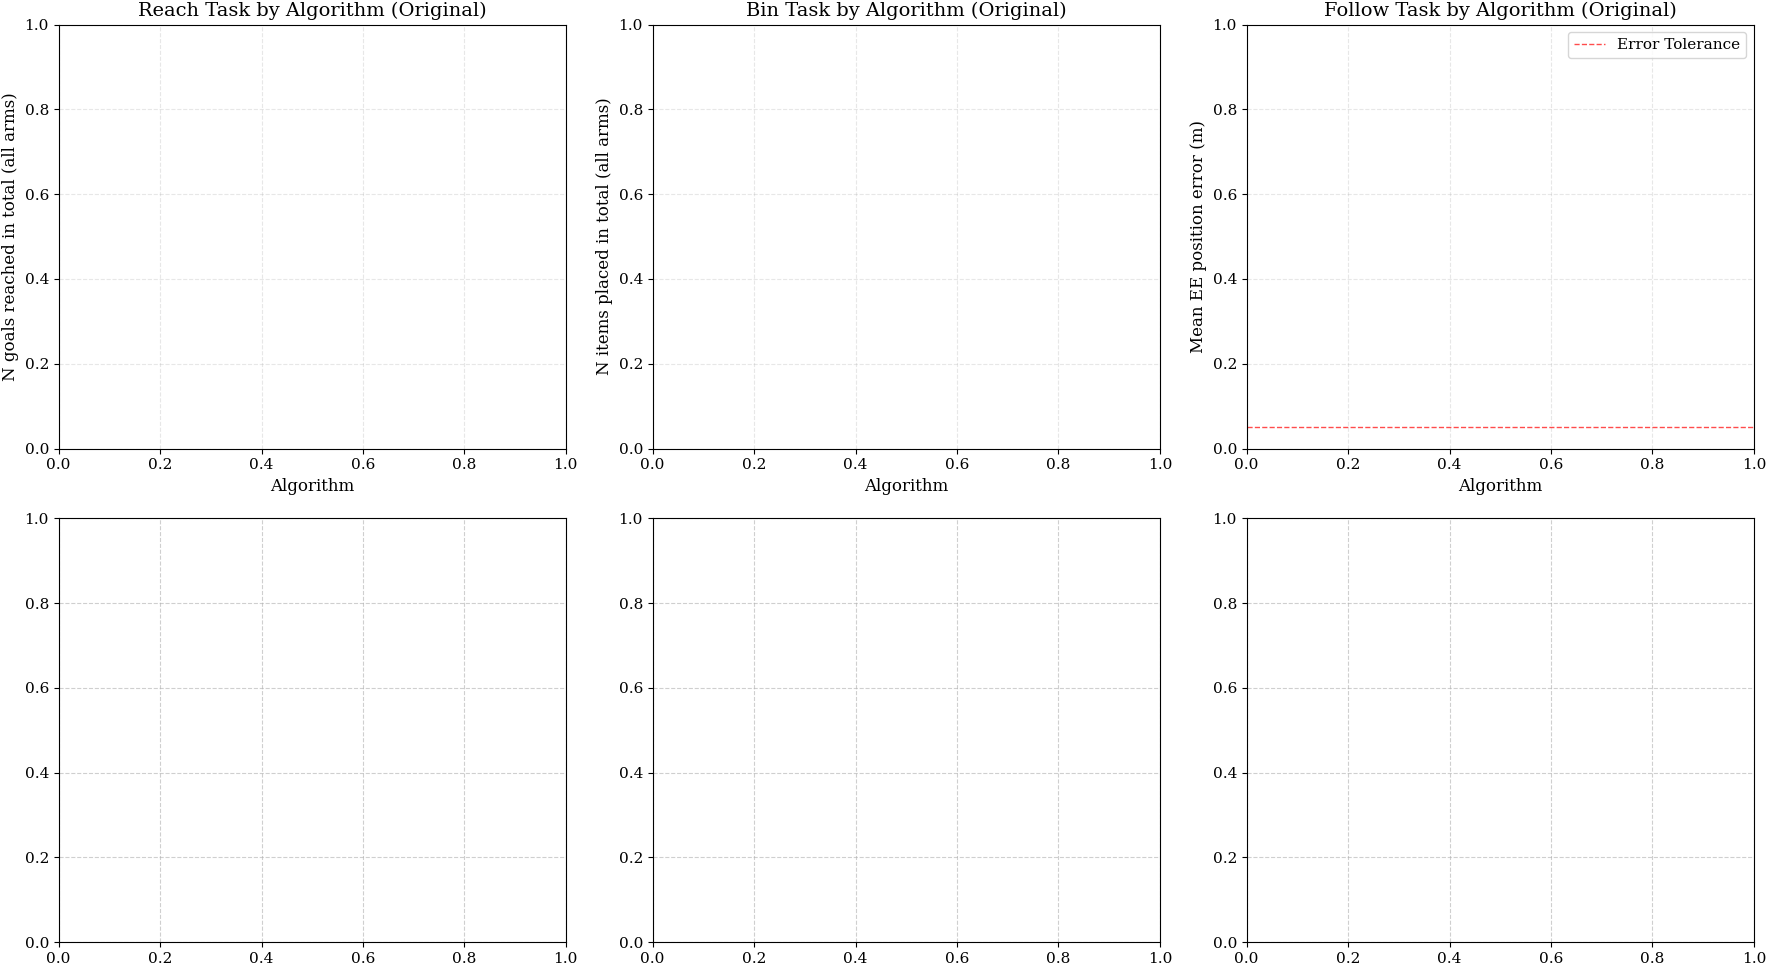

In [42]:
if task_analysis:
    # Comment out to not plot

    # make_task_success_plots(overall_df, normalize=False, add_subtotal_figure=False)
    # With normalization
    # make_task_success_plots(overall_df, normalize=True, add_subtotal_figure=False)
    #With normalization and subtotal
    make_task_success_plots(overall_df, normalize=True, add_subtotal_figure=True)

In [43]:
# Minimal script to analyze CBSMP1 tasks as reach tasks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_cbsmp1_as_reach(all_sims, df_collisions, successfull_parsing, sim_paths):
    """
    Analyze CBSMP1 tasks as reach tasks with proper scoring and collision analysis.
    """
    
    # 1. Create CBSMP1-specific task analysis (treat as reach task)
    def analyze_cbsmp1_tasks(all_sims):
        """Analyze CBSMP1 tasks using reach task methodology"""
        df_cols_shared = ['alg', 'task_level', 'task_seed', 'n_arms', 'wsteps_total', 'sim_id']
        task_specific_cols_reach = ['reached_total', 'changed_total']
        reach_cols = df_cols_shared + task_specific_cols_reach
        reach_rows = []
        successfull_parsing_reach = []

        for i, sim in enumerate(all_sims):
            if sim.meta_data['task_type'] != 'CBSMP1':
                continue
                
            try:
                task_df = sim.task_df
                alg = sim.meta_data['alg']
                task_level = sim.meta_data['task_level']
                n_arms = sim.meta_data['n_arms']
                seed = sim.meta_data['task_seed']
                sim_id = sim.meta_data['timestamp']
                w_steps_total = task_df['w_step'].max()

                arm_col_names = [c for c in task_df.columns if c.startswith('arm_')]
                df_tmp = sim.task_df.copy()[['w_step', *arm_col_names]]
                
                row = [alg, task_level, seed, n_arms, w_steps_total, sim_id]
                
                # Process as reach task - look for reached/changed targets
                df_tmp_last_step = df_tmp[df_tmp['w_step'] == w_steps_total]
                if df_tmp_last_step.shape[0] > 1:
                    print(f'Warning: Multiple rows in last step for sim {sim_id}')
                    print(df_tmp_last_step)
                
                df_last_step = df_tmp_last_step.iloc[0]
                
                # Look for reach task columns (reached_total, changed_total)
                total_reached_cols = []
                total_changed_cols = []
                for c in df_tmp_last_step.columns:
                    if 'total_reached' in str(c):
                        total_reached_cols.append(c)
                    if 'total_changed' in str(c):
                        total_changed_cols.append(c)
                
                if len(total_reached_cols) > 0:
                    total_reached_alg = df_last_step[total_reached_cols].sum()
                else:
                    # If no reach columns, try to extract from error columns (CBSMP1 specific)
                    # This is a fallback - you might need to adjust based on your data structure
                    total_reached_alg = 0
                    print(f'Warning: No reached columns found for CBSMP1 sim {sim_id}')
                
                if len(total_changed_cols) > 0:
                    total_changed_alg = df_last_step[total_changed_cols].sum()
                else:
                    total_changed_alg = 0
                    print(f'Warning: No changed columns found for CBSMP1 sim {sim_id}')

                row.extend([total_reached_alg, total_changed_alg])
                reach_rows.append(row)
                successfull_parsing_reach.append(i)
                
            except Exception as e:
                print(f'Error processing CBSMP1 simulation {i}: {e}')
                continue

        df_reach = pd.DataFrame(reach_rows, columns=reach_cols)
        return df_reach, successfull_parsing_reach

    # 2. Analyze CBSMP1 tasks
    print("Analyzing CBSMP1 tasks as reach tasks...")
    df_cbsmp1_reach, successfull_parsing_cbsmp1 = analyze_cbsmp1_tasks(all_sims)
    
    print(f'Successfully parsed {len(successfull_parsing_cbsmp1)} CBSMP1 tasks')
    print(f'CBSMP1 reach dataframe shape: {df_cbsmp1_reach.shape}')
    
    if not df_cbsmp1_reach.empty:
        print(f'CBSMP1 reach data columns: {df_cbsmp1_reach.columns.tolist()}')
        print(f'CBSMP1 reach data sample:')
        print(df_cbsmp1_reach.head())
    
    # 3. Create overall dataframe with CBSMP1 as reach task
    def make_overall_df_with_cbsmp1(df_collisions, successfull_parsing, sim_paths, df_cbsmp1_reach, colfree_only=False):
        """Create overall dataframe treating CBSMP1 as reach task"""
        import yaml
        
        overall_df = df_collisions.copy()
        overall_df[['weight', 'trust', 'cov']] = -1, -1, -1
        
        for sim in successfull_parsing:
            sim_id = sim.meta_data['timestamp']
            all_sims = sim_paths
            
            for dir_path in all_sims:
                if sim_id in dir_path:
                    # Add meta data
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'alg'] = sim.meta_data['alg']
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'task_type'] = sim.meta_data['task_type']
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'task_level'] = sim.meta_data['task_level']
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'task_seed'] = sim.meta_data['task_seed']
                    
                    task_type = sim.meta_data['task_type']
                    
                    # Handle CBSMP1 as reach task
                    if task_type == 'CBSMP1':
                        if not df_cbsmp1_reach.empty and sim_id in df_cbsmp1_reach['sim_id'].values:
                            overall_df.loc[overall_df['sim_id'] == sim_id, 'changed_total'] = \
                                df_cbsmp1_reach[df_cbsmp1_reach['sim_id'] == sim_id]['changed_total'].values[0]
                            overall_df.loc[overall_df['sim_id'] == sim_id, 'reached_total'] = \
                                df_cbsmp1_reach[df_cbsmp1_reach['sim_id'] == sim_id]['reached_total'].values[0]
                        else:
                            print(f'Warning: No CBSMP1 data found for sim_id {sim_id}')
                            overall_df.loc[overall_df['sim_id'] == sim_id, 'changed_total'] = 0
                            overall_df.loc[overall_df['sim_id'] == sim_id, 'reached_total'] = 0
                    
                    # Add tuning parameters if they exist
                    tuning_path = os.path.join(dir_path, 'particle_cfg.yml')
                    if os.path.exists(tuning_path):
                        try:
                            with open(tuning_path, 'r') as f:
                                particle_cfg = yaml.load(f, Loader=yaml.FullLoader)
                                overall_df.loc[overall_df['sim_id'] == sim_id, 'weight'] = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['weight']
                                overall_df.loc[overall_df['sim_id'] == sim_id, 'trust'] = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['wta_trust']
                                overall_df.loc[overall_df['sim_id'] == sim_id, 'cov'] = particle_cfg['mppi']['init_cov']
                        except Exception as e:
                            print(f'Error loading tuning parameters for {sim_id}: {e}')
        
        # Calculate task scores
        try:
            overall_df['task_score_reach'] = overall_df['reached_total'] / overall_df['reached_total'].max()
        except:
            overall_df['task_score_reach'] = 0

        
        try:
            # For follow and CBSMP1 tasks
            follow_cbsmp1_mask = overall_df['task_type'].isin(['follow', 'CBSMP1'])
            if follow_cbsmp1_mask.any():
                follow_cbsmp1_data = overall_df[follow_cbsmp1_mask]['p_err_mean_arms_wsteps']
                normalized_sim_follow_mean_error = (follow_cbsmp1_data - follow_cbsmp1_data.min()) / (follow_cbsmp1_data.max() - follow_cbsmp1_data.min())
                overall_df.loc[follow_cbsmp1_mask, 'task_score_follow'] = 1 - normalized_sim_follow_mean_error
            else:
                overall_df['task_score_follow'] = 0
        except:
            overall_df['task_score_follow'] = 0

            
        
        # Fill NaNs with 0
        overall_df[['task_score_reach']] = overall_df[['task_score_reach']].fillna(0)
        
        # Calculate safety scores
        overall_df['safety_score_rrc'] = 1 - overall_df['rrc_chance']
        overall_df['safety_score_rec'] = 1 - overall_df['rre_chance']
        
        if colfree_only:
            overall_df = overall_df[(overall_df['rrc_chance'] == 0.0) & (overall_df['rre_chance'] == 0.0)]
        
        overall_df['task_score'] = overall_df['task_score_reach']
        
        return overall_df
    # Fill NaNs with 0
    overall_df[['task_score_reach', 'task_score_bin', 'task_score_follow']] = \
        overall_df[['task_score_reach', 'task_score_bin', 'task_score_follow']].fillna(0)

    # Calculate combined task score
    overall_df['task_score'] = overall_df[['task_score_reach', 'task_score_bin', 'task_score_follow']].sum(axis=1)
    # 4. Create overall dataframe
    print("Creating overall dataframe with CBSMP1 as reach task...")
    overall_df = make_overall_df_with_cbsmp1(df_collisions, successfull_parsing, sim_paths, df_cbsmp1_reach, colfree_only=False)
    
    print(f'Overall dataframe shape: {overall_df.shape}')
    print(f'Task types in overall_df: {overall_df["task_type"].unique()}')
    
    # 5. Create CBSMP1-specific plots
    def plot_cbsmp1_analysis(overall_df):
        """Create plots specifically for CBSMP1 analysis"""
        
        # Filter for CBSMP1 tasks only
        cbsmp1_df = overall_df[overall_df['task_type'] == 'CBSMP1']
        
        if cbsmp1_df.empty:
            print("No CBSMP1 data found for plotting")
            return
        
        # Create figure with subplots
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # Plot 1: Task Performance (Reach Score)
        algorithms = cbsmp1_df['alg'].unique()
        colors = plt.cm.tab10(np.linspace(0, 1, len(algorithms)))
        
        alg_data = [cbsmp1_df[cbsmp1_df['alg'] == alg]['reached_total'] for alg in algorithms]
        bp1 = axes[0].boxplot(alg_data, labels=algorithms, patch_artist=True)
        for patch, color in zip(bp1['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        axes[0].set_title('CBSMP1 Task Performance (Goals Reached)')
        axes[0].set_xlabel('Algorithm')
        axes[0].set_ylabel('Number of Goals Reached')
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Collision Analysis
        alg_data_collision = [cbsmp1_df[cbsmp1_df['alg'] == alg]['rrc_chance'] for alg in algorithms]
        bp2 = axes[1].boxplot(alg_data_collision, labels=algorithms, patch_artist=True)
        for patch, color in zip(bp2['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        axes[1].set_title('CBSMP1 Robot-Robot Collision Risk')
        axes[1].set_xlabel('Algorithm')
        axes[1].set_ylabel('Collision Chance')
        axes[1].grid(True, alpha=0.3)
        
        # Plot 3: Combined Score
        alg_data_combined = [cbsmp1_df[cbsmp1_df['alg'] == alg]['task_score'] for alg in algorithms]
        bp3 = axes[2].boxplot(alg_data_combined, labels=algorithms, patch_artist=True)
        for patch, color in zip(bp3['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        axes[2].set_title('CBSMP1 Combined Score')
        axes[2].set_xlabel('Algorithm')
        axes[2].set_ylabel('Normalized Task Score')
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print("\nCBSMP1 Analysis Summary:")
        print("=" * 50)
        for alg in algorithms:
            alg_data = cbsmp1_df[cbsmp1_df['alg'] == alg]
            if not alg_data.empty:
                print(f"\n{alg}:")
                print(f"  Goals Reached: {alg_data['reached_total'].mean():.2f} ± {alg_data['reached_total'].std():.2f}")
                print(f"  Collision Chance: {alg_data['rrc_chance'].mean():.3f} ± {alg_data['rrc_chance'].std():.3f}")
                print(f"  Task Score: {alg_data['task_score'].mean():.3f} ± {alg_data['task_score'].std():.3f}")
                print(f"  N simulations: {len(alg_data)}")

    # 6. Create plots
    print("Creating CBSMP1 analysis plots...")
    plot_cbsmp1_analysis(overall_df)
    
    return overall_df, df_cbsmp1_reach

# Usage example:
# overall_df, df_cbsmp1_reach = analyze_cbsmp1_as_reach(all_sims, df_collisions, successfull_parsing, valid_sim_dir_paths)

In [44]:
def analyze_cbsmp1_minimal(all_sims, df_collisions, successfull_parsing, sim_paths):
    """
    Minimal function to analyze CBSMP1 tasks as follow tasks.
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 1. Extract CBSMP1 data as follow task
    print("Extracting CBSMP1 data as follow task...")
    cbsmp1_data = []
    
    for sim in all_sims:
        if sim.meta_data['task_type'] != 'CBSMP1':
            continue
            
        try:
            task_df = sim.task_df
            sim_id = sim.meta_data['timestamp']
            alg = sim.meta_data['alg']
            task_level = sim.meta_data['task_level']
            n_arms = sim.meta_data['n_arms']
            
            # Extract error data for each arm
            for _, row in task_df.iterrows():
                w_step = row['w_step']
                
                # Calculate mean position error across all arms
                p_errors = []
                for arm_idx in range(n_arms):
                    err_col = f'arm_{arm_idx}_err'
                    if err_col in row and pd.notna(row[err_col]):
                        if isinstance(row[err_col], (list, tuple)) and len(row[err_col]) > 0:
                            p_errors.append(row[err_col][0])  # position error
                        else:
                            p_errors.append(0)
                    else:
                        p_errors.append(0)
                
                mean_p_error = np.mean(p_errors) if p_errors else 0
                
                cbsmp1_data.append({
                    'sim_id': sim_id,
                    'alg': alg,
                    'task_level': task_level,
                    'n_arms': n_arms,
                    'w_step': w_step,
                    'p_err_mean': mean_p_error
                })
                
        except Exception as e:
            print(f'Error processing CBSMP1 sim {sim_id}: {e}')
            continue
    
    # 2. Create DataFrames
    df_cbsmp1 = pd.DataFrame(cbsmp1_data)
    
    if df_cbsmp1.empty:
        print("No CBSMP1 data found!")
        return None, None
    
    # Calculate mean error per simulation
    df_cbsmp1_sim = df_cbsmp1.groupby(['sim_id', 'alg', 'task_level', 'n_arms']).agg({
        'p_err_mean': 'mean'
    }).reset_index()
    
    print(f"Processed {len(df_cbsmp1_sim)} CBSMP1 simulations")
    
    # 3. Create overall dataframe with CBSMP1 as follow task
    overall_df = df_collisions.copy()
    
    # Add CBSMP1 data to overall_df
    for _, row in df_cbsmp1_sim.iterrows():
        sim_id = row['sim_id']
        if sim_id in overall_df['sim_id'].values:
            overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_mean_arms_wsteps'] = row['p_err_mean']
            overall_df.loc[overall_df['sim_id'] == sim_id, 'task_type'] = 'CBSMP1'
    
    # Calculate task scores
    overall_df['task_score_reach'] = 0
    overall_df['task_score_bin'] = 0
    
    # For CBSMP1 (follow task): lower error = higher score
    cbsmp1_mask = overall_df['task_type'] == 'CBSMP1'
    if cbsmp1_mask.any():
        cbsmp1_errors = overall_df[cbsmp1_mask]['p_err_mean_arms_wsteps']
        if cbsmp1_errors.max() > cbsmp1_errors.min():
            normalized_errors = (cbsmp1_errors - cbsmp1_errors.min()) / (cbsmp1_errors.max() - cbsmp1_errors.min())
            overall_df.loc[cbsmp1_mask, 'task_score_follow'] = 1 - normalized_errors
        else:
            overall_df.loc[cbsmp1_mask, 'task_score_follow'] = 1.0
    else:
        overall_df['task_score_follow'] = 0
    
    # Fill NaNs
    overall_df[['task_score_reach', 'task_score_bin', 'task_score_follow']] = \
        overall_df[['task_score_reach', 'task_score_bin', 'task_score_follow']].fillna(0)
    
    # Calculate safety scores
    overall_df['safety_score_rrc'] = 1 - overall_df['rrc_chance']
    overall_df['safety_score_rec'] = 1 - overall_df['rre_chance']
    
    # Combined task score
    overall_df['task_score'] = overall_df[['task_score_reach', 'task_score_bin', 'task_score_follow']].sum(axis=1)
    
    # 4. Create plots
    print("Creating CBSMP1 analysis plots...")
    
    # Filter CBSMP1 data
    cbsmp1_df = overall_df[overall_df['task_type'] == 'CBSMP1']
    
    if cbsmp1_df.empty:
        print("No CBSMP1 data for plotting!")
        return overall_df, df_cbsmp1_sim
    
    # Create plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    algorithms = cbsmp1_df['alg'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(algorithms)))
    
    # Plot 1: Position Error (lower is better)
    alg_data = [cbsmp1_df[cbsmp1_df['alg'] == alg]['p_err_mean_arms_wsteps'] for alg in algorithms]
    bp1 = axes[0].boxplot(alg_data, labels=algorithms, patch_artist=True)
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[0].set_title('CBSMP1 Position Error (Lower is Better)')
    axes[0].set_xlabel('Algorithm')
    axes[0].set_ylabel('Mean Position Error (m)')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='Error Tolerance')
    axes[0].legend()
    
    # Plot 2: Collision Risk
    alg_data_collision = [cbsmp1_df[cbsmp1_df['alg'] == alg]['rrc_chance'] for alg in algorithms]
    bp2 = axes[1].boxplot(alg_data_collision, labels=algorithms, patch_artist=True)
    for patch, color in zip(bp2['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[1].set_title('CBSMP1 Collision Risk')
    axes[1].set_xlabel('Algorithm')
    axes[1].set_ylabel('Collision Chance')
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Task Score
    alg_data_score = [cbsmp1_df[cbsmp1_df['alg'] == alg]['task_score'] for alg in algorithms]
    bp3 = axes[2].boxplot(alg_data_score, labels=algorithms, patch_artist=True)
    for patch, color in zip(bp3['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[2].set_title('CBSMP1 Task Score')
    axes[2].set_xlabel('Algorithm')
    axes[2].set_ylabel('Normalized Score')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 5. Print summary
    print("\nCBSMP1 Analysis Summary:")
    print("=" * 50)
    for alg in algorithms:
        alg_data = cbsmp1_df[cbsmp1_df['alg'] == alg]
        if not alg_data.empty:
            print(f"\n{alg}:")
            print(f"  Position Error: {alg_data['p_err_mean_arms_wsteps'].mean():.4f} ± {alg_data['p_err_mean_arms_wsteps'].std():.4f}")
            print(f"  Collision Chance: {alg_data['rrc_chance'].mean():.3f} ± {alg_data['rrc_chance'].std():.3f}")
            print(f"  Task Score: {alg_data['task_score'].mean():.3f} ± {alg_data['task_score'].std():.3f}")
            print(f"  N simulations: {len(alg_data)}")
    
    return overall_df, df_cbsmp1_sim

# Usage:
overall_df, df_cbsmp1 = analyze_cbsmp1_minimal(all_sims, df_collisions, successfull_parsing, valid_sim_dir_paths)

Extracting CBSMP1 data as follow task...
No CBSMP1 data found!


In [45]:
def debug_cbsmp1_data(all_sims, disk_sims):
    """
    Debug function to check what CBSMP1 data is available
    """
    print("=== DEBUGGING CBSMP1 DATA ===")
    
    # Check all_sims
    print(f"Total simulations in all_sims: {len(all_sims)}")
    cbsmp1_in_all = [sim for sim in all_sims if sim.meta_data['task_type'] == 'CBSMP1']
    print(f"CBSMP1 simulations in all_sims: {len(cbsmp1_in_all)}")
    
    # Check disk_sims
    print(f"Total simulations in disk_sims: {len(disk_sims)}")
    cbsmp1_in_disk = [sim for sim in disk_sims if sim.meta_data['task_type'] == 'CBSMP1']
    print(f"CBSMP1 simulations in disk_sims: {len(cbsmp1_in_disk)}")
    
    # Check what's in the simulations
    if cbsmp1_in_disk:
        sim = cbsmp1_in_disk[0]
        print(f"\nFirst CBSMP1 simulation details:")
        print(f"  sim_id: {sim.meta_data['timestamp']}")
        print(f"  alg: {sim.meta_data['alg']}")
        print(f"  task_type: {sim.meta_data['task_type']}")
        print(f"  n_arms: {sim.meta_data['n_arms']}")
        print(f"  task_df shape: {sim.task_df.shape}")
        print(f"  task_df columns: {sim.task_df.columns.tolist()}")
        
        # Check for error columns
        error_cols = [c for c in sim.task_df.columns if 'err' in c]
        print(f"  Error columns: {error_cols}")
        
        if error_cols:
            print(f"  Sample error data from first row:")
            for col in error_cols[:3]:  # Show first 3 error columns
                print(f"    {col}: {sim.task_df[col].iloc[0]}")
    
    return cbsmp1_in_disk

# Run this first to debug:
cbsmp1_sims = debug_cbsmp1_data(all_sims, disk_sims)

=== DEBUGGING CBSMP1 DATA ===
Total simulations in all_sims: 0
CBSMP1 simulations in all_sims: 0
Total simulations in disk_sims: 1
CBSMP1 simulations in disk_sims: 1

First CBSMP1 simulation details:
  sim_id: 2025-09-11_16:50:05
  alg: O(1200, 1)
  task_type: CBSMP1
  n_arms: 16
  task_df shape: (0, 0)
  task_df columns: []
  Error columns: []


In [46]:
def analyze_cbsmp1_minimal_raw(disk_sims, df_collisions, successfull_parsing, sim_paths):
    """
    Minimal function to analyze CBSMP1 tasks using raw simulation data.
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 1. Extract CBSMP1 data from raw simulation data
    print("Extracting CBSMP1 data from raw simulation data...")
    cbsmp1_data = []
    
    for sim in disk_sims:
        if sim.meta_data['task_type'] != 'CBSMP1':
            continue
            
        try:
            sim_id = sim.meta_data['timestamp']
            alg = sim.meta_data['alg']
            task_level = sim.meta_data['task_level']
            n_arms = sim.meta_data['n_arms']
            
            print(f"Processing CBSMP1 sim: {sim_id}, alg: {alg}, n_arms: {n_arms}")
            
            # Access raw simulation data instead of task_df
            sim_stats = sim.sim_stats
            print(f"Available stat managers: {list(sim_stats.keys())}")
            
            # Look for agent data
            agent_stats = []
            for key in sim_stats.keys():
                if 'agent' in key:
                    agent_stats.append(key)
            
            print(f"Agent stat managers: {agent_stats}")
            
            if not agent_stats:
                print("No agent data found!")
                continue
            
            # Extract data from the first agent (assuming all agents have similar data)
            agent_key = agent_stats[0]
            agent_data = sim_stats[agent_key]
            print(f"Agent data keys: {list(agent_data.keys())}")
            
            # Look for error data in agent stats
            error_data = []
            w_steps = []
            
            for stat_name, stat_values in agent_data.items():
                if 'err' in stat_name.lower():
                    print(f"Found error stat: {stat_name}")
                    print(f"  Sample data: {stat_values[:3] if len(stat_values) > 0 else 'Empty'}")
                    
                    # Extract error values
                    for entry in stat_values:
                        if len(entry) >= 2:  # Should have (keys, values) tuple
                            keys, values = entry
                            if 'w_step' in keys:
                                w_step = keys['w_step']
                                w_steps.append(w_step)
                                
                                # Extract position error (assuming it's the first element)
                                if isinstance(values, (list, tuple)) and len(values) > 0:
                                    if isinstance(values[0], (list, tuple)) and len(values[0]) > 0:
                                        p_error = values[0][0]  # First element of first error
                                    else:
                                        p_error = values[0] if isinstance(values[0], (int, float)) else 0
                                else:
                                    p_error = 0
                                
                                error_data.append({
                                    'w_step': w_step,
                                    'p_error': p_error
                                })
            
            if not error_data:
                print("No error data found in agent stats!")
                # Try alternative approach - look for any numerical data
                for stat_name, stat_values in agent_data.items():
                    print(f"Stat {stat_name}: {len(stat_values)} entries")
                    if len(stat_values) > 0:
                        print(f"  Sample entry: {stat_values[0]}")
                continue
            
            # Calculate mean error per simulation
            mean_error = np.mean([entry['p_error'] for entry in error_data])
            
            cbsmp1_data.append({
                'sim_id': sim_id,
                'alg': alg,
                'task_level': task_level,
                'n_arms': n_arms,
                'p_err_mean': mean_error,
                'n_data_points': len(error_data)
            })
            
            print(f"  Extracted {len(error_data)} error data points")
            print(f"  Mean error: {mean_error:.4f}")
            
        except Exception as e:
            print(f'Error processing CBSMP1 sim {sim_id}: {e}')
            import traceback
            traceback.print_exc()
            continue
    
    # 2. Create DataFrames
    df_cbsmp1 = pd.DataFrame(cbsmp1_data)
    
    if df_cbsmp1.empty:
        print("No CBSMP1 data found!")
        return None, None
    
    print(f"Processed {len(df_cbsmp1)} CBSMP1 simulations")
    print(f"CBSMP1 data:")
    print(df_cbsmp1)
    
    # 3. Create overall dataframe with CBSMP1 as follow task
    overall_df = df_collisions.copy()
    
    # Add CBSMP1 data to overall_df
    for _, row in df_cbsmp1.iterrows():
        sim_id = row['sim_id']
        if sim_id in overall_df['sim_id'].values:
            overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_mean_arms_wsteps'] = row['p_err_mean']
            overall_df.loc[overall_df['sim_id'] == sim_id, 'task_type'] = 'CBSMP1'
    
    # Calculate task scores
    overall_df['task_score_reach'] = 0
    overall_df['task_score_bin'] = 0
    
    # For CBSMP1 (follow task): lower error = higher score
    cbsmp1_mask = overall_df['task_type'] == 'CBSMP1'
    if cbsmp1_mask.any():
        cbsmp1_errors = overall_df[cbsmp1_mask]['p_err_mean_arms_wsteps']
        if cbsmp1_errors.max() > cbsmp1_errors.min():
            normalized_errors = (cbsmp1_errors - cbsmp1_errors.min()) / (cbsmp1_errors.max() - cbsmp1_errors.min())
            overall_df.loc[cbsmp1_mask, 'task_score_follow'] = 1 - normalized_errors
        else:
            overall_df.loc[cbsmp1_mask, 'task_score_follow'] = 1.0
    else:
        overall_df['task_score_follow'] = 0
    
    # Fill NaNs
    overall_df[['task_score_reach', 'task_score_bin', 'task_score_follow']] = \
        overall_df[['task_score_reach', 'task_score_bin', 'task_score_follow']].fillna(0)
    
    # Calculate safety scores
    overall_df['safety_score_rrc'] = 1 - overall_df['rrc_chance']
    overall_df['safety_score_rec'] = 1 - overall_df['rre_chance']
    
    # Combined task score
    overall_df['task_score'] = overall_df[['task_score_reach', 'task_score_bin', 'task_score_follow']].sum(axis=1)
    
    # 4. Create plots
    print("Creating CBSMP1 analysis plots...")
    
    # Filter CBSMP1 data
    cbsmp1_df = overall_df[overall_df['task_type'] == 'CBSMP1']
    
    if cbsmp1_df.empty:
        print("No CBSMP1 data for plotting!")
        return overall_df, df_cbsmp1
    
    # Create plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    algorithms = cbsmp1_df['alg'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(algorithms)))
    
    # Plot 1: Position Error (lower is better)
    alg_data = [cbsmp1_df[cbsmp1_df['alg'] == alg]['p_err_mean_arms_wsteps'] for alg in algorithms]
    bp1 = axes[0].boxplot(alg_data, labels=algorithms, patch_artist=True)
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[0].set_title('CBSMP1 Position Error (Lower is Better)')
    axes[0].set_xlabel('Algorithm')
    axes[0].set_ylabel('Mean Position Error (m)')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='Error Tolerance')
    axes[0].legend()
    
    # Plot 2: Collision Risk
    alg_data_collision = [cbsmp1_df[cbsmp1_df['alg'] == alg]['rrc_chance'] for alg in algorithms]
    bp2 = axes[1].boxplot(alg_data_collision, labels=algorithms, patch_artist=True)
    for patch, color in zip(bp2['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[1].set_title('CBSMP1 Collision Risk')
    axes[1].set_xlabel('Algorithm')
    axes[1].set_ylabel('Collision Chance')
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Task Score
    alg_data_score = [cbsmp1_df[cbsmp1_df['alg'] == alg]['task_score'] for alg in algorithms]
    bp3 = axes[2].boxplot(alg_data_score, labels=algorithms, patch_artist=True)
    for patch, color in zip(bp3['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[2].set_title('CBSMP1 Task Score')
    axes[2].set_xlabel('Algorithm')
    axes[2].set_ylabel('Normalized Score')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 5. Print summary
    print("\nCBSMP1 Analysis Summary:")
    print("=" * 50)
    for alg in algorithms:
        alg_data = cbsmp1_df[cbsmp1_df['alg'] == alg]
        if not alg_data.empty:
            print(f"\n{alg}:")
            print(f"  Position Error: {alg_data['p_err_mean_arms_wsteps'].mean():.4f} ± {alg_data['p_err_mean_arms_wsteps'].std():.4f}")
            print(f"  Collision Chance: {alg_data['rrc_chance'].mean():.3f} ± {alg_data['rrc_chance'].std():.3f}")
            print(f"  Task Score: {alg_data['task_score'].mean():.3f} ± {alg_data['task_score'].std():.3f}")
            print(f"  N simulations: {len(alg_data)}")
    
    return overall_df, df_cbsmp1

# Usage:
overall_df, df_cbsmp1 = analyze_cbsmp1_minimal_raw(disk_sims, df_collisions, successfull_parsing, valid_sim_dir_paths)

Extracting CBSMP1 data from raw simulation data...
Processing CBSMP1 sim: 2025-09-11_16:50:05, alg: O(1200, 1), n_arms: 16
Available stat managers: ['task_stats', 'agent_0', 'agent_1', 'agent_2', 'agent_3', 'agent_4', 'agent_5', 'agent_6', 'agent_7', 'agent_8', 'agent_9', 'agent_10', 'agent_11', 'agent_12', 'agent_13', 'agent_14', 'agent_15']
Agent stat managers: ['agent_0', 'agent_1', 'agent_2', 'agent_3', 'agent_4', 'agent_5', 'agent_6', 'agent_7', 'agent_8', 'agent_9', 'agent_10', 'agent_11', 'agent_12', 'agent_13', 'agent_14', 'agent_15']
Agent data keys: ['env_cols', 'link_target_poses', 'arm_cols', 'total_planning_time', 'spheres']
No error data found in agent stats!
Stat env_cols: 7000 entries
  Sample entry: ({'tsys': 1757598670.9316745, 'tphysics': 0.36666668578982353, 'w_step': 1, 'a_step': 2}, tensor([False]))
Stat link_target_poses: 7000 entries
  Sample entry: ({'tsys': 1757598670.9316883, 'tphysics': 0.36666668578982353, 'w_step': 1, 'a_step': 2}, ({'ee_link': (array([2.4

In [47]:
def analyze_cbsmp1_minimal_poses(disk_sims, df_collisions, successfull_parsing, sim_paths):
    """
    Minimal function to analyze CBSMP1 tasks using link_target_poses data.
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 1. Extract CBSMP1 data from link_target_poses
    print("Extracting CBSMP1 data from link_target_poses...")
    cbsmp1_data = []
    
    for sim in disk_sims:
        if sim.meta_data['task_type'] != 'CBSMP1':
            continue
            
        try:
            sim_id = sim.meta_data['timestamp']
            alg = sim.meta_data['alg']
            task_level = sim.meta_data['task_level']
            n_arms = sim.meta_data['n_arms']
            
            print(f"Processing CBSMP1 sim: {sim_id}, alg: {alg}, n_arms: {n_arms}")
            
            # Access raw simulation data
            sim_stats = sim.sim_stats
            
            # Get data from first agent (assuming all agents have similar data)
            agent_key = 'agent_0'
            agent_data = sim_stats[agent_key]
            
            # Extract link_target_poses data
            if 'link_target_poses' not in agent_data:
                print("No link_target_poses data found!")
                continue
            
            poses_data = agent_data['link_target_poses']
            print(f"Found {len(poses_data)} pose data points")
            
            # Calculate position errors
            position_errors = []
            w_steps = []
            
            for entry in poses_data:
                if len(entry) >= 2:
                    keys, values = entry
                    w_step = keys['w_step']
                    w_steps.append(w_step)
                    
                    # Extract poses from the data structure
                    # values should be: (ee_poses, ee_links, target_poses)
                    if len(values) >= 3:
                        ee_poses, ee_links, target_poses = values
                        
                        # Calculate position error for each arm
                        arm_errors = []
                        for arm_idx in range(n_arms):
                            try:
                                # Get end-effector position for this arm
                                ee_key = f'ee_link'
                                if ee_key in ee_poses:
                                    ee_pos = np.array(ee_poses[ee_key][0])  # position part
                                    
                                    # Get target position for this arm
                                    target_key = f'target_{arm_idx}_ee_link'
                                    if target_key in target_poses:
                                        target_pos = np.array(target_poses[target_key][0])  # position part
                                        
                                        # Calculate position error
                                        pos_error = np.linalg.norm(ee_pos - target_pos)
                                        arm_errors.append(pos_error)
                                    else:
                                        arm_errors.append(0)
                                else:
                                    arm_errors.append(0)
                            except Exception as e:
                                print(f"Error processing arm {arm_idx}: {e}")
                                arm_errors.append(0)
                        
                        # Calculate mean error across all arms
                        mean_error = np.mean(arm_errors) if arm_errors else 0
                        position_errors.append(mean_error)
                    else:
                        position_errors.append(0)
            
            if not position_errors:
                print("No position error data calculated!")
                continue
            
            # Calculate mean error per simulation
            mean_error = np.mean(position_errors)
            
            cbsmp1_data.append({
                'sim_id': sim_id,
                'alg': alg,
                'task_level': task_level,
                'n_arms': n_arms,
                'p_err_mean': mean_error,
                'n_data_points': len(position_errors)
            })
            
            print(f"  Calculated {len(position_errors)} position error data points")
            print(f"  Mean error: {mean_error:.4f}")
            
        except Exception as e:
            print(f'Error processing CBSMP1 sim {sim_id}: {e}')
            import traceback
            traceback.print_exc()
            continue
    
    # 2. Create DataFrames
    df_cbsmp1 = pd.DataFrame(cbsmp1_data)
    
    if df_cbsmp1.empty:
        print("No CBSMP1 data found!")
        return None, None
    
    print(f"Processed {len(df_cbsmp1)} CBSMP1 simulations")
    print(f"CBSMP1 data:")
    print(df_cbsmp1)
    
    # 3. Create overall dataframe with CBSMP1 as follow task
    overall_df = df_collisions.copy()
    
    # Add CBSMP1 data to overall_df
    for _, row in df_cbsmp1.iterrows():
        sim_id = row['sim_id']
        if sim_id in overall_df['sim_id'].values:
            overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_mean_arms_wsteps'] = row['p_err_mean']
            overall_df.loc[overall_df['sim_id'] == sim_id, 'task_type'] = 'CBSMP1'
    
    # Calculate task scores
    overall_df['task_score_reach'] = 0
    overall_df['task_score_bin'] = 0
    
    # For CBSMP1 (follow task): lower error = higher score
    cbsmp1_mask = overall_df['task_type'] == 'CBSMP1'
    if cbsmp1_mask.any():
        cbsmp1_errors = overall_df[cbsmp1_mask]['p_err_mean_arms_wsteps']
        if cbsmp1_errors.max() > cbsmp1_errors.min():
            normalized_errors = (cbsmp1_errors - cbsmp1_errors.min()) / (cbsmp1_errors.max() - cbsmp1_errors.min())
            overall_df.loc[cbsmp1_mask, 'task_score_follow'] = 1 - normalized_errors
        else:
            overall_df.loc[cbsmp1_mask, 'task_score_follow'] = 1.0
    else:
        overall_df['task_score_follow'] = 0
    
    # Fill NaNs
    overall_df[['task_score_reach', 'task_score_bin', 'task_score_follow']] = \
        overall_df[['task_score_reach', 'task_score_bin', 'task_score_follow']].fillna(0)
    
    # Calculate safety scores
    overall_df['safety_score_rrc'] = 1 - overall_df['rrc_chance']
    overall_df['safety_score_rec'] = 1 - overall_df['rre_chance']
    
    # Combined task score
    overall_df['task_score'] = overall_df[['task_score_reach', 'task_score_bin', 'task_score_follow']].sum(axis=1)
    
    # 4. Create plots
    print("Creating CBSMP1 analysis plots...")
    
    # Filter CBSMP1 data
    cbsmp1_df = overall_df[overall_df['task_type'] == 'CBSMP1']
    
    if cbsmp1_df.empty:
        print("No CBSMP1 data for plotting!")
        return overall_df, df_cbsmp1
    
    # Create plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    algorithms = cbsmp1_df['alg'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(algorithms)))
    
    # Plot 1: Position Error (lower is better)
    alg_data = [cbsmp1_df[cbsmp1_df['alg'] == alg]['p_err_mean_arms_wsteps'] for alg in algorithms]
    bp1 = axes[0].boxplot(alg_data, labels=algorithms, patch_artist=True)
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[0].set_title('CBSMP1 Position Error (Lower is Better)')
    axes[0].set_xlabel('Algorithm')
    axes[0].set_ylabel('Mean Position Error (m)')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='Error Tolerance')
    axes[0].legend()
    
    # Plot 2: Collision Risk
    alg_data_collision = [cbsmp1_df[cbsmp1_df['alg'] == alg]['rrc_chance'] for alg in algorithms]
    bp2 = axes[1].boxplot(alg_data_collision, labels=algorithms, patch_artist=True)
    for patch, color in zip(bp2['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[1].set_title('CBSMP1 Collision Risk')
    axes[1].set_xlabel('Algorithm')
    axes[1].set_ylabel('Collision Chance')
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Task Score
    alg_data_score = [cbsmp1_df[cbsmp1_df['alg'] == alg]['task_score'] for alg in algorithms]
    bp3 = axes[2].boxplot(alg_data_score, labels=algorithms, patch_artist=True)
    for patch, color in zip(bp3['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[2].set_title('CBSMP1 Task Score')
    axes[2].set_xlabel('Algorithm')
    axes[2].set_ylabel('Normalized Score')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 5. Print summary
    print("\nCBSMP1 Analysis Summary:")
    print("=" * 50)
    for alg in algorithms:
        alg_data = cbsmp1_df[cbsmp1_df['alg'] == alg]
        if not alg_data.empty:
            print(f"\n{alg}:")
            print(f"  Position Error: {alg_data['p_err_mean_arms_wsteps'].mean():.4f} ± {alg_data['p_err_mean_arms_wsteps'].std():.4f}")
            print(f"  Collision Chance: {alg_data['rrc_chance'].mean():.3f} ± {alg_data['rrc_chance'].std():.3f}")
            print(f"  Task Score: {alg_data['task_score'].mean():.3f} ± {alg_data['task_score'].std():.3f}")
            print(f"  N simulations: {len(alg_data)}")
    
    return overall_df, df_cbsmp1

# Usage:
overall_df, df_cbsmp1 = analyze_cbsmp1_minimal_poses(disk_sims, df_collisions, successfull_parsing, valid_sim_dir_paths)

Extracting CBSMP1 data from link_target_poses...
Processing CBSMP1 sim: 2025-09-11_16:50:05, alg: O(1200, 1), n_arms: 16
Found 7000 pose data points
  Calculated 7000 position error data points
  Mean error: 0.0596
Processed 1 CBSMP1 simulations
CBSMP1 data:
                sim_id         alg  task_level  n_arms  p_err_mean  \
0  2025-09-11_16:50:05  O(1200, 1)          16      16    0.059575   

   n_data_points  
0           7000  
Creating CBSMP1 analysis plots...
No CBSMP1 data for plotting!


In [48]:
df_cbsmp1

,sim_id,alg,task_level,n_arms,p_err_mean,n_data_points
0,2025-09-11_16:50:05,"O(1200, 1)",16,16,0.059575,7000


In [49]:
def analyze_raw_pickle_data(disk_sims):
    """
    Analyze the raw pickle data structure to understand what's available.
    """
    import pickle
    import os
    
    for i, sim in enumerate(disk_sims):
        if sim.meta_data['task_type'] != 'CBSMP1':
            continue
            
        print(f"=== ANALYZING CBSMP1 SIMULATION {i+1} ===")
        print(f"Sim ID: {sim.meta_data['timestamp']}")
        print(f"Algorithm: {sim.meta_data['alg']}")
        print(f"Task Level: {sim.meta_data['task_level']}")
        print(f"Number of Arms: {sim.meta_data['n_arms']}")
        print()
        
        # Access the raw simulation stats
        sim_stats = sim.sim_stats
        print("=== RAW SIMULATION STATS STRUCTURE ===")
        print(f"Available stat managers: {list(sim_stats.keys())}")
        print()
        
        # Analyze each stat manager
        for stat_name, stat_data in sim_stats.items():
            print(f"--- {stat_name} ---")
            print(f"Type: {type(stat_data)}")
            print(f"Length: {len(stat_data) if hasattr(stat_data, '__len__') else 'N/A'}")
            
            if isinstance(stat_data, dict):
                print(f"Keys: {list(stat_data.keys())}")
                
                # For each key in the stat manager
                for key, values in stat_data.items():
                    print(f"  {key}:")
                    print(f"    Type: {type(values)}")
                    print(f"    Length: {len(values) if hasattr(values, '__len__') else 'N/A'}")
                    
                    if len(values) > 0:
                        print(f"    Sample entry: {values[0]}")
                        print(f"    Sample entry type: {type(values[0])}")
                        
                        # If it's a tuple/list, show its structure
                        if isinstance(values[0], (tuple, list)) and len(values[0]) > 0:
                            print(f"    Sample entry structure:")
                            for j, item in enumerate(values[0]):
                                print(f"      [{j}]: {type(item)} - {item}")
                    print()
            else:
                print(f"Data: {stat_data}")
            print()
        
        # Let's also check if there's a raw pickle file we can examine
        sim_id = sim.meta_data['timestamp']
        print("=== LOOKING FOR RAW PICKLE FILE ===")
        
        # Try to find the original pickle file
        for root, dirs, files in os.walk('/home/evrond/analysis_data/final_analysis/disk'):
            for file in files:
                if file.endswith('.pkl') and sim_id in file:
                    pkl_path = os.path.join(root, file)
                    print(f"Found pickle file: {pkl_path}")
                    
                    try:
                        # Load the raw pickle file
                        with open(pkl_path, 'rb') as f:
                            raw_data = pickle.load(f)
                        
                        print(f"Raw pickle data type: {type(raw_data)}")
                        print(f"Raw pickle data keys: {list(raw_data.keys()) if isinstance(raw_data, dict) else 'Not a dict'}")
                        
                        # Show structure of raw data
                        if isinstance(raw_data, dict):
                            for key, value in raw_data.items():
                                print(f"  {key}: {type(value)} - {len(value) if hasattr(value, '__len__') else 'N/A'}")
                                if hasattr(value, '__len__') and len(value) > 0:
                                    print(f"    Sample: {value[0] if len(value) > 0 else 'Empty'}")
                        print()
                        
                    except Exception as e:
                        print(f"Error loading pickle file: {e}")
                    break
        
        # Only analyze the first simulation for now
        break

# Usage:
analyze_raw_pickle_data(disk_sims)

=== ANALYZING CBSMP1 SIMULATION 1 ===
Sim ID: 2025-09-11_16:50:05
Algorithm: O(1200, 1)
Task Level: 16
Number of Arms: 16

=== RAW SIMULATION STATS STRUCTURE ===
Available stat managers: ['task_stats', 'agent_0', 'agent_1', 'agent_2', 'agent_3', 'agent_4', 'agent_5', 'agent_6', 'agent_7', 'agent_8', 'agent_9', 'agent_10', 'agent_11', 'agent_12', 'agent_13', 'agent_14', 'agent_15']

--- task_stats ---
Type: <class 'dict'>
Length: 1
Keys: ['p_err']
  p_err:
    Type: <class 'list'>
    Length: 0


--- agent_0 ---
Type: <class 'dict'>
Length: 5
Keys: ['env_cols', 'link_target_poses', 'arm_cols', 'total_planning_time', 'spheres']
  env_cols:
    Type: <class 'list'>
    Length: 7000
    Sample entry: ({'tsys': 1757598670.9316745, 'tphysics': 0.36666668578982353, 'w_step': 1, 'a_step': 2}, tensor([False]))
    Sample entry type: <class 'tuple'>
    Sample entry structure:
      [0]: <class 'dict'> - {'tsys': 1757598670.9316745, 'tphysics': 0.36666668578982353, 'w_step': 1, 'a_step': 2}
    

In [50]:
def analyze_raw_pickle_data(disk_sims):
    """
    Analyze the raw pickle data structure to understand what's available.
    """
    import pickle
    import os
    
    for i, sim in enumerate(disk_sims):
        if sim.meta_data['task_type'] != 'CBSMP1':
            continue
            
        print(f"=== ANALYZING CBSMP1 SIMULATION {i+1} ===")
        print(f"Sim ID: {sim.meta_data['timestamp']}")
        print(f"Algorithm: {sim.meta_data['alg']}")
        print(f"Task Level: {sim.meta_data['task_level']}")
        print(f"Number of Arms: {sim.meta_data['n_arms']}")
        print()
        
        # Access the raw simulation stats
        sim_stats = sim.sim_stats
        print("=== RAW SIMULATION STATS STRUCTURE ===")
        print(f"Available stat managers: {list(sim_stats.keys())}")
        print()
        
        # Analyze each stat manager
        for stat_name, stat_data in sim_stats.items():
            print(f"--- {stat_name} ---")
            print(f"Type: {type(stat_data)}")
            print(f"Length: {len(stat_data) if hasattr(stat_data, '__len__') else 'N/A'}")
            
            if isinstance(stat_data, dict):
                print(f"Keys: {list(stat_data.keys())}")
                
                # For each key in the stat manager
                for key, values in stat_data.items():
                    print(f"  {key}:")
                    print(f"    Type: {type(values)}")
                    print(f"    Length: {len(values) if hasattr(values, '__len__') else 'N/A'}")
                    
                    if len(values) > 0:
                        print(f"    Sample entry: {values[0]}")
                        print(f"    Sample entry type: {type(values[0])}")
                        
                        # If it's a tuple/list, show its structure
                        if isinstance(values[0], (tuple, list)) and len(values[0]) > 0:
                            print(f"    Sample entry structure:")
                            for j, item in enumerate(values[0]):
                                print(f"      [{j}]: {type(item)} - {item}")
                    print()
            else:
                print(f"Data: {stat_data}")
            print()
        
        # Let's also check if there's a raw pickle file we can examine
        sim_id = sim.meta_data['timestamp']
        print("=== LOOKING FOR RAW PICKLE FILE ===")
        
        # Try to find the original pickle file
        for root, dirs, files in os.walk('/home/evrond/analysis_data/final_analysis/disk'):
            for file in files:
                if file.endswith('.pkl') and sim_id in file:
                    pkl_path = os.path.join(root, file)
                    print(f"Found pickle file: {pkl_path}")
                    
                    try:
                        # Load the raw pickle file
                        with open(pkl_path, 'rb') as f:
                            raw_data = pickle.load(f)
                        
                        print(f"Raw pickle data type: {type(raw_data)}")
                        print(f"Raw pickle data keys: {list(raw_data.keys()) if isinstance(raw_data, dict) else 'Not a dict'}")
                        
                        # Show structure of raw data
                        if isinstance(raw_data, dict):
                            for key, value in raw_data.items():
                                print(f"  {key}: {type(value)} - {len(value) if hasattr(value, '__len__') else 'N/A'}")
                                if hasattr(value, '__len__') and len(value) > 0:
                                    print(f"    Sample: {value[0] if len(value) > 0 else 'Empty'}")
                        print()
                        
                    except Exception as e:
                        print(f"Error loading pickle file: {e}")
                    break
        
        # Only analyze the first simulation for now
        break

# Usage:
analyze_raw_pickle_data(disk_sims)

=== ANALYZING CBSMP1 SIMULATION 1 ===
Sim ID: 2025-09-11_16:50:05
Algorithm: O(1200, 1)
Task Level: 16
Number of Arms: 16

=== RAW SIMULATION STATS STRUCTURE ===
Available stat managers: ['task_stats', 'agent_0', 'agent_1', 'agent_2', 'agent_3', 'agent_4', 'agent_5', 'agent_6', 'agent_7', 'agent_8', 'agent_9', 'agent_10', 'agent_11', 'agent_12', 'agent_13', 'agent_14', 'agent_15']

--- task_stats ---
Type: <class 'dict'>
Length: 1
Keys: ['p_err']
  p_err:
    Type: <class 'list'>
    Length: 0


--- agent_0 ---
Type: <class 'dict'>
Length: 5
Keys: ['env_cols', 'link_target_poses', 'arm_cols', 'total_planning_time', 'spheres']
  env_cols:
    Type: <class 'list'>
    Length: 7000
    Sample entry: ({'tsys': 1757598670.9316745, 'tphysics': 0.36666668578982353, 'w_step': 1, 'a_step': 2}, tensor([False]))
    Sample entry type: <class 'tuple'>
    Sample entry structure:
      [0]: <class 'dict'> - {'tsys': 1757598670.9316745, 'tphysics': 0.36666668578982353, 'w_step': 1, 'a_step': 2}
    

In [51]:
def analyze_raw_pickle_data(disk_sims):
    """
    Analyze the raw pickle data structure to understand what's available.
    """
    import pickle
    import os
    
    for i, sim in enumerate(disk_sims):
        if sim.meta_data['task_type'] != 'CBSMP1':
            continue
            
        print(f"=== ANALYZING CBSMP1 SIMULATION {i+1} ===")
        print(f"Sim ID: {sim.meta_data['timestamp']}")
        print(f"Algorithm: {sim.meta_data['alg']}")
        print(f"Task Level: {sim.meta_data['task_level']}")
        print(f"Number of Arms: {sim.meta_data['n_arms']}")
        print()
        
        # Access the raw simulation stats
        sim_stats = sim.sim_stats
        print("=== RAW SIMULATION STATS STRUCTURE ===")
        print(f"Available stat managers: {list(sim_stats.keys())}")
        print()
        
        # Analyze each stat manager
        for stat_name, stat_data in sim_stats.items():
            print(f"--- {stat_name} ---")
            print(f"Type: {type(stat_data)}")
            print(f"Length: {len(stat_data) if hasattr(stat_data, '__len__') else 'N/A'}")
            
            if isinstance(stat_data, dict):
                print(f"Keys: {list(stat_data.keys())}")
                
                # For each key in the stat manager
                for key, values in stat_data.items():
                    print(f"  {key}:")
                    print(f"    Type: {type(values)}")
                    print(f"    Length: {len(values) if hasattr(values, '__len__') else 'N/A'}")
                    
                    if len(values) > 0:
                        print(f"    Sample entry: {values[0]}")
                        print(f"    Sample entry type: {type(values[0])}")
                        
                        # If it's a tuple/list, show its structure
                        if isinstance(values[0], (tuple, list)) and len(values[0]) > 0:
                            print(f"    Sample entry structure:")
                            for j, item in enumerate(values[0]):
                                print(f"      [{j}]: {type(item)} - {item}")
                    print()
            else:
                print(f"Data: {stat_data}")
            print()
        
        # Let's also check if there's a raw pickle file we can examine
        sim_id = sim.meta_data['timestamp']
        print("=== LOOKING FOR RAW PICKLE FILE ===")
        
        # Try to find the original pickle file
        for root, dirs, files in os.walk('/home/evrond/analysis_data/final_analysis/disk'):
            for file in files:
                if file.endswith('.pkl') and sim_id in file:
                    pkl_path = os.path.join(root, file)
                    print(f"Found pickle file: {pkl_path}")
                    
                    try:
                        # Load the raw pickle file
                        with open(pkl_path, 'rb') as f:
                            raw_data = pickle.load(f)
                        
                        print(f"Raw pickle data type: {type(raw_data)}")
                        print(f"Raw pickle data keys: {list(raw_data.keys()) if isinstance(raw_data, dict) else 'Not a dict'}")
                        
                        # Show structure of raw data
                        if isinstance(raw_data, dict):
                            for key, value in raw_data.items():
                                print(f"  {key}: {type(value)} - {len(value) if hasattr(value, '__len__') else 'N/A'}")
                                if hasattr(value, '__len__') and len(value) > 0:
                                    print(f"    Sample: {value[0] if len(value) > 0 else 'Empty'}")
                        print()
                        
                    except Exception as e:
                        print(f"Error loading pickle file: {e}")
                    break
        
        # Only analyze the first simulation for now
        break

# Usage:
analyze_raw_pickle_data(disk_sims)

=== ANALYZING CBSMP1 SIMULATION 1 ===
Sim ID: 2025-09-11_16:50:05
Algorithm: O(1200, 1)
Task Level: 16
Number of Arms: 16

=== RAW SIMULATION STATS STRUCTURE ===
Available stat managers: ['task_stats', 'agent_0', 'agent_1', 'agent_2', 'agent_3', 'agent_4', 'agent_5', 'agent_6', 'agent_7', 'agent_8', 'agent_9', 'agent_10', 'agent_11', 'agent_12', 'agent_13', 'agent_14', 'agent_15']

--- task_stats ---
Type: <class 'dict'>
Length: 1
Keys: ['p_err']
  p_err:
    Type: <class 'list'>
    Length: 0


--- agent_0 ---
Type: <class 'dict'>
Length: 5
Keys: ['env_cols', 'link_target_poses', 'arm_cols', 'total_planning_time', 'spheres']
  env_cols:
    Type: <class 'list'>
    Length: 7000
    Sample entry: ({'tsys': 1757598670.9316745, 'tphysics': 0.36666668578982353, 'w_step': 1, 'a_step': 2}, tensor([False]))
    Sample entry type: <class 'tuple'>
    Sample entry structure:
      [0]: <class 'dict'> - {'tsys': 1757598670.9316745, 'tphysics': 0.36666668578982353, 'w_step': 1, 'a_step': 2}
    

In [52]:
def analyze_cbsmp1_from_agent_data(disk_sims, df_collisions, successfull_parsing, sim_paths):
    """
    Analyze CBSMP1 tasks using the agent link_target_poses data.
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 1. Extract CBSMP1 data from agent link_target_poses
    print("Extracting CBSMP1 data from agent link_target_poses...")
    cbsmp1_data = []
    
    for sim in disk_sims:
        if sim.meta_data['task_type'] != 'CBSMP1':
            continue
            
        try:
            sim_id = sim.meta_data['timestamp']
            alg = sim.meta_data['alg']
            task_level = sim.meta_data['task_level']
            n_arms = sim.meta_data['n_arms']
            
            print(f"Processing CBSMP1 sim: {sim_id}, alg: {alg}, n_arms: {n_arms}")
            
            # Access raw simulation data
            sim_stats = sim.sim_stats
            
            # Collect position errors from all agents
            all_position_errors = []
            w_steps = []
            
            # Process each agent
            for agent_idx in range(n_arms):
                agent_key = f'agent_{agent_idx}'
                if agent_key not in sim_stats:
                    print(f"Agent {agent_idx} not found!")
                    continue
                
                agent_data = sim_stats[agent_key]
                if 'link_target_poses' not in agent_data:
                    print(f"No link_target_poses for agent {agent_idx}")
                    continue
                
                poses_data = agent_data['link_target_poses']
                print(f"Agent {agent_idx}: {len(poses_data)} pose data points")
                
                # Extract position errors for this agent
                agent_errors = []
                agent_w_steps = []
                
                for entry in poses_data:
                    if len(entry) >= 2:
                        keys, values = entry
                        w_step = keys['w_step']
                        agent_w_steps.append(w_step)
                        
                        # Extract poses from the data structure
                        if len(values) >= 3:
                            ee_poses, ee_links, target_poses = values
                            
                            try:
                                # Get end-effector position
                                if 'ee_link' in ee_poses:
                                    ee_pos = np.array(ee_poses['ee_link'][0])  # position part
                                    
                                    # Get target position for this agent
                                    target_key = f'target_{agent_idx}_ee_link'
                                    if target_key in target_poses:
                                        target_pos = np.array(target_poses[target_key][0])  # position part
                                        
                                        # Calculate position error
                                        pos_error = np.linalg.norm(ee_pos - target_pos)
                                        agent_errors.append(pos_error)
                                    else:
                                        print(f"Target {target_key} not found for agent {agent_idx}")
                                        agent_errors.append(0)
                                else:
                                    agent_errors.append(0)
                            except Exception as e:
                                print(f"Error processing agent {agent_idx} at w_step {w_step}: {e}")
                                agent_errors.append(0)
                        else:
                            agent_errors.append(0)
                
                # Store agent errors
                all_position_errors.append(agent_errors)
                if not w_steps:  # Store w_steps only once
                    w_steps = agent_w_steps
            
            if not all_position_errors:
                print("No position error data calculated!")
                continue
            
            # Calculate mean error across all agents and time steps
            all_errors_flat = [error for agent_errors in all_position_errors for error in agent_errors]
            mean_error = np.mean(all_errors_flat)
            
            # Also calculate error per time step (mean across agents)
            if all_position_errors and len(all_position_errors[0]) > 0:
                errors_per_timestep = []
                for t in range(len(all_position_errors[0])):
                    timestep_errors = [agent_errors[t] for agent_errors in all_position_errors if t < len(agent_errors)]
                    if timestep_errors:
                        errors_per_timestep.append(np.mean(timestep_errors))
                
                mean_error_per_timestep = np.mean(errors_per_timestep)
            else:
                mean_error_per_timestep = mean_error
            
            cbsmp1_data.append({
                'sim_id': sim_id,
                'alg': alg,
                'task_level': task_level,
                'n_arms': n_arms,
                'p_err_mean': mean_error,
                'p_err_mean_per_timestep': mean_error_per_timestep,
                'n_data_points': len(all_errors_flat),
                'n_timesteps': len(w_steps)
            })
            
            print(f"  Calculated {len(all_errors_flat)} total position error data points")
            print(f"  Mean error (all): {mean_error:.4f}")
            print(f"  Mean error (per timestep): {mean_error_per_timestep:.4f}")
            print(f"  Number of timesteps: {len(w_steps)}")
            
        except Exception as e:
            print(f'Error processing CBSMP1 sim {sim_id}: {e}')
            import traceback
            traceback.print_exc()
            continue
    
    # 2. Create DataFrames
    df_cbsmp1 = pd.DataFrame(cbsmp1_data)
    
    if df_cbsmp1.empty:
        print("No CBSMP1 data found!")
        return None, None
    
    print(f"Processed {len(df_cbsmp1)} CBSMP1 simulations")
    print(f"CBSMP1 data:")
    print(df_cbsmp1)
    
    # 3. Create overall dataframe with CBSMP1 as follow task
    overall_df = df_collisions.copy()
    
    # Add CBSMP1 data to overall_df
    for _, row in df_cbsmp1.iterrows():
        sim_id = row['sim_id']
        if sim_id in overall_df['sim_id'].values:
            overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_mean_arms_wsteps'] = row['p_err_mean']
            overall_df.loc[overall_df['sim_id'] == sim_id, 'task_type'] = 'CBSMP1'
    
    # Calculate task scores
    overall_df['task_score_reach'] = 0
    overall_df['task_score_bin'] = 0
    
    # For CBSMP1 (follow task): lower error = higher score
    cbsmp1_mask = overall_df['task_type'] == 'CBSMP1'
    if cbsmp1_mask.any():
        cbsmp1_errors = overall_df[cbsmp1_mask]['p_err_mean_arms_wsteps']
        if cbsmp1_errors.max() > cbsmp1_errors.min():
            normalized_errors = (cbsmp1_errors - cbsmp1_errors.min()) / (cbsmp1_errors.max() - cbsmp1_errors.min())
            overall_df.loc[cbsmp1_mask, 'task_score_follow'] = 1 - normalized_errors
        else:
            overall_df.loc[cbsmp1_mask, 'task_score_follow'] = 1.0
    else:
        overall_df['task_score_follow'] = 0
    
    # Fill NaNs
    overall_df[['task_score_reach', 'task_score_bin', 'task_score_follow']] = \
        overall_df[['task_score_reach', 'task_score_bin', 'task_score_follow']].fillna(0)
    
    # Calculate safety scores
    overall_df['safety_score_rrc'] = 1 - overall_df['rrc_chance']
    overall_df['safety_score_rec'] = 1 - overall_df['rre_chance']
    
    # Combined task score
    overall_df['task_score'] = overall_df[['task_score_reach', 'task_score_bin', 'task_score_follow']].sum(axis=1)
    
    # 4. Create plots
    print("Creating CBSMP1 analysis plots...")
    
    # Filter CBSMP1 data
    cbsmp1_df = overall_df[overall_df['task_type'] == 'CBSMP1']
    
    if cbsmp1_df.empty:
        print("No CBSMP1 data for plotting!")
        return overall_df, df_cbsmp1
    
    # Create plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    algorithms = cbsmp1_df['alg'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(algorithms)))
    
    # Plot 1: Position Error (lower is better)
    alg_data = [cbsmp1_df[cbsmp1_df['alg'] == alg]['p_err_mean_arms_wsteps'] for alg in algorithms]
    bp1 = axes[0].boxplot(alg_data, labels=algorithms, patch_artist=True)
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[0].set_title('CBSMP1 Position Error (Lower is Better)')
    axes[0].set_xlabel('Algorithm')
    axes[0].set_ylabel('Mean Position Error (m)')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='Error Tolerance')
    axes[0].legend()
    
    # Plot 2: Collision Risk
    alg_data_collision = [cbsmp1_df[cbsmp1_df['alg'] == alg]['rrc_chance'] for alg in algorithms]
    bp2 = axes[1].boxplot(alg_data_collision, labels=algorithms, patch_artist=True)
    for patch, color in zip(bp2['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[1].set_title('CBSMP1 Collision Risk')
    axes[1].set_xlabel('Algorithm')
    axes[1].set_ylabel('Collision Chance')
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Task Score
    alg_data_score = [cbsmp1_df[cbsmp1_df['alg'] == alg]['task_score'] for alg in algorithms]
    bp3 = axes[2].boxplot(alg_data_score, labels=algorithms, patch_artist=True)
    for patch, color in zip(bp3['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[2].set_title('CBSMP1 Task Score')
    axes[2].set_xlabel('Algorithm')
    axes[2].set_ylabel('Normalized Score')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 5. Print summary
    print("\nCBSMP1 Analysis Summary:")
    print("=" * 50)
    for alg in algorithms:
        alg_data = cbsmp1_df[cbsmp1_df['alg'] == alg]
        if not alg_data.empty:
            print(f"\n{alg}:")
            print(f"  Position Error: {alg_data['p_err_mean_arms_wsteps'].mean():.4f} ± {alg_data['p_err_mean_arms_wsteps'].std():.4f}")
            print(f"  Collision Chance: {alg_data['rrc_chance'].mean():.3f} ± {alg_data['rrc_chance'].std():.3f}")
            print(f"  Task Score: {alg_data['task_score'].mean():.3f} ± {alg_data['task_score'].std():.3f}")
            print(f"  N simulations: {len(alg_data)}")
    
    return overall_df, df_cbsmp1

# Usage:
overall_df, df_cbsmp1 = analyze_cbsmp1_from_agent_data(disk_sims, df_collisions, successfull_parsing, valid_sim_dir_paths)

Extracting CBSMP1 data from agent link_target_poses...
Processing CBSMP1 sim: 2025-09-11_16:50:05, alg: O(1200, 1), n_arms: 16
Agent 0: 7000 pose data points
Agent 1: 7000 pose data points


Agent 2: 7000 pose data points
Agent 3: 7000 pose data points
Agent 4: 7000 pose data points
Agent 5: 7000 pose data points
Agent 6: 7000 pose data points
Agent 7: 7000 pose data points
Agent 8: 7000 pose data points
Agent 9: 7000 pose data points
Agent 10: 7000 pose data points
Agent 11: 7000 pose data points
Agent 12: 7000 pose data points
Agent 13: 7000 pose data points
Agent 14: 7000 pose data points
Agent 15: 7000 pose data points
  Calculated 112000 total position error data points
  Mean error (all): 0.5527
  Mean error (per timestep): 0.5527
  Number of timesteps: 7000
Processed 1 CBSMP1 simulations
CBSMP1 data:
                sim_id         alg  task_level  n_arms  p_err_mean  \
0  2025-09-11_16:50:05  O(1200, 1)          16      16    0.552671   

   p_err_mean_per_timestep  n_data_points  n_timesteps  
0                 0.552671         112000         7000  
Creating CBSMP1 analysis plots...
No CBSMP1 data for plotting!


In [53]:
df_cbsmp1

,sim_id,alg,task_level,n_arms,p_err_mean,p_err_mean_per_timestep,n_data_points,n_timesteps
0,2025-09-11_16:50:05,"O(1200, 1)",16,16,0.552671,0.552671,112000,7000


Extracting comprehensive CBSMP1 data...
Processing CBSMP1 sim: 2025-09-11_16:50:05, alg: O(1200, 1), n_arms: 16
  Calculated 112000 total position error data points
  Mean error: 0.5527
  Collision rate: 0.0000
  Mean planning time: 88.5318
Processed 1 CBSMP1 simulations
Trajectory data points: 112000
Collision data points: 112000
Planning data points: 112000
Creating comprehensive CBSMP1 analysis plots...


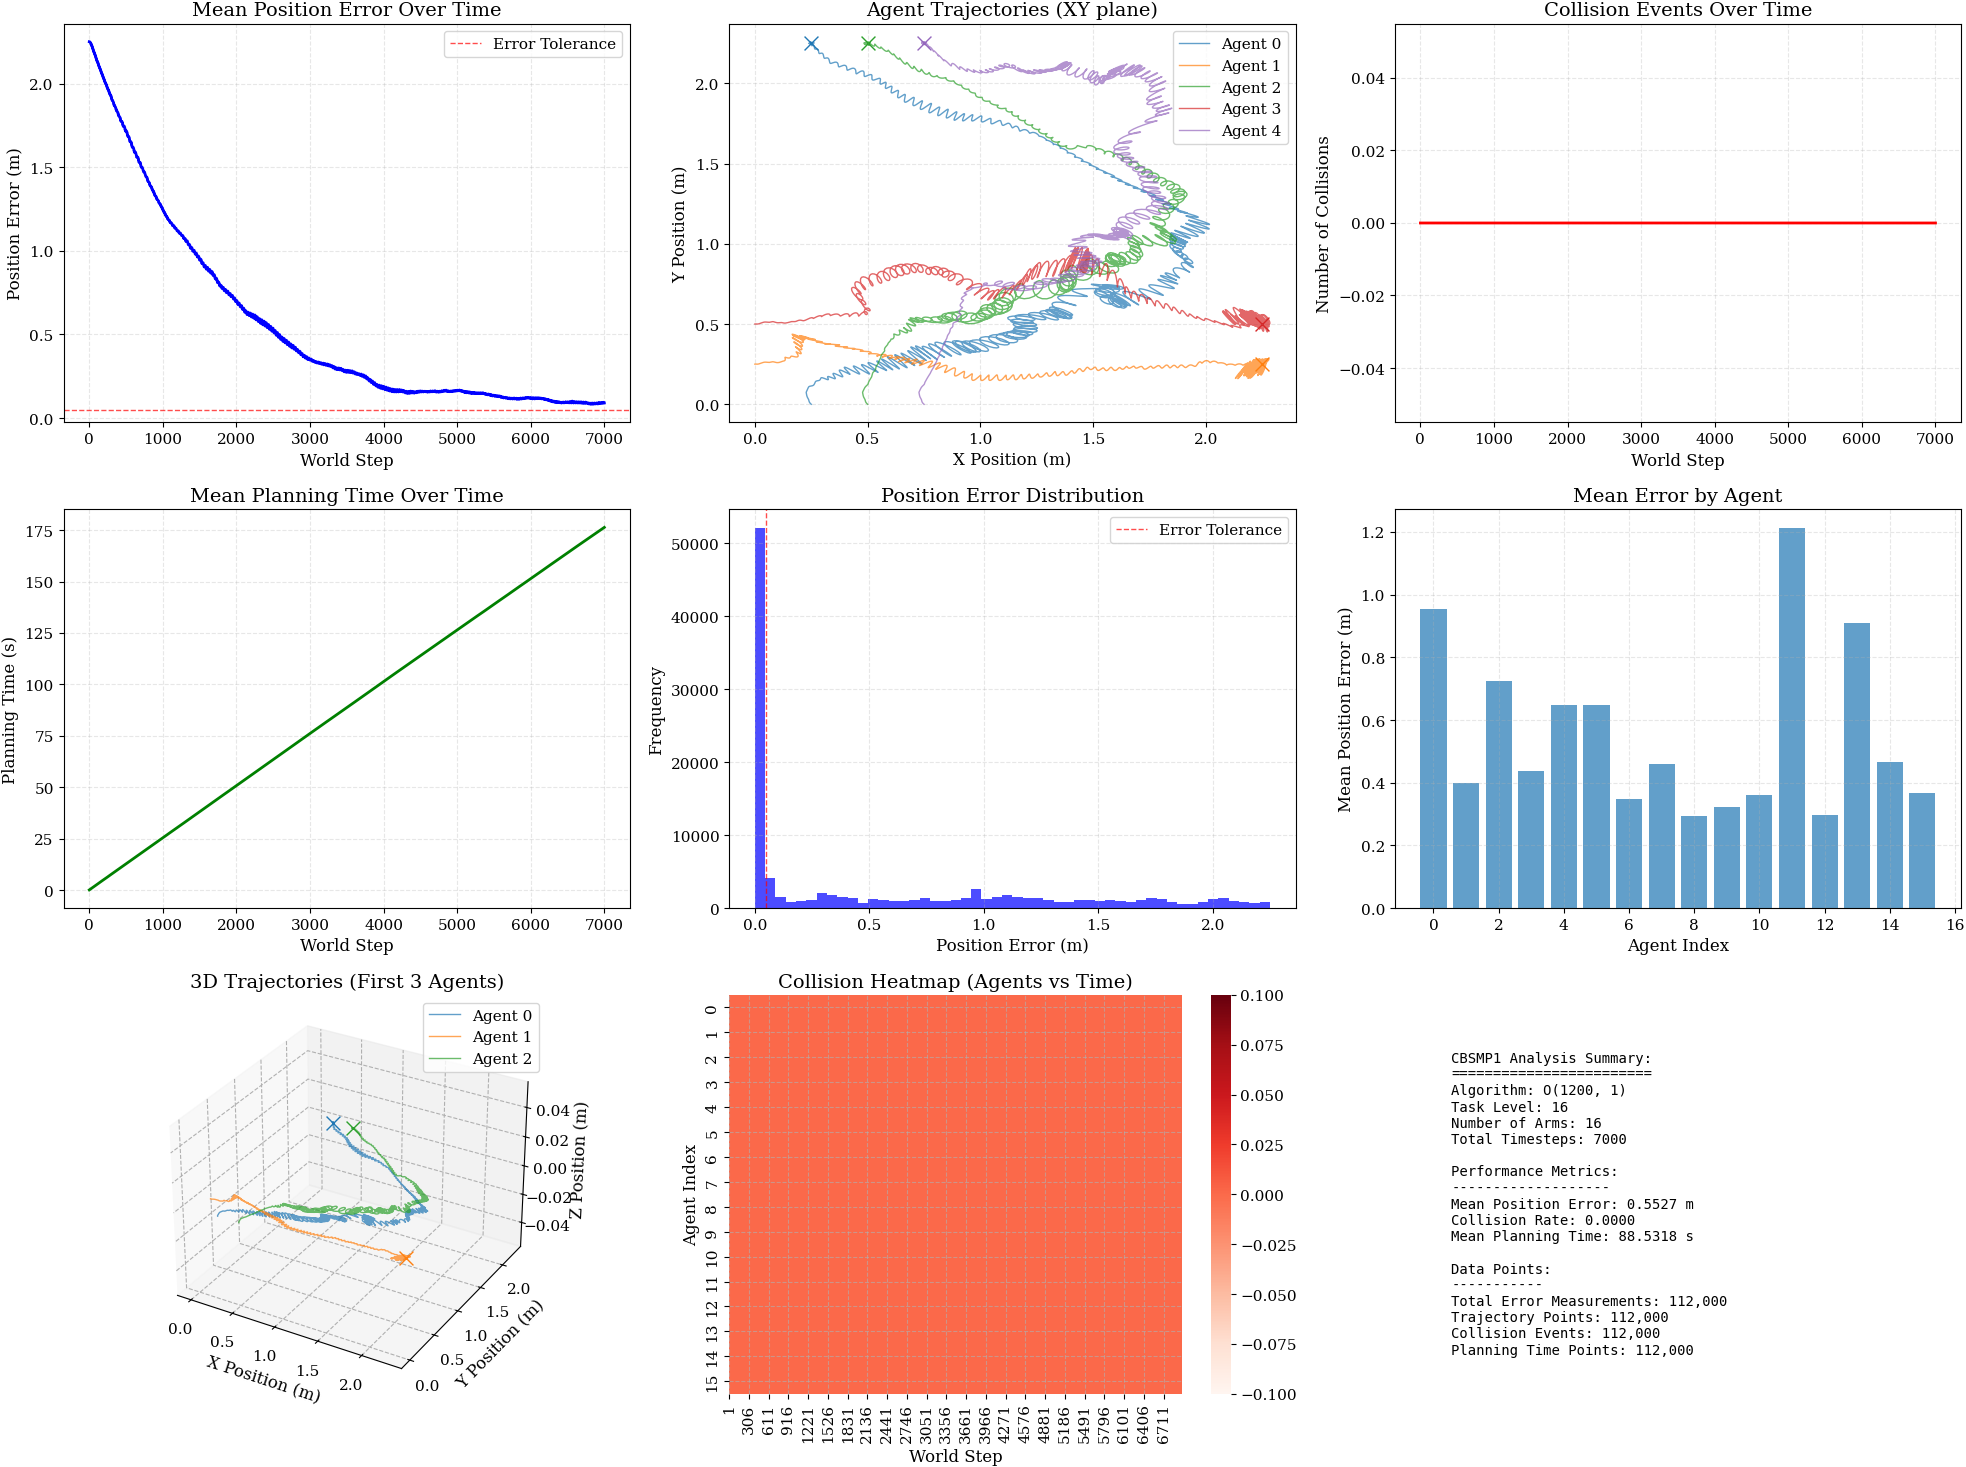


CBSMP1 COMPREHENSIVE ANALYSIS SUMMARY

Simulation: 2025-09-11_16:50:05
Algorithm: O(1200, 1)
Task Level: 16
Number of Arms: 16
Total Timesteps: 7000
Mean Position Error: 0.5527 m
Collision Rate: 0.0000
Mean Planning Time: 88.5318 s
Total Data Points: 112,000


In [54]:
def analyze_cbsmp1_comprehensive(disk_sims, df_collisions, successfull_parsing, sim_paths):
    """
    Comprehensive analysis of CBSMP1 tasks including trajectories, errors, and collisions.
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 1. Extract comprehensive CBSMP1 data
    print("Extracting comprehensive CBSMP1 data...")
    cbsmp1_data = []
    trajectory_data = []
    collision_data = []
    planning_data = []
    
    for sim in disk_sims:
        if sim.meta_data['task_type'] != 'CBSMP1':
            continue
            
        try:
            sim_id = sim.meta_data['timestamp']
            alg = sim.meta_data['alg']
            task_level = sim.meta_data['task_level']
            n_arms = sim.meta_data['n_arms']
            
            print(f"Processing CBSMP1 sim: {sim_id}, alg: {alg}, n_arms: {n_arms}")
            
            # Access raw simulation data
            sim_stats = sim.sim_stats
            
            # Collect data from all agents
            all_position_errors = []
            all_ee_positions = []
            all_target_positions = []
            all_collisions = []
            all_planning_times = []
            w_steps = []
            
            # Process each agent
            for agent_idx in range(n_arms):
                agent_key = f'agent_{agent_idx}'
                if agent_key not in sim_stats:
                    continue
                
                agent_data = sim_stats[agent_key]
                
                # Extract link_target_poses data
                if 'link_target_poses' in agent_data:
                    poses_data = agent_data['link_target_poses']
                    
                    agent_ee_positions = []
                    agent_target_positions = []
                    agent_errors = []
                    agent_w_steps = []
                    
                    for entry in poses_data:
                        if len(entry) >= 2:
                            keys, values = entry
                            w_step = keys['w_step']
                            agent_w_steps.append(w_step)
                            
                            if len(values) >= 3:
                                ee_poses, ee_links, target_poses = values
                                
                                try:
                                    # Get end-effector position
                                    if 'ee_link' in ee_poses:
                                        ee_pos = np.array(ee_poses['ee_link'][0])  # position part
                                        agent_ee_positions.append(ee_pos)
                                        
                                        # Get target position for this agent
                                        target_key = f'target_{agent_idx}_ee_link'
                                        if target_key in target_poses:
                                            target_pos = np.array(target_poses[target_key][0])  # position part
                                            agent_target_positions.append(target_pos)
                                            
                                            # Calculate position error
                                            pos_error = np.linalg.norm(ee_pos - target_pos)
                                            agent_errors.append(pos_error)
                                        else:
                                            agent_target_positions.append(np.array([0, 0, 0]))
                                            agent_errors.append(0)
                                    else:
                                        agent_ee_positions.append(np.array([0, 0, 0]))
                                        agent_target_positions.append(np.array([0, 0, 0]))
                                        agent_errors.append(0)
                                except Exception as e:
                                    agent_ee_positions.append(np.array([0, 0, 0]))
                                    agent_target_positions.append(np.array([0, 0, 0]))
                                    agent_errors.append(0)
                    
                    all_ee_positions.append(agent_ee_positions)
                    all_target_positions.append(agent_target_positions)
                    all_position_errors.append(agent_errors)
                    if not w_steps:  # Store w_steps only once
                        w_steps = agent_w_steps
                
                # Extract collision data
                if 'arm_cols' in agent_data:
                    arm_cols_data = agent_data['arm_cols']
                    
                    agent_collisions = []
                    for entry in arm_cols_data:
                        if len(entry) >= 2:
                            keys, values = entry
                            w_step = keys['w_step']
                            collision_bool = values
                            agent_collisions.append(collision_bool)
                    
                    all_collisions.append(agent_collisions)
                
                # Extract planning time data
                if 'total_planning_time' in agent_data:
                    planning_data_agent = agent_data['total_planning_time']
                    
                    agent_planning_times = []
                    for entry in planning_data_agent:
                        if len(entry) >= 2:
                            keys, values = entry
                            w_step = keys['w_step']
                            planning_time = values
                            agent_planning_times.append(planning_time)
                    
                    all_planning_times.append(agent_planning_times)
            
            # Calculate summary statistics
            all_errors_flat = [error for agent_errors in all_position_errors for error in agent_errors]
            mean_error = np.mean(all_errors_flat)
            
            # Calculate collision statistics
            total_collisions = sum([sum(agent_collisions) for agent_collisions in all_collisions])
            collision_rate = total_collisions / (len(all_collisions) * len(w_steps)) if all_collisions else 0
            
            # Calculate planning time statistics
            all_planning_times_flat = [time for agent_times in all_planning_times for time in agent_times]
            mean_planning_time = np.mean(all_planning_times_flat) if all_planning_times_flat else 0
            
            # Store summary data
            cbsmp1_data.append({
                'sim_id': sim_id,
                'alg': alg,
                'task_level': task_level,
                'n_arms': n_arms,
                'p_err_mean': mean_error,
                'collision_rate': collision_rate,
                'mean_planning_time': mean_planning_time,
                'n_data_points': len(all_errors_flat),
                'n_timesteps': len(w_steps)
            })
            
            # Store trajectory data for plotting
            for agent_idx in range(n_arms):
                if agent_idx < len(all_ee_positions) and agent_idx < len(all_target_positions):
                    for t, (ee_pos, target_pos, error) in enumerate(zip(
                        all_ee_positions[agent_idx], 
                        all_target_positions[agent_idx], 
                        all_position_errors[agent_idx]
                    )):
                        trajectory_data.append({
                            'sim_id': sim_id,
                            'agent_idx': agent_idx,
                            'w_step': w_steps[t] if t < len(w_steps) else t,
                            'ee_x': ee_pos[0],
                            'ee_y': ee_pos[1], 
                            'ee_z': ee_pos[2],
                            'target_x': target_pos[0],
                            'target_y': target_pos[1],
                            'target_z': target_pos[2],
                            'position_error': error
                        })
            
            # Store collision data for plotting
            for agent_idx in range(n_arms):
                if agent_idx < len(all_collisions):
                    for t, collision in enumerate(all_collisions[agent_idx]):
                        collision_data.append({
                            'sim_id': sim_id,
                            'agent_idx': agent_idx,
                            'w_step': w_steps[t] if t < len(w_steps) else t,
                            'collision': collision
                        })
            
            # Store planning time data for plotting
            for agent_idx in range(n_arms):
                if agent_idx < len(all_planning_times):
                    for t, planning_time in enumerate(all_planning_times[agent_idx]):
                        planning_data.append({
                            'sim_id': sim_id,
                            'agent_idx': agent_idx,
                            'w_step': w_steps[t] if t < len(w_steps) else t,
                            'planning_time': planning_time
                        })
            
            print(f"  Calculated {len(all_errors_flat)} total position error data points")
            print(f"  Mean error: {mean_error:.4f}")
            print(f"  Collision rate: {collision_rate:.4f}")
            print(f"  Mean planning time: {mean_planning_time:.4f}")
            
        except Exception as e:
            print(f'Error processing CBSMP1 sim {sim_id}: {e}')
            import traceback
            traceback.print_exc()
            continue
    
    # 2. Create DataFrames
    df_cbsmp1 = pd.DataFrame(cbsmp1_data)
    df_trajectory = pd.DataFrame(trajectory_data)
    df_collision = pd.DataFrame(collision_data)
    df_planning = pd.DataFrame(planning_data)
    
    if df_cbsmp1.empty:
        print("No CBSMP1 data found!")
        return None, None, None, None, None
    
    print(f"Processed {len(df_cbsmp1)} CBSMP1 simulations")
    print(f"Trajectory data points: {len(df_trajectory)}")
    print(f"Collision data points: {len(df_collision)}")
    print(f"Planning data points: {len(df_planning)}")
    
    # 3. Create comprehensive plots
    print("Creating comprehensive CBSMP1 analysis plots...")
    
    # Create a large figure with multiple subplots
    fig = plt.figure(figsize=(20, 15))
    
    # Plot 1: Position errors over time (mean across all agents)
    ax1 = plt.subplot(3, 3, 1)
    if not df_trajectory.empty:
        error_over_time = df_trajectory.groupby('w_step')['position_error'].mean()
        ax1.plot(error_over_time.index, error_over_time.values, 'b-', linewidth=2)
        ax1.set_title('Mean Position Error Over Time')
        ax1.set_xlabel('World Step')
        ax1.set_ylabel('Position Error (m)')
        ax1.grid(True, alpha=0.3)
        ax1.axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='Error Tolerance')
        ax1.legend()
    
    # Plot 2: Individual agent trajectories (first 5 agents)
    ax2 = plt.subplot(3, 3, 2)
    if not df_trajectory.empty:
        for agent_idx in range(min(5, df_trajectory['agent_idx'].max() + 1)):
            agent_data = df_trajectory[df_trajectory['agent_idx'] == agent_idx]
            if not agent_data.empty:
                ax2.plot(agent_data['ee_x'], agent_data['ee_y'], 
                        label=f'Agent {agent_idx}', alpha=0.7, linewidth=1)
                # Plot target position
                ax2.scatter(agent_data['target_x'].iloc[0], agent_data['target_y'].iloc[0], 
                           marker='x', s=100, color=f'C{agent_idx}')
        ax2.set_title('Agent Trajectories (XY plane)')
        ax2.set_xlabel('X Position (m)')
        ax2.set_ylabel('Y Position (m)')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
    
    # Plot 3: Collision events over time
    ax3 = plt.subplot(3, 3, 3)
    if not df_collision.empty:
        collision_over_time = df_collision.groupby('w_step')['collision'].sum()
        ax3.plot(collision_over_time.index, collision_over_time.values, 'r-', linewidth=2)
        ax3.set_title('Collision Events Over Time')
        ax3.set_xlabel('World Step')
        ax3.set_ylabel('Number of Collisions')
        ax3.grid(True, alpha=0.3)
    
    # Plot 4: Planning time over time (mean across all agents)
    ax4 = plt.subplot(3, 3, 4)
    if not df_planning.empty:
        planning_over_time = df_planning.groupby('w_step')['planning_time'].mean()
        ax4.plot(planning_over_time.index, planning_over_time.values, 'g-', linewidth=2)
        ax4.set_title('Mean Planning Time Over Time')
        ax4.set_xlabel('World Step')
        ax4.set_ylabel('Planning Time (s)')
        ax4.grid(True, alpha=0.3)
    
    # Plot 5: Position error distribution
    ax5 = plt.subplot(3, 3, 5)
    if not df_trajectory.empty:
        ax5.hist(df_trajectory['position_error'], bins=50, alpha=0.7, color='blue')
        ax5.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, label='Error Tolerance')
        ax5.set_title('Position Error Distribution')
        ax5.set_xlabel('Position Error (m)')
        ax5.set_ylabel('Frequency')
        ax5.legend()
        ax5.grid(True, alpha=0.3)
    
    # Plot 6: Agent-wise error comparison
    ax6 = plt.subplot(3, 3, 6)
    if not df_trajectory.empty:
        agent_errors = df_trajectory.groupby('agent_idx')['position_error'].mean()
        ax6.bar(range(len(agent_errors)), agent_errors.values, alpha=0.7)
        ax6.set_title('Mean Error by Agent')
        ax6.set_xlabel('Agent Index')
        ax6.set_ylabel('Mean Position Error (m)')
        ax6.grid(True, alpha=0.3)
    
    # Plot 7: 3D trajectory plot (first 3 agents)
    ax7 = plt.subplot(3, 3, 7, projection='3d')
    if not df_trajectory.empty:
        for agent_idx in range(min(3, df_trajectory['agent_idx'].max() + 1)):
            agent_data = df_trajectory[df_trajectory['agent_idx'] == agent_idx]
            if not agent_data.empty:
                ax7.plot(agent_data['ee_x'], agent_data['ee_y'], agent_data['ee_z'], 
                        label=f'Agent {agent_idx}', alpha=0.7)
                # Plot target position
                ax7.scatter(agent_data['target_x'].iloc[0], agent_data['target_y'].iloc[0], 
                           agent_data['target_z'].iloc[0], marker='x', s=100, color=f'C{agent_idx}')
        ax7.set_title('3D Trajectories (First 3 Agents)')
        ax7.set_xlabel('X Position (m)')
        ax7.set_ylabel('Y Position (m)')
        ax7.set_zlabel('Z Position (m)')
        ax7.legend()
    
    # Plot 8: Collision heatmap (agents vs time)
    ax8 = plt.subplot(3, 3, 8)
    if not df_collision.empty:
        collision_pivot = df_collision.pivot_table(
            index='agent_idx', columns='w_step', values='collision', fill_value=False
        )
        sns.heatmap(collision_pivot, cmap='Reds', cbar=True, ax=ax8)
        ax8.set_title('Collision Heatmap (Agents vs Time)')
        ax8.set_xlabel('World Step')
        ax8.set_ylabel('Agent Index')
    
    # Plot 9: Summary statistics
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('off')
    if not df_cbsmp1.empty:
        summary_text = f"""
CBSMP1 Analysis Summary:
========================
Algorithm: {df_cbsmp1['alg'].iloc[0]}
Task Level: {df_cbsmp1['task_level'].iloc[0]}
Number of Arms: {df_cbsmp1['n_arms'].iloc[0]}
Total Timesteps: {df_cbsmp1['n_timesteps'].iloc[0]}

Performance Metrics:
-------------------
Mean Position Error: {df_cbsmp1['p_err_mean'].iloc[0]:.4f} m
Collision Rate: {df_cbsmp1['collision_rate'].iloc[0]:.4f}
Mean Planning Time: {df_cbsmp1['mean_planning_time'].iloc[0]:.4f} s

Data Points:
-----------
Total Error Measurements: {df_cbsmp1['n_data_points'].iloc[0]:,}
Trajectory Points: {len(df_trajectory):,}
Collision Events: {len(df_collision):,}
Planning Time Points: {len(df_planning):,}
        """
        ax9.text(0.1, 0.9, summary_text, transform=ax9.transAxes, 
                fontsize=10, verticalalignment='top', fontfamily='monospace')
    
    plt.tight_layout()
    plt.show()
    
    # 4. Print detailed summary
    print("\n" + "="*60)
    print("CBSMP1 COMPREHENSIVE ANALYSIS SUMMARY")
    print("="*60)
    
    for _, row in df_cbsmp1.iterrows():
        print(f"\nSimulation: {row['sim_id']}")
        print(f"Algorithm: {row['alg']}")
        print(f"Task Level: {row['task_level']}")
        print(f"Number of Arms: {row['n_arms']}")
        print(f"Total Timesteps: {row['n_timesteps']}")
        print(f"Mean Position Error: {row['p_err_mean']:.4f} m")
        print(f"Collision Rate: {row['collision_rate']:.4f}")
        print(f"Mean Planning Time: {row['mean_planning_time']:.4f} s")
        print(f"Total Data Points: {row['n_data_points']:,}")
    
    return df_cbsmp1, df_trajectory, df_collision, df_planning, overall_df

# Usage:
df_cbsmp1, df_trajectory, df_collision, df_planning, overall_df = analyze_cbsmp1_comprehensive(disk_sims, df_collisions, successfull_parsing, valid_sim_dir_paths)

Extracting comprehensive CBSMP1 data...
Processing CBSMP1 sim: 2025-09-11_16:50:05, alg: O(1200, 1), n_arms: 16


  Calculated 112000 total position error data points
  Mean error: 0.5527
  Collision rate: 0.0000
  Mean planning time: 88.5318
Processed 1 CBSMP1 simulations
Trajectory data points: 112000
Collision data points: 112000
Planning data points: 112000
Creating improved CBSMP1 analysis plots...


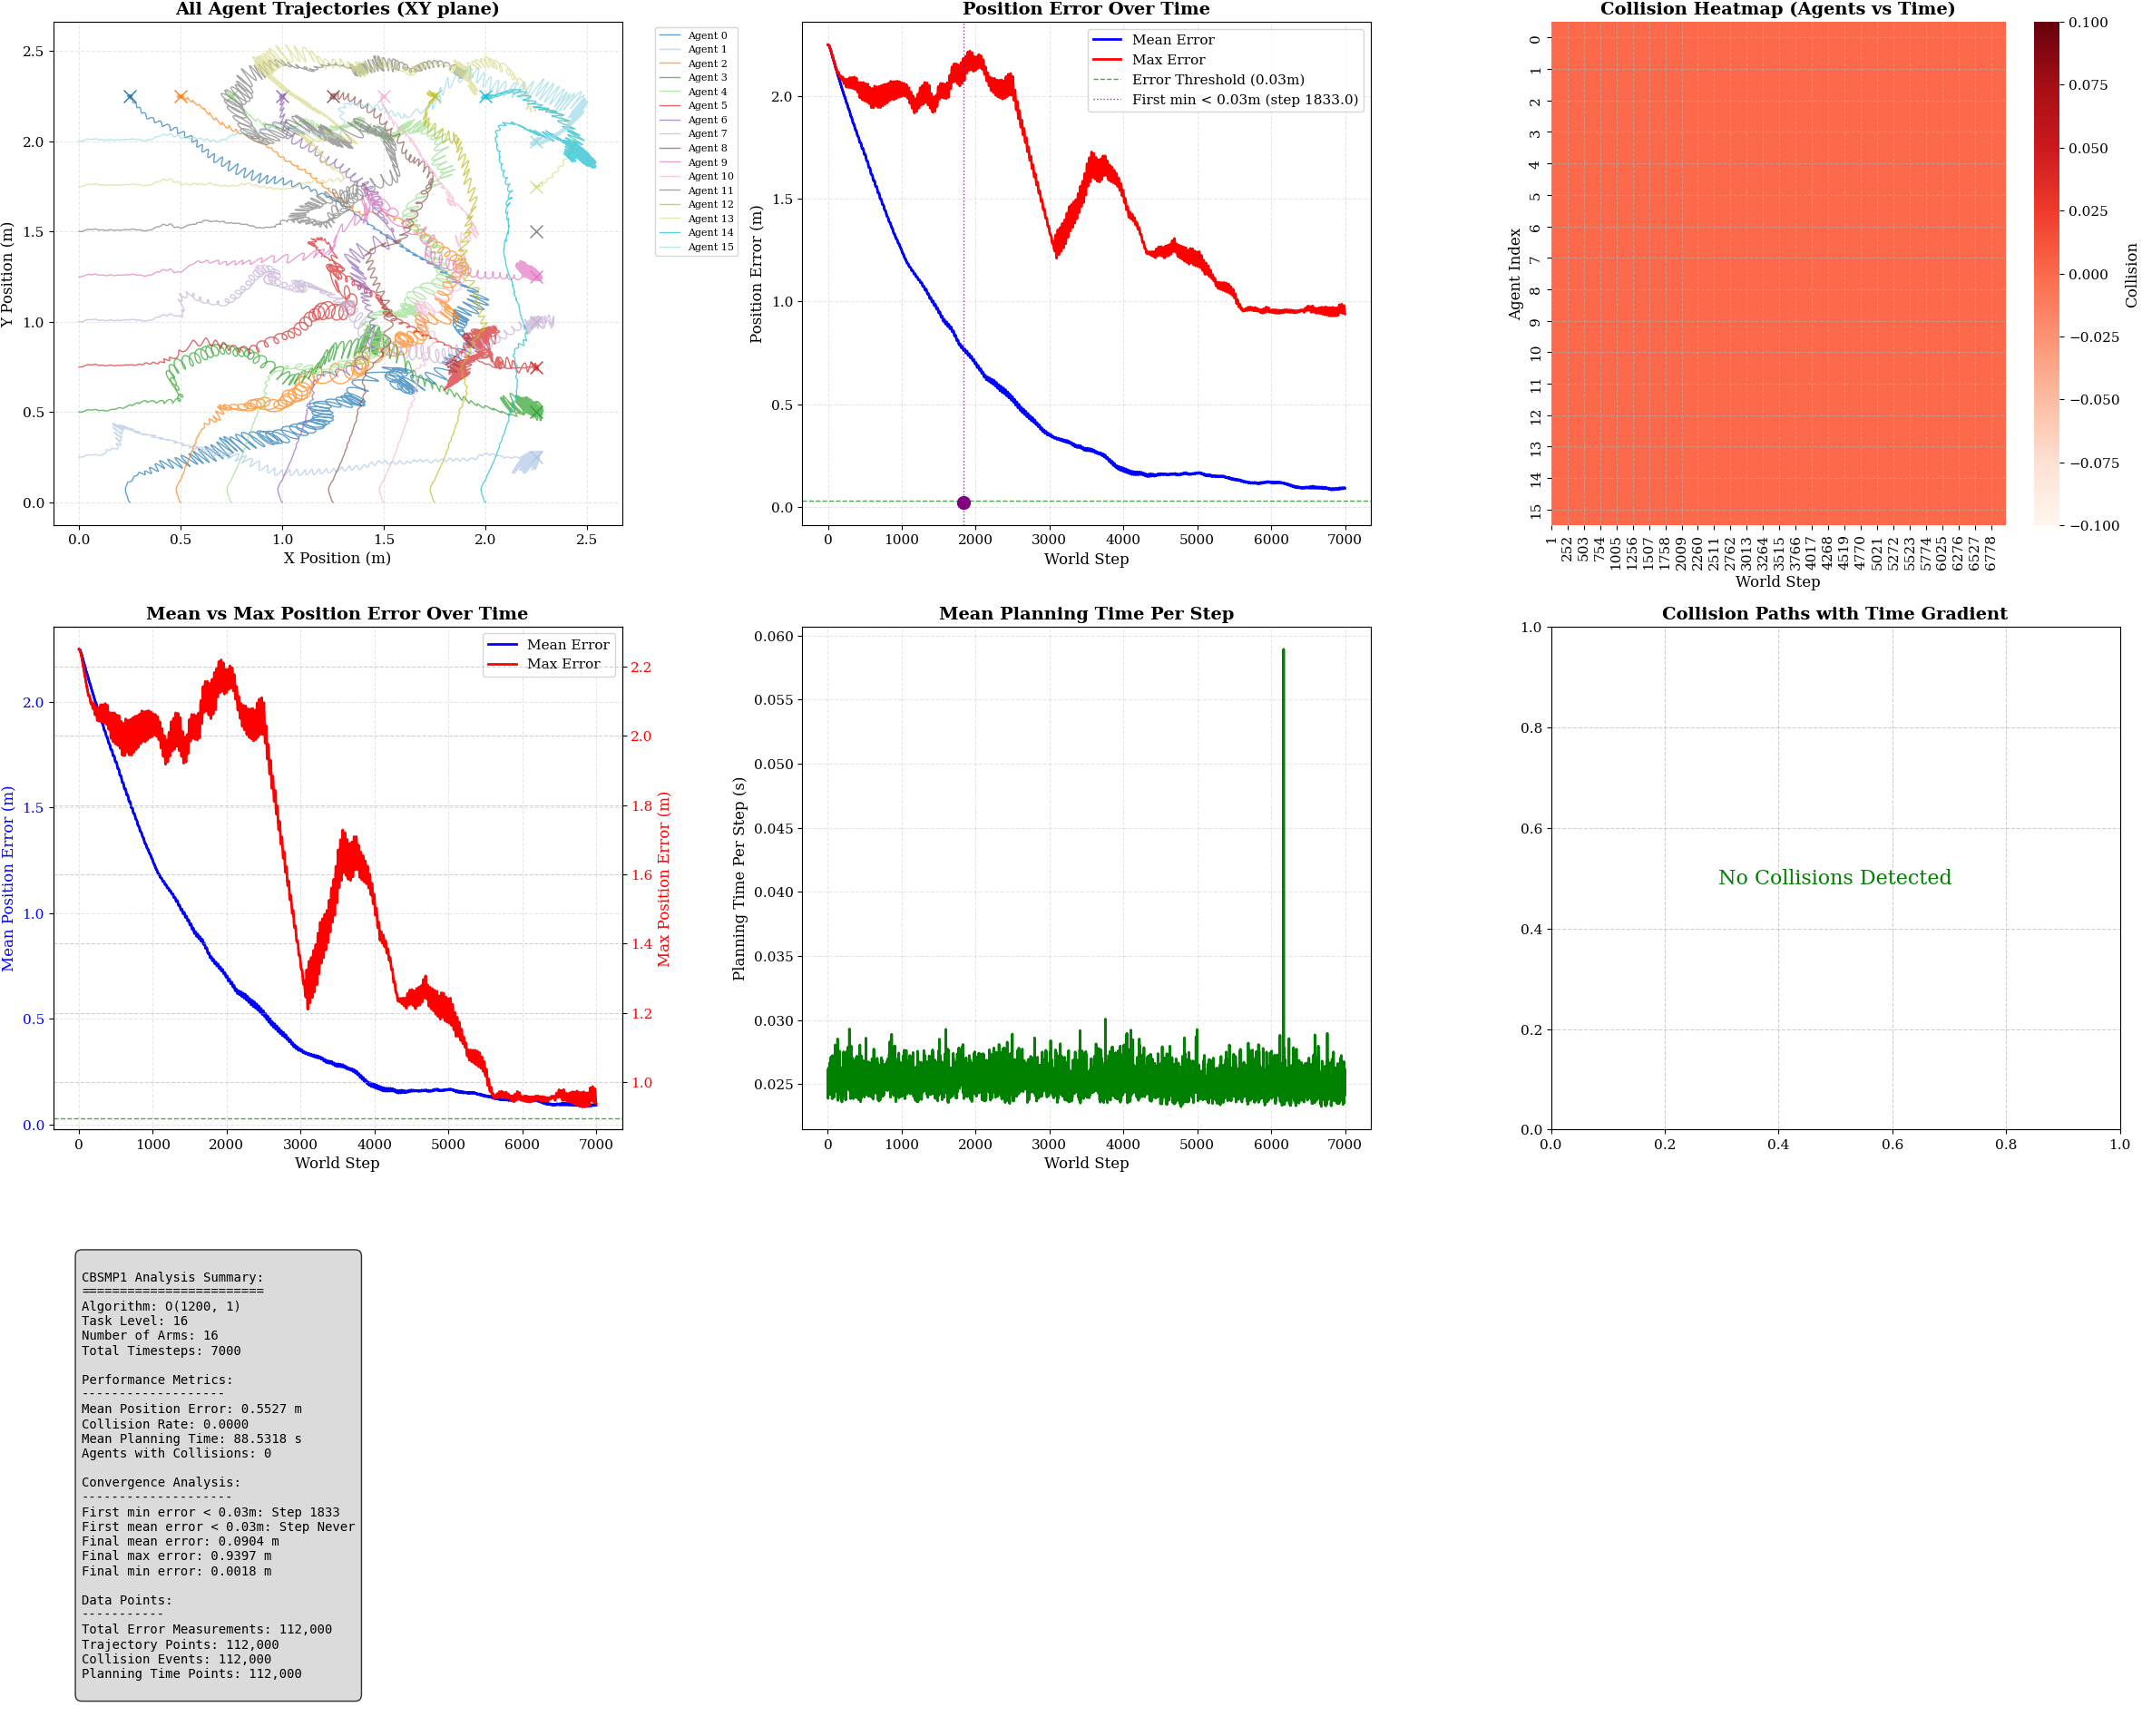


CBSMP1 COMPREHENSIVE ANALYSIS SUMMARY

Simulation: 2025-09-11_16:50:05
Algorithm: O(1200, 1)
Task Level: 16
Number of Arms: 16
Total Timesteps: 7000
Mean Position Error: 0.5527 m
Collision Rate: 0.0000
Mean Planning Time: 88.5318 s
Total Data Points: 112,000


In [55]:
def analyze_cbsmp1_improved_grid_with_collision_paths(disk_sims, df_collisions, successfull_parsing, sim_paths):
    """
    Improved CBSMP1 analysis with collision-specific path visualization.
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 1. Extract comprehensive CBSMP1 data
    print("Extracting comprehensive CBSMP1 data...")
    cbsmp1_data = []
    trajectory_data = []
    collision_data = []
    planning_data = []
    
    for sim in disk_sims:
        if sim.meta_data['task_type'] != 'CBSMP1':
            continue
            
        try:
            sim_id = sim.meta_data['timestamp']
            alg = sim.meta_data['alg']
            task_level = sim.meta_data['task_level']
            n_arms = sim.meta_data['n_arms']
            
            print(f"Processing CBSMP1 sim: {sim_id}, alg: {alg}, n_arms: {n_arms}")
            
            # Access raw simulation data
            sim_stats = sim.sim_stats
            
            # Collect data from all agents
            all_position_errors = []
            all_ee_positions = []
            all_target_positions = []
            all_collisions = []
            all_planning_times = []
            w_steps = []
            
            # Process each agent
            for agent_idx in range(n_arms):
                agent_key = f'agent_{agent_idx}'
                if agent_key not in sim_stats:
                    continue
                
                agent_data = sim_stats[agent_key]
                
                # Extract link_target_poses data
                if 'link_target_poses' in agent_data:
                    poses_data = agent_data['link_target_poses']
                    
                    agent_ee_positions = []
                    agent_target_positions = []
                    agent_errors = []
                    agent_w_steps = []
                    
                    for entry in poses_data:
                        if len(entry) >= 2:
                            keys, values = entry
                            w_step = keys['w_step']
                            agent_w_steps.append(w_step)
                            
                            if len(values) >= 3:
                                ee_poses, ee_links, target_poses = values
                                
                                try:
                                    # Get end-effector position
                                    if 'ee_link' in ee_poses:
                                        ee_pos = np.array(ee_poses['ee_link'][0])  # position part
                                        agent_ee_positions.append(ee_pos)
                                        
                                        # Get target position for this agent
                                        target_key = f'target_{agent_idx}_ee_link'
                                        if target_key in target_poses:
                                            target_pos = np.array(target_poses[target_key][0])  # position part
                                            agent_target_positions.append(target_pos)
                                            
                                            # Calculate position error
                                            pos_error = np.linalg.norm(ee_pos - target_pos)
                                            agent_errors.append(pos_error)
                                        else:
                                            agent_target_positions.append(np.array([0, 0, 0]))
                                            agent_errors.append(0)
                                    else:
                                        agent_ee_positions.append(np.array([0, 0, 0]))
                                        agent_target_positions.append(np.array([0, 0, 0]))
                                        agent_errors.append(0)
                                except Exception as e:
                                    agent_ee_positions.append(np.array([0, 0, 0]))
                                    agent_target_positions.append(np.array([0, 0, 0]))
                                    agent_errors.append(0)
                    
                    all_ee_positions.append(agent_ee_positions)
                    all_target_positions.append(agent_target_positions)
                    all_position_errors.append(agent_errors)
                    if not w_steps:  # Store w_steps only once
                        w_steps = agent_w_steps
                
                # Extract collision data
                if 'arm_cols' in agent_data:
                    arm_cols_data = agent_data['arm_cols']
                    
                    agent_collisions = []
                    for entry in arm_cols_data:
                        if len(entry) >= 2:
                            keys, values = entry
                            w_step = keys['w_step']
                            collision_bool = values
                            agent_collisions.append(collision_bool)
                    
                    all_collisions.append(agent_collisions)
                
                # Extract planning time data
                if 'total_planning_time' in agent_data:
                    planning_data_agent = agent_data['total_planning_time']
                    
                    agent_planning_times = []
                    for entry in planning_data_agent:
                        if len(entry) >= 2:
                            keys, values = entry
                            w_step = keys['w_step']
                            planning_time = values
                            agent_planning_times.append(planning_time)
                    
                    all_planning_times.append(agent_planning_times)
            
            # Calculate summary statistics
            all_errors_flat = [error for agent_errors in all_position_errors for error in agent_errors]
            mean_error = np.mean(all_errors_flat)
            
            # Calculate collision statistics
            total_collisions = sum([sum(agent_collisions) for agent_collisions in all_collisions])
            collision_rate = total_collisions / (len(all_collisions) * len(w_steps)) if all_collisions else 0
            
            # Calculate planning time statistics
            all_planning_times_flat = [time for agent_times in all_planning_times for time in agent_times]
            mean_planning_time = np.mean(all_planning_times_flat) if all_planning_times_flat else 0
            
            # Store summary data
            cbsmp1_data.append({
                'sim_id': sim_id,
                'alg': alg,
                'task_level': task_level,
                'n_arms': n_arms,
                'p_err_mean': mean_error,
                'collision_rate': collision_rate,
                'mean_planning_time': mean_planning_time,
                'n_data_points': len(all_errors_flat),
                'n_timesteps': len(w_steps)
            })
             
            # Store trajectory data for plotting
            for agent_idx in range(n_arms):
                if agent_idx < len(all_ee_positions) and agent_idx < len(all_target_positions):
                    for t, (ee_pos, target_pos, error) in enumerate(zip(
                        all_ee_positions[agent_idx], 
                        all_target_positions[agent_idx], 
                        all_position_errors[agent_idx]
                    )):
                        trajectory_data.append({
                            'sim_id': sim_id,
                            'agent_idx': agent_idx,
                            'w_step': w_steps[t] if t < len(w_steps) else t,
                            'ee_x': ee_pos[0],
                            'ee_y': ee_pos[1], 
                            'ee_z': ee_pos[2],
                            'target_x': target_pos[0],
                            'target_y': target_pos[1],
                            'target_z': target_pos[2],
                            'position_error': error
                        })
            
            # Store collision data for plotting
            for agent_idx in range(n_arms):
                if agent_idx < len(all_collisions):
                    for t, collision in enumerate(all_collisions[agent_idx]):
                        collision_data.append({
                            'sim_id': sim_id,
                            'agent_idx': agent_idx,
                            'w_step': w_steps[t] if t < len(w_steps) else t,
                            'collision': collision
                        })
            
            # Store planning time data for plotting
            for agent_idx in range(n_arms):
                if agent_idx < len(all_planning_times):
                    for t, planning_time in enumerate(all_planning_times[agent_idx]):
                        planning_data.append({
                            'sim_id': sim_id,
                            'agent_idx': agent_idx,
                            'w_step': w_steps[t] if t < len(w_steps) else t,
                            'planning_time': planning_time
                        })
            
            print(f"  Calculated {len(all_errors_flat)} total position error data points")
            print(f"  Mean error: {mean_error:.4f}")
            print(f"  Collision rate: {collision_rate:.4f}")
            print(f"  Mean planning time: {mean_planning_time:.4f}")
            
        except Exception as e:
            print(f'Error processing CBSMP1 sim {sim_id}: {e}')
            import traceback
            traceback.print_exc()
            continue
    
    # 2. Create DataFrames
    df_cbsmp1 = pd.DataFrame(cbsmp1_data)
    df_trajectory = pd.DataFrame(trajectory_data)
    df_collision = pd.DataFrame(collision_data)
    df_planning = pd.DataFrame(planning_data)
    
    if df_cbsmp1.empty:
        print("No CBSMP1 data found!")
        return None, None, None, None, None
    
    print(f"Processed {len(df_cbsmp1)} CBSMP1 simulations")
    print(f"Trajectory data points: {len(df_trajectory)}")
    print(f"Collision data points: {len(df_collision)}")
    print(f"Planning data points: {len(df_planning)}")
    
    # 3. Create improved plots in grid layout
    print("Creating improved CBSMP1 analysis plots...")
    
    # Create a large figure with 7 subplots in 3x3 grid (with one empty)
    fig, axes = plt.subplots(3, 3, figsize=(24, 20))
    
    # Plot 1: All agent trajectories (XY plane) - different colors for each agent
    ax1 = axes[0, 0]
    if not df_trajectory.empty:
        # Get unique agents and assign colors
        unique_agents = sorted(df_trajectory['agent_idx'].unique())
        colors = plt.cm.tab20(np.linspace(0, 1, len(unique_agents)))
        
        for i, agent_idx in enumerate(unique_agents):
            agent_data = df_trajectory[df_trajectory['agent_idx'] == agent_idx]
            if not agent_data.empty:
                ax1.plot(agent_data['ee_x'], agent_data['ee_y'], 
                        color=colors[i], label=f'Agent {agent_idx}', alpha=0.7, linewidth=1)
                # Plot target position
                ax1.scatter(agent_data['target_x'].iloc[0], agent_data['target_y'].iloc[0], 
                           marker='x', s=100, color=colors[i])
        
        ax1.set_title('All Agent Trajectories (XY plane)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('X Position (m)')
        ax1.set_ylabel('Y Position (m)')
        ax1.grid(True, alpha=0.3)
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    # Plot 2: Mean and Max position error over time with threshold markers
    ax2 = axes[0, 1]
    if not df_trajectory.empty:
        # Calculate mean and max errors per timestep
        error_stats = df_trajectory.groupby('w_step')['position_error'].agg(['mean', 'max', 'min']).reset_index()
        
        # Plot mean and max errors
        ax2.plot(error_stats['w_step'], error_stats['mean'], 'b-', linewidth=2, label='Mean Error')
        ax2.plot(error_stats['w_step'], error_stats['max'], 'r-', linewidth=2, label='Max Error')
        
        # Add threshold line
        ax2.axhline(y=0.03, color='green', linestyle='--', alpha=0.7, label='Error Threshold (0.03m)')
        
        # Find first time min error goes below 0.03
        min_error_below_threshold = error_stats[error_stats['min'] < 0.03]
        if not min_error_below_threshold.empty:
            first_min_below = min_error_below_threshold.iloc[0]
            ax2.axvline(x=first_min_below['w_step'], color='purple', linestyle=':', alpha=0.8, 
                       label=f'First min < 0.03m (step {first_min_below["w_step"]})')
            ax2.scatter(first_min_below['w_step'], first_min_below['min'], 
                       color='purple', s=100, marker='o', zorder=5)
        
        # Find first time mean error goes below 0.03
        mean_error_below_threshold = error_stats[error_stats['mean'] < 0.03]
        if not mean_error_below_threshold.empty:
            first_mean_below = mean_error_below_threshold.iloc[0]
            ax2.axvline(x=first_mean_below['w_step'], color='orange', linestyle=':', alpha=0.8,
                       label=f'First mean < 0.03m (step {first_mean_below["w_step"]})')
            ax2.scatter(first_mean_below['w_step'], first_mean_below['mean'], 
                       color='orange', s=100, marker='s', zorder=5)
        
        ax2.set_title('Position Error Over Time', fontsize=14, fontweight='bold')
        ax2.set_xlabel('World Step')
        ax2.set_ylabel('Position Error (m)')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
    
    # Plot 3: Collision heatmap (agents vs time)
    ax3 = axes[0, 2]
    if not df_collision.empty:
        collision_pivot = df_collision.pivot_table(
            index='agent_idx', columns='w_step', values='collision', fill_value=False
        )
        sns.heatmap(collision_pivot, cmap='Reds', cbar=True, ax=ax3, 
                   cbar_kws={'label': 'Collision'})
        ax3.set_title('Collision Heatmap (Agents vs Time)', fontsize=14, fontweight='bold')
        ax3.set_xlabel('World Step')
        ax3.set_ylabel('Agent Index')
    
    # Plot 4: Position max and mean over time (separate y-axes)
    ax4 = axes[1, 0]
    if not df_trajectory.empty:
        error_stats = df_trajectory.groupby('w_step')['position_error'].agg(['mean', 'max']).reset_index()
        
        # Create twin axes
        ax4_twin = ax4.twinx()
        
        # Plot mean error on left axis
        line1 = ax4.plot(error_stats['w_step'], error_stats['mean'], 'b-', linewidth=2, label='Mean Error')
        ax4.set_xlabel('World Step')
        ax4.set_ylabel('Mean Position Error (m)', color='b')
        ax4.tick_params(axis='y', labelcolor='b')
        ax4.grid(True, alpha=0.3)
        
        # Plot max error on right axis
        line2 = ax4_twin.plot(error_stats['w_step'], error_stats['max'], 'r-', linewidth=2, label='Max Error')
        ax4_twin.set_ylabel('Max Position Error (m)', color='r')
        ax4_twin.tick_params(axis='y', labelcolor='r')
        
        # Add threshold lines
        ax4.axhline(y=0.03, color='green', linestyle='--', alpha=0.7, label='Threshold (0.03m)')
        
        # Combine legends
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax4.legend(lines, labels, loc='upper right')
        
        ax4.set_title('Mean vs Max Position Error Over Time', fontsize=14, fontweight='bold')
    
    # Plot 5: Planning time per step (total_planning_time[t] - total_planning_time[t-1])
    ax5 = axes[1, 1]
    if not df_planning.empty:
        # Calculate planning time per step for each agent
        planning_per_step = []
        for agent_idx in df_planning['agent_idx'].unique():
            agent_planning = df_planning[df_planning['agent_idx'] == agent_idx].sort_values('w_step')
            if len(agent_planning) > 1:
                # Calculate difference between consecutive total planning times
                agent_planning['planning_time_per_step'] = agent_planning['planning_time'].diff()
                planning_per_step.append(agent_planning[['w_step', 'planning_time_per_step']].dropna())
        
        if planning_per_step:
            # Combine all agents and calculate mean planning time per step
            all_planning_per_step = pd.concat(planning_per_step, ignore_index=True)
            mean_planning_per_step = all_planning_per_step.groupby('w_step')['planning_time_per_step'].mean()
            
            ax5.plot(mean_planning_per_step.index, mean_planning_per_step.values, 'g-', linewidth=2)
            ax5.set_title('Mean Planning Time Per Step', fontsize=14, fontweight='bold')
            ax5.set_xlabel('World Step')
            ax5.set_ylabel('Planning Time Per Step (s)')
            ax5.grid(True, alpha=0.3)
    
    # Plot 6: NEW - Collision paths with time gradient
    ax6 = axes[1, 2]
    if not df_collision.empty and not df_trajectory.empty:
        # Find agents that had collisions
        agents_with_collisions = df_collision[df_collision['collision'] == True]['agent_idx'].unique()
        
        if len(agents_with_collisions) > 0:
            print(f"Found {len(agents_with_collisions)} agents with collisions: {agents_with_collisions}")
            
            # Plot trajectories for agents with collisions
            for agent_idx in agents_with_collisions:
                agent_trajectory = df_trajectory[df_trajectory['agent_idx'] == agent_idx].sort_values('w_step')
                agent_collisions = df_collision[df_collision['agent_idx'] == agent_idx].sort_values('w_step')
                
                if not agent_trajectory.empty:
                    # Create color gradient based on time (w_step)
                    w_steps = agent_trajectory['w_step'].values
                    colors = plt.cm.viridis(np.linspace(0, 1, len(w_steps)))
                    
                    # Plot trajectory with color gradient
                    for i in range(len(agent_trajectory) - 1):
                        ax6.plot(agent_trajectory.iloc[i:i+2]['ee_x'], 
                                agent_trajectory.iloc[i:i+2]['ee_y'], 
                                color=colors[i], linewidth=2, alpha=0.8)
                    
                    # Mark collision points
                    collision_points = agent_collisions[agent_collisions['collision'] == True]
                    if not collision_points.empty:
                        collision_trajectory = agent_trajectory[agent_trajectory['w_step'].isin(collision_points['w_step'])]
                        ax6.scatter(collision_trajectory['ee_x'], collision_trajectory['ee_y'], 
                                  c='red', s=100, marker='X', zorder=5, 
                                  label=f'Agent {agent_idx} Collisions' if agent_idx == agents_with_collisions[0] else "")
                    
                    # Plot target position
                    ax6.scatter(agent_trajectory['target_x'].iloc[0], agent_trajectory['target_y'].iloc[0], 
                               marker='x', s=150, color='black', linewidth=3, zorder=5)
            
            # Add colorbar for time gradient
            sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=w_steps.min(), vmax=w_steps.max()))
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=ax6)
            cbar.set_label('Time (World Step)', rotation=270, labelpad=20)
            
            ax6.set_title(f'Collision Paths with Time Gradient\n({len(agents_with_collisions)} agents with collisions)', 
                         fontsize=14, fontweight='bold')
            ax6.set_xlabel('X Position (m)')
            ax6.set_ylabel('Y Position (m)')
            ax6.grid(True, alpha=0.3)
            ax6.legend()
        else:
            ax6.text(0.5, 0.5, 'No Collisions Detected', ha='center', va='center', 
                    transform=ax6.transAxes, fontsize=16, color='green')
            ax6.set_title('Collision Paths with Time Gradient', fontsize=14, fontweight='bold')
    
    # Plot 7: Summary statistics and performance metrics
    ax7 = axes[2, 0]
    ax7.axis('off')
    if not df_cbsmp1.empty:
        # Calculate additional metrics
        if not df_trajectory.empty:
            error_stats = df_trajectory.groupby('w_step')['position_error'].agg(['mean', 'max', 'min']).reset_index()
            
            # Find convergence times
            min_error_below_threshold = error_stats[error_stats['min'] < 0.03]
            mean_error_below_threshold = error_stats[error_stats['mean'] < 0.03]
            
            convergence_min = min_error_below_threshold['w_step'].iloc[0] if not min_error_below_threshold.empty else 'Never'
            convergence_mean = mean_error_below_threshold['w_step'].iloc[0] if not mean_error_below_threshold.empty else 'Never'
            
            # Calculate final errors
            final_errors = error_stats.iloc[-1]
            
            # Count agents with collisions
            agents_with_collisions = df_collision[df_collision['collision'] == True]['agent_idx'].nunique() if not df_collision.empty else 0
            
            summary_text = f"""
CBSMP1 Analysis Summary:
========================
Algorithm: {df_cbsmp1['alg'].iloc[0]}
Task Level: {df_cbsmp1['task_level'].iloc[0]}
Number of Arms: {df_cbsmp1['n_arms'].iloc[0]}
Total Timesteps: {df_cbsmp1['n_timesteps'].iloc[0]}

Performance Metrics:
-------------------
Mean Position Error: {df_cbsmp1['p_err_mean'].iloc[0]:.4f} m
Collision Rate: {df_cbsmp1['collision_rate'].iloc[0]:.4f}
Mean Planning Time: {df_cbsmp1['mean_planning_time'].iloc[0]:.4f} s
Agents with Collisions: {agents_with_collisions}

Convergence Analysis:
--------------------
First min error < 0.03m: Step {convergence_min}
First mean error < 0.03m: Step {convergence_mean}
Final mean error: {final_errors['mean']:.4f} m
Final max error: {final_errors['max']:.4f} m
Final min error: {final_errors['min']:.4f} m

Data Points:
-----------
Total Error Measurements: {df_cbsmp1['n_data_points'].iloc[0]:,}
Trajectory Points: {len(df_trajectory):,}
Collision Events: {len(df_collision):,}
Planning Time Points: {len(df_planning):,}
            """
        else:
            summary_text = f"""
CBSMP1 Analysis Summary:
========================
Algorithm: {df_cbsmp1['alg'].iloc[0]}
Task Level: {df_cbsmp1['task_level'].iloc[0]}
Number of Arms: {df_cbsmp1['n_arms'].iloc[0]}
Total Timesteps: {df_cbsmp1['n_timesteps'].iloc[0]}

Performance Metrics:
-------------------
Mean Position Error: {df_cbsmp1['p_err_mean'].iloc[0]:.4f} m
Collision Rate: {df_cbsmp1['collision_rate'].iloc[0]:.4f}
Mean Planning Time: {df_cbsmp1['mean_planning_time'].iloc[0]:.4f} s

Data Points:
-----------
Total Error Measurements: {df_cbsmp1['n_data_points'].iloc[0]:,}
Trajectory Points: {len(df_trajectory):,}
Collision Events: {len(df_collision):,}
Planning Time Points: {len(df_planning):,}
            """
        
        ax7.text(0.05, 0.95, summary_text, transform=ax7.transAxes, 
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
    
    # Hide unused subplots
    axes[2, 1].axis('off')
    axes[2, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 4. Print detailed summary
    print("\n" + "="*60)
    print("CBSMP1 COMPREHENSIVE ANALYSIS SUMMARY")
    print("="*60)
    
    for _, row in df_cbsmp1.iterrows():
        print(f"\nSimulation: {row['sim_id']}")
        print(f"Algorithm: {row['alg']}")
        print(f"Task Level: {row['task_level']}")
        print(f"Number of Arms: {row['n_arms']}")
        print(f"Total Timesteps: {row['n_timesteps']}")
        print(f"Mean Position Error: {row['p_err_mean']:.4f} m")
        print(f"Collision Rate: {row['collision_rate']:.4f}")
        print(f"Mean Planning Time: {row['mean_planning_time']:.4f} s")
        print(f"Total Data Points: {row['n_data_points']:,}")
    
    return df_cbsmp1, df_trajectory, df_collision, df_planning, overall_df

# Usage:
df_cbsmp1, df_trajectory, df_collision, df_planning, overall_df = analyze_cbsmp1_improved_grid_with_collision_paths(disk_sims, df_collisions, successfull_parsing, valid_sim_dir_paths)

In [56]:
def analyze_cbsmp1_improved_grid_with_collision_paths(disk_sims, df_collisions, successfull_parsing, sim_paths):
    """
    Improved CBSMP1 analysis with collision-specific path visualization.
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 1. Extract comprehensive CBSMP1 data
    print("Extracting comprehensive CBSMP1 data...")
    cbsmp1_data = []
    trajectory_data = []
    collision_data = []
    planning_data = []
    
    for sim in disk_sims:
        if sim.meta_data['task_type'] != 'CBSMP1':
            continue
            
        try:
            sim_id = sim.meta_data['timestamp']
            alg = sim.meta_data['alg']
            task_level = sim.meta_data['task_level']
            n_arms = sim.meta_data['n_arms']
            
            print(f"Processing CBSMP1 sim: {sim_id}, alg: {alg}, n_arms: {n_arms}")
            
            # Access raw simulation data
            sim_stats = sim.sim_stats
            
            # Collect data from all agents
            all_position_errors = []
            all_ee_positions = []
            all_target_positions = []
            all_collisions = []
            all_planning_times = []
            w_steps = []
            
            # Process each agent
            for agent_idx in range(n_arms):
                agent_key = f'agent_{agent_idx}'
                if agent_key not in sim_stats:
                    continue
                
                agent_data = sim_stats[agent_key]
                
                # Extract link_target_poses data
                if 'link_target_poses' in agent_data:
                    poses_data = agent_data['link_target_poses']
                    
                    agent_ee_positions = []
                    agent_target_positions = []
                    agent_errors = []
                    agent_w_steps = []
                    
                    for entry in poses_data:
                        if len(entry) >= 2:
                            keys, values = entry
                            w_step = keys['w_step']
                            agent_w_steps.append(w_step)
                            
                            if len(values) >= 3:
                                ee_poses, ee_links, target_poses = values
                                
                                try:
                                    # Get end-effector position
                                    if 'ee_link' in ee_poses:
                                        ee_pos = np.array(ee_poses['ee_link'][0])  # position part
                                        agent_ee_positions.append(ee_pos)
                                        
                                        # Get target position for this agent
                                        target_key = f'target_{agent_idx}_ee_link'
                                        if target_key in target_poses:
                                            target_pos = np.array(target_poses[target_key][0])  # position part
                                            agent_target_positions.append(target_pos)
                                            
                                            # Calculate position error
                                            pos_error = np.linalg.norm(ee_pos - target_pos)
                                            agent_errors.append(pos_error)
                                        else:
                                            agent_target_positions.append(np.array([0, 0, 0]))
                                            agent_errors.append(0)
                                    else:
                                        agent_ee_positions.append(np.array([0, 0, 0]))
                                        agent_target_positions.append(np.array([0, 0, 0]))
                                        agent_errors.append(0)
                                except Exception as e:
                                    agent_ee_positions.append(np.array([0, 0, 0]))
                                    agent_target_positions.append(np.array([0, 0, 0]))
                                    agent_errors.append(0)
                    
                    all_ee_positions.append(agent_ee_positions)
                    all_target_positions.append(agent_target_positions)
                    all_position_errors.append(agent_errors)
                    if not w_steps:  # Store w_steps only once
                        w_steps = agent_w_steps
                
                # Extract collision data
                if 'arm_cols' in agent_data:
                    arm_cols_data = agent_data['arm_cols']
                    
                    agent_collisions = []
                    for entry in arm_cols_data:
                        if len(entry) >= 2:
                            keys, values = entry
                            w_step = keys['w_step']
                            collision_bool = values
                            agent_collisions.append(collision_bool)
                    
                    all_collisions.append(agent_collisions)
                
                # Extract planning time data
                if 'total_planning_time' in agent_data:
                    planning_data_agent = agent_data['total_planning_time']
                    
                    agent_planning_times = []
                    for entry in planning_data_agent:
                        if len(entry) >= 2:
                            keys, values = entry
                            w_step = keys['w_step']
                            planning_time = values
                            agent_planning_times.append(planning_time)
                    
                    all_planning_times.append(agent_planning_times)
            
            # Calculate summary statistics
            all_errors_flat = [error for agent_errors in all_position_errors for error in agent_errors]
            mean_error = np.mean(all_errors_flat)
            
            # Calculate collision statistics
            total_collisions = sum([sum(agent_collisions) for agent_collisions in all_collisions])
            collision_rate = total_collisions / (len(all_collisions) * len(w_steps)) if all_collisions else 0
            
            # Calculate planning time statistics
            all_planning_times_flat = [time for agent_times in all_planning_times for time in agent_times]
            mean_planning_time = np.mean(all_planning_times_flat) if all_planning_times_flat else 0
            
            # Store summary data
            cbsmp1_data.append({
                'sim_id': sim_id,
                'alg': alg,
                'task_level': task_level,
                'n_arms': n_arms,
                'p_err_mean': mean_error,
                'collision_rate': collision_rate,
                'mean_planning_time': mean_planning_time,
                'n_data_points': len(all_errors_flat),
                'n_timesteps': len(w_steps)
            })
            
            # Store trajectory data for plotting
            for agent_idx in range(n_arms):
                if agent_idx < len(all_ee_positions) and agent_idx < len(all_target_positions):
                    for t, (ee_pos, target_pos, error) in enumerate(zip(
                        all_ee_positions[agent_idx], 
                        all_target_positions[agent_idx], 
                        all_position_errors[agent_idx]
                    )):
                        trajectory_data.append({
                            'sim_id': sim_id,
                            'agent_idx': agent_idx,
                            'w_step': w_steps[t] if t < len(w_steps) else t,
                            'ee_x': ee_pos[0],
                            'ee_y': ee_pos[1], 
                            'ee_z': ee_pos[2],
                            'target_x': target_pos[0],
                            'target_y': target_pos[1],
                            'target_z': target_pos[2],
                            'position_error': error
                        })
            
            # Store collision data for plotting
            for agent_idx in range(n_arms):
                if agent_idx < len(all_collisions):
                    for t, collision in enumerate(all_collisions[agent_idx]):
                        collision_data.append({
                            'sim_id': sim_id,
                            'agent_idx': agent_idx,
                            'w_step': w_steps[t] if t < len(w_steps) else t,
                            'collision': collision
                        })
            
            # Store planning time data for plotting
            for agent_idx in range(n_arms):
                if agent_idx < len(all_planning_times):
                    for t, planning_time in enumerate(all_planning_times[agent_idx]):
                        planning_data.append({
                            'sim_id': sim_id,
                            'agent_idx': agent_idx,
                            'w_step': w_steps[t] if t < len(w_steps) else t,
                            'planning_time': planning_time
                        })
            
            print(f"  Calculated {len(all_errors_flat)} total position error data points")
            print(f"  Mean error: {mean_error:.4f}")
            print(f"  Collision rate: {collision_rate:.4f}")
            print(f"  Mean planning time: {mean_planning_time:.4f}")
            
        except Exception as e:
            print(f'Error processing CBSMP1 sim {sim_id}: {e}')
            import traceback
            traceback.print_exc()
            continue
    
    # 2. Create DataFrames
    df_cbsmp1 = pd.DataFrame(cbsmp1_data)
    df_trajectory = pd.DataFrame(trajectory_data)
    df_collision = pd.DataFrame(collision_data)
    df_planning = pd.DataFrame(planning_data)
    
    if df_cbsmp1.empty:
        print("No CBSMP1 data found!")
        return None, None, None, None, None
    
    print(f"Processed {len(df_cbsmp1)} CBSMP1 simulations")
    print(f"Trajectory data points: {len(df_trajectory)}")
    print(f"Collision data points: {len(df_collision)}")
    print(f"Planning data points: {len(df_planning)}")
    
    # 3. Create improved plots in grid layout
    print("Creating improved CBSMP1 analysis plots...")
    
    # Create a large figure with 7 subplots in 3x3 grid (with one empty)
    fig, axes = plt.subplots(3, 3, figsize=(24, 20))
    
    # Plot 1: All agent trajectories (XY plane) - different colors for each agent
    ax1 = axes[0, 0]
    if not df_trajectory.empty:
        # Get unique agents and assign colors
        unique_agents = sorted(df_trajectory['agent_idx'].unique())
        colors = plt.cm.tab20(np.linspace(0, 1, len(unique_agents)))
        
        for i, agent_idx in enumerate(unique_agents):
            agent_data = df_trajectory[df_trajectory['agent_idx'] == agent_idx]
            if not agent_data.empty:
                ax1.plot(agent_data['ee_x'], agent_data['ee_y'], 
                        color=colors[i], label=f'Agent {agent_idx}', alpha=0.7, linewidth=1)
                # Plot target position
                ax1.scatter(agent_data['target_x'].iloc[0], agent_data['target_y'].iloc[0], 
                           marker='x', s=100, color=colors[i])
        
        ax1.set_title('All Agent Trajectories (XY plane)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('X Position (m)')
        ax1.set_ylabel('Y Position (m)')
        ax1.grid(True, alpha=0.3)
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    # Plot 2: Mean and Max position error over time with threshold markers
    ax2 = axes[0, 1]
    if not df_trajectory.empty:
        # Calculate mean and max errors per timestep
        error_stats = df_trajectory.groupby('w_step')['position_error'].agg(['mean', 'max', 'min']).reset_index()
        
        # Plot mean and max errors
        ax2.plot(error_stats['w_step'], error_stats['mean'], 'b-', linewidth=2, label='Mean Error')
        ax2.plot(error_stats['w_step'], error_stats['max'], 'r-', linewidth=2, label='Max Error')
        
        # Add threshold line
        ax2.axhline(y=0.03, color='green', linestyle='--', alpha=0.7, label='Error Threshold (0.03m)')
        
        # Find first time min error goes below 0.03
        min_error_below_threshold = error_stats[error_stats['min'] < 0.03]
        if not min_error_below_threshold.empty:
            first_min_below = min_error_below_threshold.iloc[0]
            ax2.axvline(x=first_min_below['w_step'], color='purple', linestyle=':', alpha=0.8, 
                       label=f'First min < 0.03m (step {first_min_below["w_step"]})')
            ax2.scatter(first_min_below['w_step'], first_min_below['min'], 
                       color='purple', s=100, marker='o', zorder=5)
        
        # Find first time mean error goes below 0.03
        mean_error_below_threshold = error_stats[error_stats['mean'] < 0.03]
        if not mean_error_below_threshold.empty:
            first_mean_below = mean_error_below_threshold.iloc[0]
            ax2.axvline(x=first_mean_below['w_step'], color='orange', linestyle=':', alpha=0.8,
                       label=f'First mean < 0.03m (step {first_mean_below["w_step"]})')
            ax2.scatter(first_mean_below['w_step'], first_mean_below['mean'], 
                       color='orange', s=100, marker='s', zorder=5)
        
        ax2.set_title('Position Error Over Time', fontsize=14, fontweight='bold')
        ax2.set_xlabel('World Step')
        ax2.set_ylabel('Position Error (m)')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
    
    # Plot 3: Collision heatmap (agents vs time)
    ax3 = axes[0, 2]
    if not df_collision.empty:
        collision_pivot = df_collision.pivot_table(
            index='agent_idx', columns='w_step', values='collision', fill_value=False
        )
        sns.heatmap(collision_pivot, cmap='Reds', cbar=True, ax=ax3, 
                   cbar_kws={'label': 'Collision'})
        ax3.set_title('Collision Heatmap (Agents vs Time)', fontsize=14, fontweight='bold')
        ax3.set_xlabel('World Step')
        ax3.set_ylabel('Agent Index')
    
    # Plot 4: Position max and mean over time (separate y-axes)
    ax4 = axes[1, 0]
    if not df_trajectory.empty:
        error_stats = df_trajectory.groupby('w_step')['position_error'].agg(['mean', 'max']).reset_index()
        
        # Create twin axes
        ax4_twin = ax4.twinx()
        
        # Plot mean error on left axis
        line1 = ax4.plot(error_stats['w_step'], error_stats['mean'], 'b-', linewidth=2, label='Mean Error')
        ax4.set_xlabel('World Step')
        ax4.set_ylabel('Mean Position Error (m)', color='b')
        ax4.tick_params(axis='y', labelcolor='b')
        ax4.grid(True, alpha=0.3)
        
        # Plot max error on right axis
        line2 = ax4_twin.plot(error_stats['w_step'], error_stats['max'], 'r-', linewidth=2, label='Max Error')
        ax4_twin.set_ylabel('Max Position Error (m)', color='r')
        ax4_twin.tick_params(axis='y', labelcolor='r')
        
        # Add threshold lines
        ax4.axhline(y=0.03, color='green', linestyle='--', alpha=0.7, label='Threshold (0.03m)')
        
        # Combine legends
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax4.legend(lines, labels, loc='upper right')
        
        ax4.set_title('Mean vs Max Position Error Over Time', fontsize=14, fontweight='bold')
    
    # Plot 5: Planning time per step (total_planning_time[t] - total_planning_time[t-1])
    ax5 = axes[1, 1]
    if not df_planning.empty:
        # Calculate planning time per step for each agent
        planning_per_step = []
        for agent_idx in df_planning['agent_idx'].unique():
            agent_planning = df_planning[df_planning['agent_idx'] == agent_idx].sort_values('w_step')
            if len(agent_planning) > 1:
                # Calculate difference between consecutive total planning times
                agent_planning['planning_time_per_step'] = agent_planning['planning_time'].diff()
                planning_per_step.append(agent_planning[['w_step', 'planning_time_per_step']].dropna())
        
        if planning_per_step:
            # Combine all agents and calculate mean planning time per step
            all_planning_per_step = pd.concat(planning_per_step, ignore_index=True)
            mean_planning_per_step = all_planning_per_step.groupby('w_step')['planning_time_per_step'].mean()
            
            ax5.plot(mean_planning_per_step.index, mean_planning_per_step.values, 'g-', linewidth=2)
            ax5.set_title('Mean Planning Time Per Step', fontsize=14, fontweight='bold')
            ax5.set_xlabel('World Step')
            ax5.set_ylabel('Planning Time Per Step (s)')
            ax5.grid(True, alpha=0.3)
    
    # Plot 6: NEW - Overall planning time per step distribution (box plot)
    ax6 = axes[1, 2]
    if not df_planning.empty:
        # Calculate planning time per step for each agent
        all_planning_per_step_values = []
        
        for agent_idx in df_planning['agent_idx'].unique():
            agent_planning = df_planning[df_planning['agent_idx'] == agent_idx].sort_values('w_step')
            if len(agent_planning) > 1:
                # Calculate difference between consecutive total planning times
                agent_planning['planning_time_per_step'] = agent_planning['planning_time'].diff()
                # Collect all non-NaN values
                per_step_values = agent_planning['planning_time_per_step'].dropna().values
                all_planning_per_step_values.extend(per_step_values)
        
        if all_planning_per_step_values:
            # Create box plot
            ax6.boxplot(all_planning_per_step_values, patch_artist=True, 
                       boxprops=dict(facecolor='lightblue', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
            
            # Add mean line
            mean_value = np.mean(all_planning_per_step_values)
            ax6.axhline(y=mean_value, color='green', linestyle='--', linewidth=2, 
                       label=f'Mean: {mean_value:.4f}s')
            
            # Add median line (already in boxplot, but for reference)
            median_value = np.median(all_planning_per_step_values)
            ax6.axhline(y=median_value, color='orange', linestyle=':', linewidth=2, 
                       label=f'Median: {median_value:.4f}s')
            
            # Add statistics text
            stats_text = f"""
Statistics:
Mean: {mean_value:.4f}s
Median: {median_value:.4f}s
Std: {np.std(all_planning_per_step_values):.4f}s
Min: {np.min(all_planning_per_step_values):.4f}s
Max: {np.max(all_planning_per_step_values):.4f}s
Count: {len(all_planning_per_step_values)}
            """
            
            ax6.text(0.02, 0.98, stats_text, transform=ax6.transAxes, 
                    fontsize=9, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            
            ax6.set_title('Overall Planning Time Per Step Distribution', fontsize=14, fontweight='bold')
            ax6.set_ylabel('Planning Time Per Step (s)')
            ax6.grid(True, alpha=0.3)
            ax6.legend()
        else:
            ax6.text(0.5, 0.5, 'No Planning Time Data', ha='center', va='center', 
                    transform=ax6.transAxes, fontsize=16, color='red')
            ax6.set_title('Overall Planning Time Per Step Distribution', fontsize=14, fontweight='bold')

    # Plot 7: Collision paths with time gradient (moved to position 7)
    ax7 = axes[2, 0]
    if not df_collision.empty and not df_trajectory.empty:
        # Find agents that had collisions
        agents_with_collisions = df_collision[df_collision['collision'] == True]['agent_idx'].unique()
        
        if len(agents_with_collisions) > 0:
            print(f"Found {len(agents_with_collisions)} agents with collisions: {agents_with_collisions}")
            
            # Plot trajectories for agents with collisions
            for agent_idx in agents_with_collisions:
                agent_trajectory = df_trajectory[df_trajectory['agent_idx'] == agent_idx].sort_values('w_step')
                agent_collisions = df_collision[df_collision['agent_idx'] == agent_idx].sort_values('w_step')
                
                if not agent_trajectory.empty:
                    # Create color gradient based on time (w_step)
                    w_steps = agent_trajectory['w_step'].values
                    colors = plt.cm.viridis(np.linspace(0, 1, len(w_steps)))
                    
                    # Plot trajectory with color gradient
                    for i in range(len(agent_trajectory) - 1):
                        ax7.plot(agent_trajectory.iloc[i:i+2]['ee_x'], 
                                agent_trajectory.iloc[i:i+2]['ee_y'], 
                                color=colors[i], linewidth=2, alpha=0.8)
                    
                    # Mark collision points
                    collision_points = agent_collisions[agent_collisions['collision'] == True]
                    if not collision_points.empty:
                        collision_trajectory = agent_trajectory[agent_trajectory['w_step'].isin(collision_points['w_step'])]
                        ax7.scatter(collision_trajectory['ee_x'], collision_trajectory['ee_y'], 
                                  c='red', s=100, marker='X', zorder=5, 
                                  label=f'Agent {agent_idx} Collisions' if agent_idx == agents_with_collisions[0] else "")
                    
                    # Plot target position
                    ax7.scatter(agent_trajectory['target_x'].iloc[0], agent_trajectory['target_y'].iloc[0], 
                               marker='x', s=150, color='black', linewidth=3, zorder=5)
            
            # Add colorbar for time gradient
            sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=w_steps.min(), vmax=w_steps.max()))
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=ax7)
            cbar.set_label('Time (World Step)', rotation=270, labelpad=20)
            
            ax7.set_title(f'Collision Paths with Time Gradient\n({len(agents_with_collisions)} agents with collisions)', 
                         fontsize=14, fontweight='bold')
            ax7.set_xlabel('X Position (m)')
            ax7.set_ylabel('Y Position (m)')
            ax7.grid(True, alpha=0.3)
            ax7.legend()
        else:
            ax7.text(0.5, 0.5, 'No Collisions Detected', ha='center', va='center', 
                    transform=ax7.transAxes, fontsize=16, color='green')
            ax7.set_title('Collision Paths with Time Gradient', fontsize=14, fontweight='bold')

    # Plot 8: Summary statistics and performance metrics (moved to position 8)
    ax8 = axes[2, 1]
    ax8.axis('off')
    if not df_cbsmp1.empty:
        # Calculate additional metrics
        if not df_trajectory.empty:
            error_stats = df_trajectory.groupby('w_step')['position_error'].agg(['mean', 'max', 'min']).reset_index()
            
            # Find convergence times
            min_error_below_threshold = error_stats[error_stats['min'] < 0.03]
            mean_error_below_threshold = error_stats[error_stats['mean'] < 0.03]
            
            convergence_min = min_error_below_threshold['w_step'].iloc[0] if not min_error_below_threshold.empty else 'Never'
            convergence_mean = mean_error_below_threshold['w_step'].iloc[0] if not mean_error_below_threshold.empty else 'Never'
            
            # Calculate final errors
            final_errors = error_stats.iloc[-1]
            
            # Count agents with collisions
            agents_with_collisions = df_collision[df_collision['collision'] == True]['agent_idx'].nunique() if not df_collision.empty else 0
            
            summary_text = f"""
CBSMP1 Analysis Summary:
========================
Algorithm: {df_cbsmp1['alg'].iloc[0]}
Task Level: {df_cbsmp1['task_level'].iloc[0]}
Number of Arms: {df_cbsmp1['n_arms'].iloc[0]}
Total Timesteps: {df_cbsmp1['n_timesteps'].iloc[0]}

Performance Metrics:
-------------------
Mean Position Error: {df_cbsmp1['p_err_mean'].iloc[0]:.4f} m
Collision Rate: {df_cbsmp1['collision_rate'].iloc[0]:.4f}
Mean Planning Time: {df_cbsmp1['mean_planning_time'].iloc[0]:.4f} s
Agents with Collisions: {agents_with_collisions}

Convergence Analysis:
--------------------
First min error < 0.03m: Step {convergence_min}
First mean error < 0.03m: Step {convergence_mean}
Final mean error: {final_errors['mean']:.4f} m
Final max error: {final_errors['max']:.4f} m
Final min error: {final_errors['min']:.4f} m

Data Points:
-----------
Total Error Measurements: {df_cbsmp1['n_data_points'].iloc[0]:,}
Trajectory Points: {len(df_trajectory):,}
Collision Events: {len(df_collision):,}
Planning Time Points: {len(df_planning):,}
            """
        else:
            summary_text = f"""
CBSMP1 Analysis Summary:
========================
Algorithm: {df_cbsmp1['alg'].iloc[0]}
Task Level: {df_cbsmp1['task_level'].iloc[0]}
Number of Arms: {df_cbsmp1['n_arms'].iloc[0]}
Total Timesteps: {df_cbsmp1['n_timesteps'].iloc[0]}

Performance Metrics:
-------------------
Mean Position Error: {df_cbsmp1['p_err_mean'].iloc[0]:.4f} m
Collision Rate: {df_cbsmp1['collision_rate'].iloc[0]:.4f}
Mean Planning Time: {df_cbsmp1['mean_planning_time'].iloc[0]:.4f} s

Data Points:
-----------
Total Error Measurements: {df_cbsmp1['n_data_points'].iloc[0]:,}
Trajectory Points: {len(df_trajectory):,}
Collision Events: {len(df_collision):,}
Planning Time Points: {len(df_planning):,}
            """
        
        ax8.text(0.05, 0.95, summary_text, transform=ax8.transAxes, 
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
    
    # Hide unused subplot
    axes[2, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(f'{disk_analysis}/summary.pdf')
    plt.show()
    
    # 4. Print detailed summary
    print("\n" + "="*60)
    print("CBSMP1 COMPREHENSIVE ANALYSIS SUMMARY")
    print("="*60)
    
    for _, row in df_cbsmp1.iterrows():
        print(f"\nSimulation: {row['sim_id']}")
        print(f"Algorithm: {row['alg']}")
        print(f"Task Level: {row['task_level']}")
        print(f"Number of Arms: {row['n_arms']}")
        print(f"Total Timesteps: {row['n_timesteps']}")
        print(f"Mean Position Error: {row['p_err_mean']:.4f} m")
        print(f"Collision Rate: {row['collision_rate']:.4f}")
        print(f"Mean Planning Time: {row['mean_planning_time']:.4f} s")
        print(f"Total Data Points: {row['n_data_points']:,}")
    
    return df_cbsmp1, df_trajectory, df_collision, df_planning, None

# Usage:
# df_cbsmp1, df_trajectory, df_collision, df_planning, overall_df = analyze_cbsmp1_improved_grid_with_collision_paths(disk_sims, df_collisions, successfull_parsing, valid_sim_dir_paths)

Extracting comprehensive CBSMP1 data...
Processing CBSMP1 sim: 2025-09-11_16:50:05, alg: O(1200, 1), n_arms: 16


  Calculated 112000 total position error data points
  Mean error: 0.5527
  Collision rate: 0.0000
  Mean planning time: 88.5318
Processed 1 CBSMP1 simulations
Trajectory data points: 112000
Collision data points: 112000
Planning data points: 112000
Creating improved CBSMP1 analysis plots...


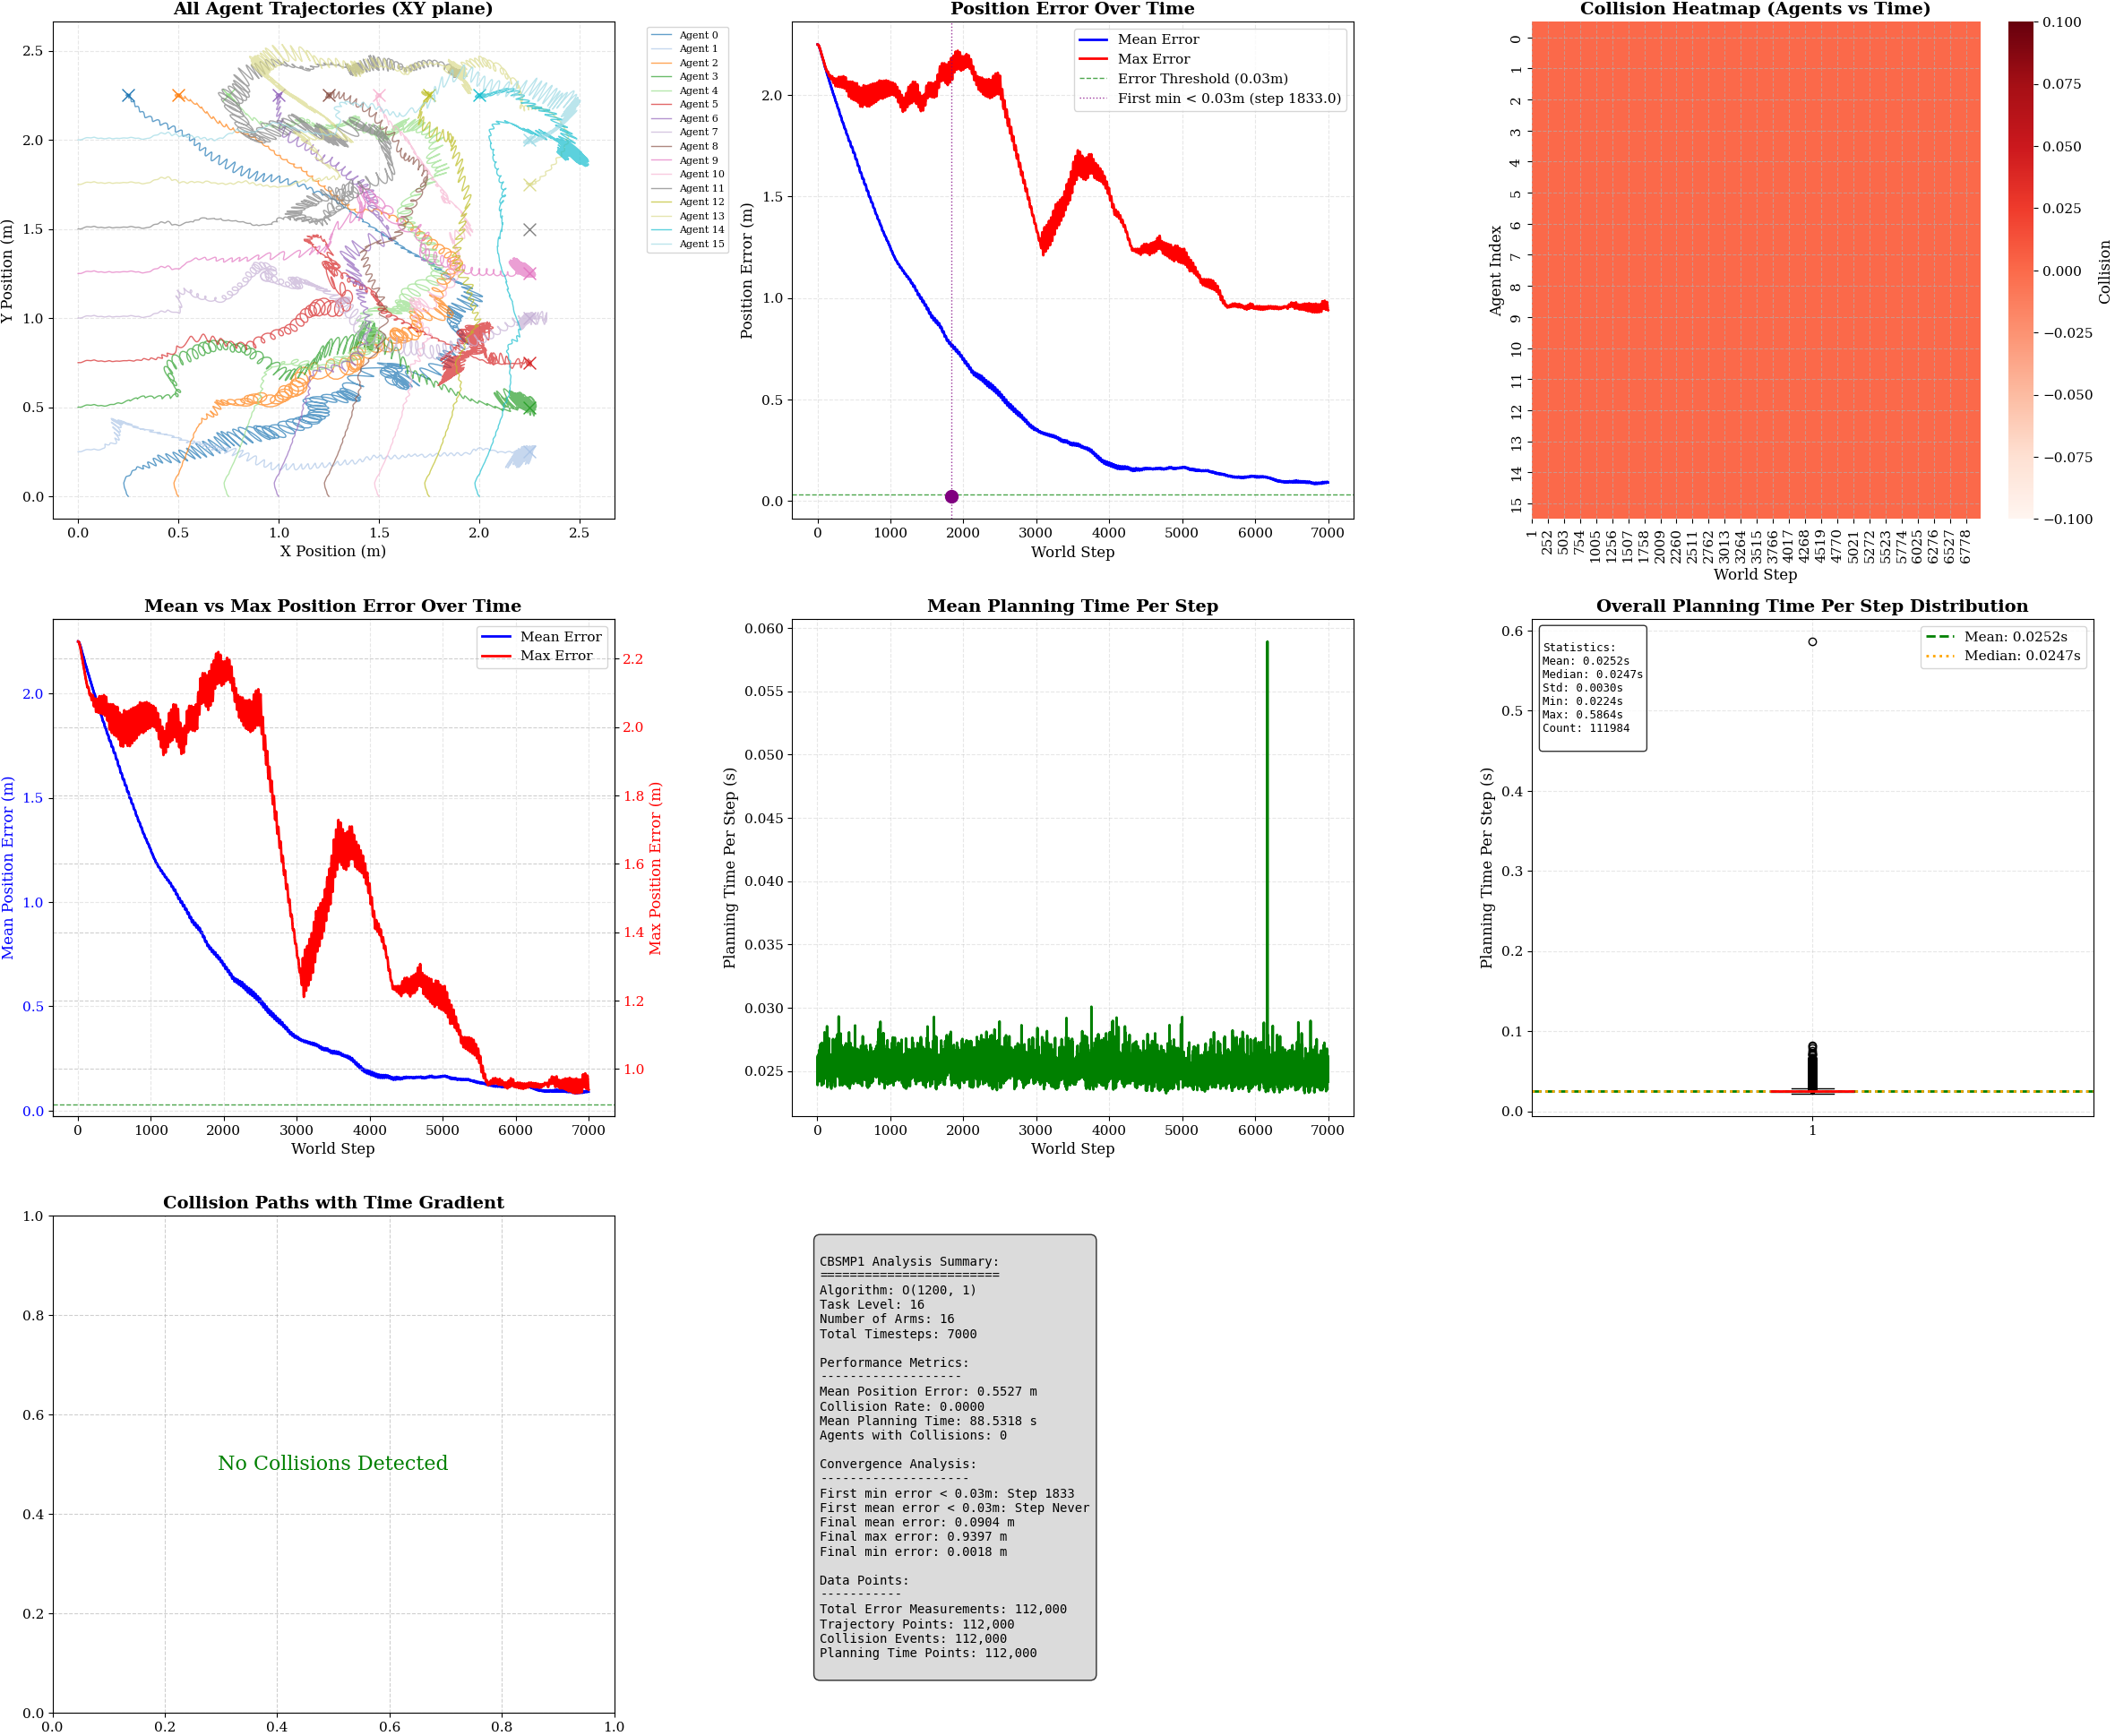


CBSMP1 COMPREHENSIVE ANALYSIS SUMMARY

Simulation: 2025-09-11_16:50:05
Algorithm: O(1200, 1)
Task Level: 16
Number of Arms: 16
Total Timesteps: 7000
Mean Position Error: 0.5527 m
Collision Rate: 0.0000
Mean Planning Time: 88.5318 s
Total Data Points: 112,000


In [57]:
df_cbsmp1, df_trajectory, df_collision, df_planning, overall_df = analyze_cbsmp1_improved_grid_with_collision_paths(disk_sims, df_collisions, successfull_parsing, valid_sim_dir_paths)

In [58]:
def run_pipeline_from_path_to_pdf(disk_analysis):

SyntaxError: incomplete input (3570534139.py, line 1)